# Juvenile Mortality Modeling Lab

This notebook is set up as a practical actuarial lab for **juvenile mortality modeling**.
The intent is not just to fit models, but to produce results that are stable enough to compare, explain, and carry into a report.

It is organized into four sessions:

1. **Data overview and scope**
2. **Feature screening**
3. **Mortality model fitting and comparison**
4. **Validation and sheet-style mortality output**

### Working style
This notebook still avoids heavy automation.
You can change filters, formulas, feature sets, or comment out blocks without breaking the lab structure.

In [1]:
from __future__ import annotations
from pygam import PoissonGAM, s, f
import warnings
from pathlib import Path
import math
import re

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import statsmodels.api as sm
import statsmodels.formula.api as smf
from IPython.display import display
from patsy.builtins import bs

warnings.filterwarnings("default")
warnings.filterwarnings("ignore", category=FutureWarning)

pd.set_option("display.max_columns", 200)
pd.set_option("display.max_rows", 200)
pd.set_option("display.float_format", lambda x: f"{x:,.6f}")
np.set_printoptions(suppress=True, linewidth=140)

try:
    import duckdb
    HAS_DUCKDB = True
except Exception:
    HAS_DUCKDB = False

try:
    import pyarrow  # noqa: F401
    HAS_PYARROW = True
except Exception:
    HAS_PYARROW = False

try:
    from sklearn.ensemble import (
        ExtraTreesRegressor,
        GradientBoostingRegressor,
        HistGradientBoostingRegressor,
        RandomForestRegressor,
    )
    from sklearn.inspection import permutation_importance
    from sklearn.linear_model import PoissonRegressor
    HAS_SKLEARN = True
except Exception:
    HAS_SKLEARN = False

print("duckdb available :", HAS_DUCKDB)
print("pyarrow available:", HAS_PYARROW)
print("sklearn available:", HAS_SKLEARN)


duckdb available : True
pyarrow available: True
sklearn available: True


---

# Session 1 · Data overview, scope, and first-pass actuarial review


In [2]:
# ============================================================
# SESSION 1 / SHARED CONTROL PANEL — EDIT HERE FIRST
# ============================================================

DATA_PATH = Path("script/data/parquet/full.parquet")

# ------------------------------
# Core scope filters
# ------------------------------
OBSERVATION_YEARS = None          # Example: [2018, 2019]; use None to keep all years
ISSUE_AGE_MIN = 0
ISSUE_AGE_MAX = 17
ATTAINED_AGE_MIN = 1
ATTAINED_AGE_MAX = 67
DURATION_MIN = 1
DURATION_CAP = 119

AGE_IND_KEEP = None               # Example: ["0"] or ["1"]; None keeps all age bases
SEX_KEEP = None                   # Example: ["M"] or ["F"]; None keeps all sexes
SMOKER_STATUS_KEEP = ["U"]        # Example: ["U"]; set to None to keep all
INSURANCE_PLAN_DROP = ["Other"]   # Set to [] if you want to keep "Other"

EXCLUDE_POST_LEVEL_TERM = True
POST_LEVEL_TERM_EXCLUDE_VALUES = ["PLT"]

# Optional duration cleanup for summary work only.
# Keep FALSE if you want sheet-style outputs similar to the reference tables.
COLLAPSE_DURATION_26_PLUS = False

# ------------------------------
# 1M face-amount cap option
# ------------------------------
CAP_FACE_AT_1M = True
FACE_CAP_VALUE = 1_000_000
FACE_CAP_SOURCE_BANDS = [
    "08: 1,000,000 - 2,499,999",
    "09: 2,500,000 - 4,999,999",
    "10: 5,000,000 - 9,999,999",
    "11: 10,000,000+",
]
FACE_CAP_TARGET_BAND = "08: 1,000,000+"

# ------------------------------
# Metric columns
# ------------------------------

# ------------------------------
# Age-basis harmonized helper columns used for testing / modeling
# Raw Issue_Age / Attained_Age are still retained for scope and display.
# ------------------------------
ISSUE_AGE_MOD_COL = "Issue_Age_mod"
ATTAINED_AGE_MOD_COL = "Attained_Age_mod"
ISSUE_AGE_MOD_MAX = ISSUE_AGE_MAX + 0.5
ATTAINED_AGE_MOD_MAX = ATTAINED_AGE_MAX + 0.5

# ------------------------------
# Optional maturity-normalized exposure scaling for later issue years.
# This only rescales exposed policies / amount for descriptive rate work.
# Deaths and expected deaths are not changed.
# ------------------------------
APPLY_ISSUE_YEAR_EXPOSURE_SCALING = True
ISSUE_YEAR_EXPOSURE_TARGET_YEARS = 7
ISSUE_YEAR_EXPOSURE_FULL_CREDIT_START = 2013
ISSUE_YEAR_EXPOSURE_SCALE_START = 2014
ISSUE_YEAR_EXPOSURE_SCALE_END = 2019

ACTUAL_CNT_COL = "Death_Count"
EXPECTED_CNT_COL = "ExpDth_VBT2015_Cnt"
ACTUAL_AMT_COL = "Death_Claim_Amount"
EXPECTED_AMT_COL = "ExpDth_VBT2015_Amt"

NUMERIC_COLS = [
    "Observation_Year", "Issue_Age", ISSUE_AGE_MOD_COL, "Duration", "Issue_Year", "Attained_Age", ATTAINED_AGE_MOD_COL,
    "Amount_Exposed", "Policies_Exposed", ACTUAL_AMT_COL, ACTUAL_CNT_COL,
    EXPECTED_CNT_COL, EXPECTED_AMT_COL
]

RAW_CATEGORICAL_COLS = [
    "Age_Ind", "Sex", "Smoker_Status", "Insurance_Plan", "Face_Amount_Band",
    "SOA_Antp_Lvl_TP", "SOA_Guar_Lvl_TP", "SOA_Post_Lvl_Ind", "Slct_Ult_Ind",
    "Preferred_Indicator", "Number_of_Pfd_Classes", "Preferred_Class"
]

DERIVED_CATEGORICAL_COLS = [
    "Insurance_Plan_Group",
    "Face_Band_Group",
    "Issue_Age_Band",
    "Attained_Age_Band",
    "Duration_Band",
]

CATEGORICAL_COLS = RAW_CATEGORICAL_COLS + DERIVED_CATEGORICAL_COLS
BASE_COLUMNS = [
    "Observation_Year",
    "Issue_Age",
    "Duration",
    "Issue_Year",
    "Attained_Age",
    "Amount_Exposed",
    "Policies_Exposed",
    ACTUAL_AMT_COL,
    ACTUAL_CNT_COL,
    EXPECTED_CNT_COL,
    EXPECTED_AMT_COL,
] + RAW_CATEGORICAL_COLS

# ------------------------------
# Development sampling controls
# Default is full data. These are only for faster exploratory work.
# ------------------------------
DEVELOPMENT_SAMPLE_FRACTION = None     # Example: 0.30 for a 30% stratified development sample
DEVELOPMENT_SAMPLE_STRATA = ["Observation_Year", "Age_Ind", "Sex", "Issue_Age_Band", "Duration_Band"]
DEVELOPMENT_SAMPLE_RANDOM_STATE = 42

# ------------------------------
# Grouping choices for challenger diagnostics
# ------------------------------
PLAN_GROUP_MAP = {
    "Perm": "Perm",
    "Term": "Term",
    "UL": "Perm",
    "ULSG": "Perm",
    "VL": "Perm",
    "VLSG": "Perm",
    "Other": "Other/Unknown",
    "Missing": "Missing",
}

FACE_BAND_GROUP_MAP = {
    "01: 0 - 9,999": "01-04: <100k",
    "02: 10,000 - 24,999": "01-04: <100k",
    "03: 25,000 - 49,999": "01-04: <100k",
    "04: 50,000 - 99,999": "01-04: <100k",
    "05: 100,000 - 249,999": "05-011: >100k",
    "06: 250,000 - 499,999": "05-011: >100k",
    "07: 500,000 - 999,999": "05-011: >100k",
    "08: 1,000,000 - 2,499,999": "05-011: >100k",
    "08: 1,000,000+": "05-011: >100k",
    "09: 2,500,000 - 4,999,999": "05-011: >100k",
    "10: 5,000,000 - 9,999,999": "05-011: >100k",
    "11: 10,000,000+": "05-011: >100k",
    "Missing": "Missing",
}

In [3]:
# ============================================================
# DATA DICTIONARY USED BY THIS NOTEBOOK
# ============================================================

DATA_DICTIONARY = pd.DataFrame({
    "Column": [
        "Observation_Year", "Age_Ind", "Sex", "Smoker_Status", "Insurance_Plan",
        "Issue_Age", "Issue_Age_mod", "Duration", "Issue_Year", "Attained_Age", "Attained_Age_mod",
        "Face_Amount_Band", "Amount_Exposed", "Policies_Exposed",
        ACTUAL_AMT_COL, ACTUAL_CNT_COL, EXPECTED_CNT_COL, EXPECTED_AMT_COL,
        "SOA_Antp_Lvl_TP", "SOA_Guar_Lvl_TP", "SOA_Post_Lvl_Ind", "Slct_Ult_Ind",
        "Preferred_Indicator", "Number_of_Pfd_Classes", "Preferred_Class",
        "Insurance_Plan_Group", "Face_Band_Group",
    ],
    "Meaning": [
        "Calendar year of observation",
        "Age basis indicator; kept explicit in this notebook (no basis conversion here)",
        "Sex",
        "Smoking status",
        "Insurance plan",
        "Issue age on raw company basis",
        "Issue age converted to a simple harmonized half-year basis (ALB = raw + 0.5; ANB = raw)",
        "Duration",
        "Issue year",
        "Attained age on raw company basis",
        "Attained age converted to a simple harmonized half-year basis (ALB = raw + 0.5; ANB = raw)",
        "Face amount band; optionally capped at 1M+ in this notebook",
        "Amount exposed",
        "Policies exposed",
        "Actual death claim amount",
        "Actual death count",
        "2015 VBT expected death count",
        "2015 VBT expected death amount",
        "SOA anticipated level term field",
        "SOA guaranteed level term field",
        "SOA post-level term indicator",
        "Select / ultimate indicator",
        "Preferred indicator",
        "Number of preferred classes",
        "Preferred class",
        "Derived grouped version of Insurance_Plan for challenger diagnostics",
        "Derived grouped version of Face_Amount_Band for challenger diagnostics",
    ],
})

display(DATA_DICTIONARY)


,Column,Meaning
0,Observation_Year,Calendar year of observation
1,Age_Ind,Age basis indicator; kept explicit in this not...
2,Sex,Sex
3,Smoker_Status,Smoking status
4,Insurance_Plan,Insurance plan
5,Issue_Age,Issue age on raw company basis
6,Issue_Age_mod,Issue age converted to a simple harmonized hal...
7,Duration,Duration
8,Issue_Year,Issue year
9,Attained_Age,Attained age on raw company basis


In [4]:
# ============================================================
# HELPER FUNCTIONS
# ============================================================

def require_parquet_support():
    if HAS_DUCKDB or HAS_PYARROW:
        return
    raise ImportError(
        "This notebook needs either duckdb or pyarrow to read parquet. "
        "Install one of them locally, for example: pip install duckdb or pip install pyarrow"
    )


def require_sklearn():
    if HAS_SKLEARN:
        return
    raise ImportError(
        "This notebook needs scikit-learn for Sessions 2 and 3. "
        "Install it locally, for example: pip install scikit-learn"
    )


def read_parquet_data(path: Path, columns: list[str] | None = None) -> pd.DataFrame:
    require_parquet_support()

    if not path.exists():
        raise FileNotFoundError(f"Parquet file not found: {path}")

    if HAS_DUCKDB:
        cols_sql = "*" if columns is None else ", ".join([f'"{c}"' for c in columns])
        query = f"SELECT {cols_sql} FROM read_parquet('{path.as_posix()}')"
        return duckdb.sql(query).df()

    return pd.read_parquet(path, columns=columns)


def export_csv(df: pd.DataFrame, filename: str):
    path = EXPORT_DIR / filename
    df.to_csv(path, index=False)
    print(f"Saved: {path}")


def force_plain_axis(ax, axis: str = "both"):
    formatter = mtick.ScalarFormatter(useOffset=False)
    formatter.set_scientific(False)

    if axis in ("x", "both"):
        ax.xaxis.set_major_formatter(formatter)
    if axis in ("y", "both"):
        ax.yaxis.set_major_formatter(formatter)


def safe_divide(numerator, denominator):
    numerator = np.asarray(numerator, dtype=float)
    denominator = np.asarray(denominator, dtype=float)
    out = np.divide(
        numerator,
        denominator,
        out=np.full_like(numerator, np.nan, dtype=float),
        where=np.abs(denominator) > 1e-12,
    )
    if np.ndim(out) == 0:
        return float(out)
    if out.size == 1:
        return float(np.ravel(out)[0])
    return out


def standardize_frame(df: pd.DataFrame) -> pd.DataFrame:
    out = df.copy()

    for col in NUMERIC_COLS:
        if col in out.columns:
            out[col] = pd.to_numeric(out[col], errors="coerce")

    for col in CATEGORICAL_COLS:
        if col in out.columns:
            out[col] = out[col].astype("string").fillna("Missing")

    return out



def derive_age_basis_columns(df: pd.DataFrame) -> pd.DataFrame:
    out = df.copy()
    age_ind = out["Age_Ind"].astype("string").fillna("Missing")

    out[ISSUE_AGE_MOD_COL] = pd.to_numeric(out["Issue_Age"], errors="coerce")
    out[ATTAINED_AGE_MOD_COL] = pd.to_numeric(out["Attained_Age"], errors="coerce")

    alb_mask = age_ind == "1"   # ALB
    anb_mask = age_ind == "0"   # ANB

    out.loc[alb_mask, ISSUE_AGE_MOD_COL] = out.loc[alb_mask, "Issue_Age"] + 0.5
    out.loc[alb_mask, ATTAINED_AGE_MOD_COL] = out.loc[alb_mask, "Attained_Age"] + 0.5

    out.loc[anb_mask, ISSUE_AGE_MOD_COL] = out.loc[anb_mask, "Issue_Age"]
    out.loc[anb_mask, ATTAINED_AGE_MOD_COL] = out.loc[anb_mask, "Attained_Age"]

    return out


def apply_issue_year_exposure_scaling(df: pd.DataFrame) -> pd.DataFrame:
    if not APPLY_ISSUE_YEAR_EXPOSURE_SCALING:
        return df.copy()

    out = df.copy()
    issue_year = pd.to_numeric(out["Issue_Year"], errors="coerce")
    eligible = issue_year.between(ISSUE_YEAR_EXPOSURE_SCALE_START, ISSUE_YEAR_EXPOSURE_SCALE_END, inclusive="both")

    observed_years = ISSUE_YEAR_EXPOSURE_SCALE_END - issue_year + 1
    scale = np.where(
        eligible,
        ISSUE_YEAR_EXPOSURE_TARGET_YEARS / np.clip(observed_years, 1, None),
        1.0,
    )

    out["Policies_Exposed"] = pd.to_numeric(out["Policies_Exposed"], errors="coerce") * scale
    out["Amount_Exposed"] = pd.to_numeric(out["Amount_Exposed"], errors="coerce") * scale
    return out


def apply_face_amount_cap_1m(df: pd.DataFrame) -> pd.DataFrame:
    if not CAP_FACE_AT_1M:
        return df.copy()

    out = df.copy()
    mask = out["Face_Amount_Band"].isin(FACE_CAP_SOURCE_BANDS)

    out.loc[mask, "Face_Amount_Band"] = FACE_CAP_TARGET_BAND
    out.loc[mask, ACTUAL_AMT_COL] = FACE_CAP_VALUE * out.loc[mask, ACTUAL_CNT_COL]
    out.loc[mask, "Amount_Exposed"] = FACE_CAP_VALUE * out.loc[mask, "Policies_Exposed"]
    out.loc[mask, EXPECTED_AMT_COL] = FACE_CAP_VALUE * out.loc[mask, EXPECTED_CNT_COL]

    return out


def add_grouped_features(df: pd.DataFrame) -> pd.DataFrame:
    out = df.copy()

    if "Insurance_Plan" in out.columns:
        out["Insurance_Plan_Group"] = (
            out["Insurance_Plan"]
            .astype("string")
            .fillna("Missing")
            .map(PLAN_GROUP_MAP)
            .fillna(out["Insurance_Plan"].astype("string").fillna("Missing"))
            .astype("string")
        )

    if "Face_Amount_Band" in out.columns:
        out["Face_Band_Group"] = (
            out["Face_Amount_Band"]
            .astype("string")
            .fillna("Missing")
            .map(FACE_BAND_GROUP_MAP)
            .fillna(out["Face_Amount_Band"].astype("string").fillna("Missing"))
            .astype("string")
        )

    return out


def add_validation_bands(df: pd.DataFrame) -> pd.DataFrame:
    out = df.copy()

    issue_age_series = out[ISSUE_AGE_MOD_COL] if ISSUE_AGE_MOD_COL in out.columns else out["Issue_Age"]
    attained_age_series = out[ATTAINED_AGE_MOD_COL] if ATTAINED_AGE_MOD_COL in out.columns else out["Attained_Age"]

    out["Issue_Age_Band"] = pd.cut(
        issue_age_series,
        bins=[-0.1, 0.5, 5.5, 10.5, 15.5, 17.5],
        labels=["0", "1-5", "6-10", "11-15", "16-17"],
        include_lowest=True,
        right=True,
    )

    attained_min = int(np.floor(attained_age_series.min())) if len(out) else 0
    attained_floor = max(0, (attained_min // 5) * 5)
    attained_bins = list(range(attained_floor, 101, 5))
    if attained_bins[-1] < 100:
        attained_bins.append(100)

    out["Attained_Age_Band"] = pd.cut(
        attained_age_series,
        bins=attained_bins,
        include_lowest=True,
        right=False,
    )

    out["Duration_Band"] = pd.cut(
        np.where(out["Duration"] >= 26, 26, out["Duration"]),
        bins=[-0.1, 1, 5, 10, 15, 20, 26],
        labels=["0-1", "2-5", "6-10", "11-15", "16-20", "21-26+"],
        include_lowest=True,
        right=True,
    )
    return out


def apply_scope_filters(df: pd.DataFrame) -> tuple[pd.DataFrame, pd.DataFrame]:
    out = standardize_frame(df)
    steps = [{"step": "raw_input", "rows": len(out)}]

    if OBSERVATION_YEARS is not None:
        out = out[out["Observation_Year"].isin(OBSERVATION_YEARS)].copy()
        steps.append({"step": f"Observation_Year in {OBSERVATION_YEARS}", "rows": len(out)})

    out = out[
        out["Issue_Age"].between(ISSUE_AGE_MIN, ISSUE_AGE_MAX, inclusive="both")
    ].copy()
    steps.append({"step": f"Issue_Age between {ISSUE_AGE_MIN} and {ISSUE_AGE_MAX}", "rows": len(out)})

    if ATTAINED_AGE_MIN is not None:
        out = out[out["Attained_Age"] >= ATTAINED_AGE_MIN].copy()
        steps.append({"step": f"Attained_Age >= {ATTAINED_AGE_MIN}", "rows": len(out)})

    if ATTAINED_AGE_MAX is not None:
        out = out[out["Attained_Age"] <= ATTAINED_AGE_MAX].copy()
        steps.append({"step": f"Attained_Age <= {ATTAINED_AGE_MAX}", "rows": len(out)})

    if AGE_IND_KEEP is not None:
        out = out[out["Age_Ind"].isin(AGE_IND_KEEP)].copy()
        steps.append({"step": f"Age_Ind in {AGE_IND_KEEP}", "rows": len(out)})

    if SEX_KEEP is not None:
        out = out[out["Sex"].isin(SEX_KEEP)].copy()
        steps.append({"step": f"Sex in {SEX_KEEP}", "rows": len(out)})

    if SMOKER_STATUS_KEEP is not None:
        out = out[out["Smoker_Status"].isin(SMOKER_STATUS_KEEP)].copy()
        steps.append({"step": f"Smoker_Status in {SMOKER_STATUS_KEEP}", "rows": len(out)})

    if INSURANCE_PLAN_DROP:
        out = out[~out["Insurance_Plan"].isin(INSURANCE_PLAN_DROP)].copy()
        steps.append({"step": f"Insurance_Plan not in {INSURANCE_PLAN_DROP}", "rows": len(out)})

    if EXCLUDE_POST_LEVEL_TERM:
        out = out[~out["SOA_Post_Lvl_Ind"].isin(POST_LEVEL_TERM_EXCLUDE_VALUES)].copy()
        steps.append({"step": f"SOA_Post_Lvl_Ind not in {POST_LEVEL_TERM_EXCLUDE_VALUES}", "rows": len(out)})

    if COLLAPSE_DURATION_26_PLUS:
        out["Duration"] = np.where(out["Duration"] >= 26, 26, out["Duration"])
        steps.append({"step": "Duration >= 26 collapsed to 26", "rows": len(out)})

    out = out[out[EXPECTED_CNT_COL] > 0].copy()
    steps.append({"step": f"{EXPECTED_CNT_COL} > 0", "rows": len(out)})

    out = apply_face_amount_cap_1m(out)
    if CAP_FACE_AT_1M:
        steps.append({"step": "Applied 1M face cap rule", "rows": len(out)})

    out = derive_age_basis_columns(out)
    steps.append({"step": "Added Issue_Age_mod / Attained_Age_mod (ALB = raw + 0.5; ANB = raw)", "rows": len(out)})

    out = apply_issue_year_exposure_scaling(out)
    if APPLY_ISSUE_YEAR_EXPOSURE_SCALING:
        steps.append({"step": "Scaled Policies_Exposed / Amount_Exposed for later issue years to a 7-year maturity basis", "rows": len(out)})

    out = add_grouped_features(out)
    out = add_validation_bands(out)
    steps.append({"step": "Added grouped plan / face-band fields and validation bands", "rows": len(out)})

    return out.reset_index(drop=True), pd.DataFrame(steps)


def apply_optional_development_sample(
    df: pd.DataFrame,
    fraction: float | None = None,
    strata: list[str] | None = None,
    random_state: int = 42,
) -> pd.DataFrame:
    if fraction is None:
        return df.copy()

    if not (0 < fraction <= 1):
        raise ValueError("DEVELOPMENT_SAMPLE_FRACTION must be in (0, 1].")

    if math.isclose(fraction, 1.0):
        return df.copy()

    work = df.copy()
    strata = [c for c in (strata or []) if c in work.columns]

    if not strata:
        return work.sample(frac=fraction, random_state=random_state).reset_index(drop=True)

    pieces = []
    for _, sub in work.groupby(strata, dropna=False, sort=False):
        n_take = max(1, int(round(len(sub) * fraction)))
        n_take = min(n_take, len(sub))
        pieces.append(sub.sample(n=n_take, random_state=random_state))

    sampled = pd.concat(pieces, ignore_index=True)
    return sampled.reset_index(drop=True)


def overall_metrics(df: pd.DataFrame) -> pd.DataFrame:
    actual_cnt = float(df[ACTUAL_CNT_COL].sum())
    expected_cnt = float(df[EXPECTED_CNT_COL].sum())
    actual_amt = float(df[ACTUAL_AMT_COL].sum())
    expected_amt = float(df[EXPECTED_AMT_COL].sum())
    policies = float(df["Policies_Exposed"].sum())
    amount_exposed = float(df["Amount_Exposed"].sum())

    return pd.DataFrame({
        "Metric": [
            "Rows",
            "Policies Exposed",
            "Amount Exposed",
            "Death Count",
            "Expected Death Count",
            "A/E Count",
            "Death Claim Amount",
            "Expected Death Amount",
            "A/E Amount",
            "Actual Rate per 1000",
            "Expected Rate per 1000",
        ],
        "Value": [
            len(df),
            policies,
            amount_exposed,
            actual_cnt,
            expected_cnt,
            safe_divide(actual_cnt, expected_cnt),
            actual_amt,
            expected_amt,
            safe_divide(actual_amt, expected_amt),
            safe_divide(actual_cnt * 1000.0, policies),
            safe_divide(expected_cnt * 1000.0, policies),
        ]
    })


def ae_summary(df: pd.DataFrame, group_cols: str | list[str]) -> pd.DataFrame:
    if isinstance(group_cols, str):
        group_cols = [group_cols]

    out = (
        df.groupby(group_cols, dropna=False)[
            [ACTUAL_CNT_COL, EXPECTED_CNT_COL, ACTUAL_AMT_COL, EXPECTED_AMT_COL, "Policies_Exposed", "Amount_Exposed"]
        ]
        .sum()
        .reset_index()
        .sort_values(group_cols)
        .reset_index(drop=True)
    )
    out["A/E_Count"] = safe_divide(out[ACTUAL_CNT_COL], out[EXPECTED_CNT_COL])
    out["A/E_Amount"] = safe_divide(out[ACTUAL_AMT_COL], out[EXPECTED_AMT_COL])
    out["Actual_Rate_per_1000"] = safe_divide(out[ACTUAL_CNT_COL] * 1000.0, out["Policies_Exposed"])
    out["Expected_Rate_per_1000"] = safe_divide(out[EXPECTED_CNT_COL] * 1000.0, out["Policies_Exposed"])
    return out


def safe_poisson_deviance(y_true, y_pred) -> float:
    y = np.asarray(y_true, dtype=float)
    mu = np.clip(np.asarray(y_pred, dtype=float), 1e-12, None)
    term = np.where(y == 0, 0.0, y * np.log(np.clip(y, 1e-12, None) / mu))
    return float(2.0 * np.sum(term - (y - mu)))


def weighted_ae_error(actual, predicted, expected) -> float:
    actual = np.asarray(actual, dtype=float)
    predicted = np.asarray(predicted, dtype=float)
    expected = np.asarray(expected, dtype=float)

    actual_ae = actual / np.clip(expected, 1e-12, None)
    pred_ae = predicted / np.clip(expected, 1e-12, None)
    return float(np.average(np.abs(actual_ae - pred_ae), weights=np.clip(expected, 1e-12, None)))


def weighted_mean(x, w):
    x = np.asarray(x, dtype=float)
    w = np.asarray(w, dtype=float)
    keep = np.isfinite(x) & np.isfinite(w) & (w > 0)
    if keep.sum() == 0:
        return np.nan
    return float(np.sum(x[keep] * w[keep]) / np.sum(w[keep]))


def weighted_corr(x, y, w):
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)
    w = np.asarray(w, dtype=float)

    keep = np.isfinite(x) & np.isfinite(y) & np.isfinite(w) & (w > 0)
    if keep.sum() <= 1:
        return np.nan

    x = x[keep]
    y = y[keep]
    w = w[keep]

    mx = np.sum(w * x) / np.sum(w)
    my = np.sum(w * y) / np.sum(w)

    cov_xy = np.sum(w * (x - mx) * (y - my)) / np.sum(w)
    var_x = np.sum(w * (x - mx) ** 2) / np.sum(w)
    var_y = np.sum(w * (y - my) ** 2) / np.sum(w)

    if (var_x <= 0) or (var_y <= 0):
        return np.nan

    return float(cov_xy / np.sqrt(var_x * var_y))


def weighted_spearman(df: pd.DataFrame, x_col: str, y_col: str, weight_col: str = "Policies_Exposed") -> float:
    if x_col == y_col:
        return 1.0

    sub = df[[x_col, y_col, weight_col]].copy()
    sub[x_col] = pd.to_numeric(sub[x_col], errors="coerce")
    sub[y_col] = pd.to_numeric(sub[y_col], errors="coerce")
    sub[weight_col] = pd.to_numeric(sub[weight_col], errors="coerce")

    sub = sub.replace([np.inf, -np.inf], np.nan).dropna()
    if len(sub) <= 1:
        return np.nan

    x_rank = sub[x_col].rank(method="average")
    y_rank = sub[y_col].rank(method="average")
    return weighted_corr(x_rank, y_rank, sub[weight_col])


def weighted_corr_matrix(df: pd.DataFrame, columns: list[str], weight_col: str = "Policies_Exposed") -> pd.DataFrame:
    cols = [c for c in columns if c in df.columns]
    out = pd.DataFrame(index=cols, columns=cols, dtype=float)

    for c1 in cols:
        for c2 in cols:
            if c1 == c2:
                out.loc[c1, c2] = 1.0
            else:
                out.loc[c1, c2] = weighted_spearman(df, c1, c2, weight_col=weight_col)

    return out


def weighted_crosstab(df: pd.DataFrame, row_col: str, col_col: str, weight_col: str = "Policies_Exposed") -> pd.DataFrame:
    sub = df[[row_col, col_col, weight_col]].copy()
    sub[row_col] = sub[row_col].astype("string").fillna("Missing")
    sub[col_col] = sub[col_col].astype("string").fillna("Missing")
    sub[weight_col] = pd.to_numeric(sub[weight_col], errors="coerce").fillna(0.0)

    out = pd.pivot_table(
        sub,
        index=row_col,
        columns=col_col,
        values=weight_col,
        aggfunc="sum",
        fill_value=0.0,
        dropna=False,
    )
    return out


def cramers_v_from_weighted_table(table: pd.DataFrame) -> float:
    observed = np.asarray(table, dtype=float)
    n = observed.sum()

    if n <= 0 or observed.shape[0] < 2 or observed.shape[1] < 2:
        return np.nan

    row_totals = observed.sum(axis=1, keepdims=True)
    col_totals = observed.sum(axis=0, keepdims=True)
    expected = row_totals @ col_totals / n

    keep = expected > 0
    chi2 = np.sum(((observed - expected) ** 2 / expected)[keep])
    phi2 = chi2 / n

    r, k = observed.shape
    if n <= 1:
        return np.nan

    phi2_corr = max(0.0, phi2 - ((k - 1) * (r - 1)) / (n - 1))
    r_corr = r - ((r - 1) ** 2) / (n - 1)
    k_corr = k - ((k - 1) ** 2) / (n - 1)

    denom = min(k_corr - 1, r_corr - 1)
    if denom <= 0:
        return np.nan

    return float(np.sqrt(phi2_corr / denom))


def cramers_v_matrix(df: pd.DataFrame, columns: list[str], weight_col: str = "Policies_Exposed") -> pd.DataFrame:
    cols = [c for c in columns if c in df.columns]
    out = pd.DataFrame(index=cols, columns=cols, dtype=float)

    for c1 in cols:
        for c2 in cols:
            if c1 == c2:
                out.loc[c1, c2] = 1.0
            else:
                table = weighted_crosstab(df, c1, c2, weight_col=weight_col)
                out.loc[c1, c2] = cramers_v_from_weighted_table(table)

    return out


def two_way_ae_tables(df: pd.DataFrame, row_col: str, col_col: str) -> tuple[pd.DataFrame, pd.DataFrame]:
    base = (
        df.groupby([row_col, col_col], dropna=False)[[ACTUAL_CNT_COL, EXPECTED_CNT_COL]]
        .sum()
        .reset_index()
    )
    base["Actual_to_VBT"] = safe_divide(base[ACTUAL_CNT_COL], base[EXPECTED_CNT_COL])

    ae_pivot = base.pivot(index=row_col, columns=col_col, values="Actual_to_VBT")
    exp_pivot = base.pivot(index=row_col, columns=col_col, values=EXPECTED_CNT_COL)

    return ae_pivot, exp_pivot


def prepare_model_frame(df: pd.DataFrame, required_cols: list[str]) -> pd.DataFrame:
    required_cols = list(dict.fromkeys(required_cols))
    out = df.copy()

    if ISSUE_AGE_MOD_COL not in out.columns or ATTAINED_AGE_MOD_COL not in out.columns:
        out = derive_age_basis_columns(out)

    out = add_spline_safe_columns(out)

    required_cols = [c for c in required_cols if c in out.columns]
    out = out[required_cols].copy()

    for col in required_cols:
        if col in CATEGORICAL_COLS or col in DERIVED_CATEGORICAL_COLS:
            out[col] = out[col].astype("string").fillna("Missing")
        else:
            out[col] = pd.to_numeric(out[col], errors="coerce")

    out = out.replace([np.inf, -np.inf], np.nan)
    keep_cols = [c for c in required_cols if c not in [ACTUAL_AMT_COL, EXPECTED_AMT_COL]]
    out = out.dropna(subset=keep_cols).copy()
    out = out[out[EXPECTED_CNT_COL] > 0].copy()

    return out.reset_index(drop=True)


def aggregate_cells(df: pd.DataFrame, features: list[str]) -> pd.DataFrame:
    metric_cols = [
        ACTUAL_CNT_COL, EXPECTED_CNT_COL, ACTUAL_AMT_COL, EXPECTED_AMT_COL,
        "Policies_Exposed", "Amount_Exposed"
    ]
    metric_cols = [c for c in metric_cols if c in df.columns]

    if not features:
        agg = df[metric_cols].sum().to_frame().T
        return agg.reset_index(drop=True)

    agg = (
        df.groupby(features, dropna=False)[metric_cols]
        .sum()
        .reset_index()
        .sort_values(features)
        .reset_index(drop=True)
    )
    return agg


def split_feature_types(features: list[str]) -> tuple[list[str], list[str]]:
    numeric_feature_cols = set(NUMERIC_COLS) | {
        ISSUE_AGE_MOD_COL,
        ATTAINED_AGE_MOD_COL,
        "Issue_Age_mod_spline",
        "Attained_Age_mod_spline",
        "Duration_spline",
    }

    cat_cols = [c for c in features if c in CATEGORICAL_COLS or c in DERIVED_CATEGORICAL_COLS]
    num_cols = [c for c in features if c in numeric_feature_cols]
    return cat_cols, num_cols


def build_category_levels(df: pd.DataFrame, features: list[str]) -> dict[str, list[str]]:
    cat_cols, _ = split_feature_types(features)
    out = {}
    for col in cat_cols:
        vals = df[col].astype("string").fillna("Missing")
        out[col] = vals.drop_duplicates().tolist()
    return out


def encode_features(
    df: pd.DataFrame,
    features: list[str],
    category_levels: dict[str, list[str]] | None = None,
    design_columns: list[str] | None = None,
) -> pd.DataFrame:
    work = df[features].copy()
    cat_cols, num_cols = split_feature_types(features)

    for col in cat_cols:
        work[col] = work[col].astype("string").fillna("Missing")
        if category_levels is not None and col in category_levels:
            work[col] = pd.Categorical(work[col], categories=category_levels[col])

    enc = pd.get_dummies(work, columns=cat_cols, drop_first=False, dtype=float)

    for col in num_cols:
        enc[col] = pd.to_numeric(enc[col], errors="coerce")

    enc = enc.replace([np.inf, -np.inf], np.nan).fillna(0.0)

    if design_columns is not None:
        for col in design_columns:
            if col not in enc.columns:
                enc[col] = 0.0
        enc = enc[design_columns].copy()

    return enc.astype(float)


def evaluate_predictions(actual, expected, predicted, label: str) -> dict:
    actual = np.asarray(actual, dtype=float)
    expected = np.asarray(expected, dtype=float)
    predicted = np.clip(np.asarray(predicted, dtype=float), 1e-12, None)

    return {
        "Dataset": label,
        "Rows": len(actual),
        "Actual_Deaths": float(actual.sum()),
        "Expected_VBT": float(expected.sum()),
        "Predicted_Deaths": float(predicted.sum()),
        "Actual_to_Predicted": safe_divide(actual.sum(), predicted.sum()),
        "Actual_to_VBT": safe_divide(actual.sum(), expected.sum()),
        "Poisson_Deviance": safe_poisson_deviance(actual, predicted),
        "Weighted_AE_Error": weighted_ae_error(actual, predicted, expected),
    }


def screen_formula_for_feature(feature: str) -> str:
    if feature == ISSUE_AGE_MOD_COL:
        return (
            f"{ACTUAL_CNT_COL} ~ bs({ISSUE_AGE_MOD_COL}, knots={tuple(GAM_ISSUE_AGE_KNOTS)}, degree=3, "
            f"include_intercept=False, lower_bound={ISSUE_AGE_MIN}, upper_bound={ISSUE_AGE_MOD_MAX})"
        )
    if feature == "Duration":
        return (
            f"{ACTUAL_CNT_COL} ~ bs(Duration, knots={tuple(GAM_DURATION_KNOTS)}, degree=3, "
            f"include_intercept=False, lower_bound=0, upper_bound={GAM_DURATION_UPPER_BOUND})"
        )
    if feature == ATTAINED_AGE_MOD_COL:
        return (
            f"{ACTUAL_CNT_COL} ~ bs({ATTAINED_AGE_MOD_COL}, knots={tuple(GAM_ATTAINED_AGE_KNOTS)}, degree=3, "
            f"include_intercept=False, lower_bound={ATTAINED_AGE_MIN}, upper_bound={ATTAINED_AGE_MOD_MAX})"
        )
    if feature in NUMERIC_SCREEN_FEATURES:
        return f"{ACTUAL_CNT_COL} ~ bs({feature}, df={SCREEN_SPLINE_DF}, degree=3, include_intercept=False)"
    return f"{ACTUAL_CNT_COL} ~ C({feature})"


def run_univariate_screen(df: pd.DataFrame, features: list[str]) -> pd.DataFrame:
    rows = []

    for feature in features:
        needed = [feature, ACTUAL_CNT_COL, EXPECTED_CNT_COL]
        sub = prepare_model_frame(df, needed)

        try:
            sub = aggregate_cells(sub, [feature])

            base_model = smf.glm(
                formula=f"{ACTUAL_CNT_COL} ~ 1",
                data=sub,
                family=sm.families.Poisson(),
                offset=np.log(sub["Policies_Exposed"]),
            ).fit()

            model = smf.glm(
                formula=screen_formula_for_feature(feature),
                data=sub,
                family=sm.families.Poisson(),
                offset=np.log(sub["Policies_Exposed"]),
            ).fit()

            pred = model.predict(sub, offset=np.log(sub["Policies_Exposed"]))
            rows.append({
                "Feature": feature,
                "Levels_or_Unique": int(sub[feature].nunique(dropna=False)),
                "Base_Deviance": float(base_model.deviance),
                "Model_Deviance": float(model.deviance),
                "Deviance_Reduction": float(base_model.deviance - model.deviance),
                "Deviance_Reduction_%": 100 * (base_model.deviance - model.deviance) / base_model.deviance if base_model.deviance > 0 else np.nan,
                "AIC": float(model.aic),
                "Weighted_AE_Error": weighted_ae_error(sub[ACTUAL_CNT_COL], pred, sub[EXPECTED_CNT_COL]),
            })
        except Exception as exc:
            rows.append({
                "Feature": feature,
                "Levels_or_Unique": np.nan,
                "Base_Deviance": np.nan,
                "Model_Deviance": np.nan,
                "Deviance_Reduction": np.nan,
                "Deviance_Reduction_%": np.nan,
                "AIC": np.nan,
                "Weighted_AE_Error": np.nan,
                "Note": str(exc)[:200],
            })

    out = pd.DataFrame(rows)
    return out.sort_values(["Deviance_Reduction_%", "Deviance_Reduction"], ascending=False, na_position="last").reset_index(drop=True)


def run_tree_feature_importance(
    df: pd.DataFrame,
    features: list[str],
    estimator,
    smooth: float = 0.25,
    random_state: int = 42,
) -> pd.DataFrame:
    require_sklearn()

    needed = features + [ACTUAL_CNT_COL, EXPECTED_CNT_COL]
    base = prepare_model_frame(df, needed)
    cell_df = aggregate_cells(base, features).copy()

    category_levels = build_category_levels(cell_df, features)
    X = encode_features(cell_df, features, category_levels=category_levels)
    y_log_ratio = np.log((cell_df[ACTUAL_CNT_COL] + smooth) / (cell_df["Policies_Exposed"] + smooth))
    w = np.clip(cell_df["Policies_Exposed"].to_numpy(dtype=float), 1e-12, None)

    estimator.fit(X, y_log_ratio, sample_weight=w)

    if hasattr(estimator, "feature_importances_"):
        raw_imp = pd.Series(estimator.feature_importances_, index=X.columns)
    else:
        perm = permutation_importance(
            estimator, X, y_log_ratio, n_repeats=10, random_state=random_state,
            scoring="neg_mean_absolute_error"
        )
        raw_imp = pd.Series(perm.importances_mean, index=X.columns)

    rows = []
    for feature in features:
        mask = raw_imp.index == feature
        mask = mask | raw_imp.index.str.startswith(f"{feature}_")
        rows.append({
            "Feature": feature,
            "Importance": float(raw_imp[mask].sum()),
        })

    out = pd.DataFrame(rows).sort_values("Importance", ascending=False).reset_index(drop=True)
    out["Rank"] = np.arange(1, len(out) + 1)
    return out


def combine_screen_ranks(
    univariate_df: pd.DataFrame | None = None,
    gbm_df: pd.DataFrame | None = None,
    extra_df: pd.DataFrame | None = None,
) -> pd.DataFrame:
    pieces = []

    if univariate_df is not None:
        uni = univariate_df[["Feature", "Deviance_Reduction_%"]].copy()
        uni["Univariate_Rank"] = uni["Deviance_Reduction_%"].rank(ascending=False, method="dense")
        pieces.append(uni)

    if gbm_df is not None:
        gbm = gbm_df[["Feature", "Importance"]].rename(columns={"Importance": "GBM_Importance"})
        gbm["GBM_Rank"] = gbm["GBM_Importance"].rank(ascending=False, method="dense")
        pieces.append(gbm)

    if extra_df is not None:
        extra = extra_df[["Feature", "Importance"]].rename(columns={"Importance": "ExtraTrees_Importance"})
        extra["ExtraTrees_Rank"] = extra["ExtraTrees_Importance"].rank(ascending=False, method="dense")
        pieces.append(extra)

    if not pieces:
        raise ValueError("No screening result tables were provided.")

    out = pieces[0].copy()
    for piece in pieces[1:]:
        out = out.merge(piece, on="Feature", how="outer")

    rank_cols = [c for c in out.columns if c.endswith("_Rank")]
    sort_anchor = "Deviance_Reduction_%" if "Deviance_Reduction_%" in out.columns else rank_cols[0]
    out["Average_Rank"] = out[rank_cols].mean(axis=1)
    out = out.sort_values(["Average_Rank", sort_anchor], ascending=[True, False], na_position="last").reset_index(drop=True)
    return out

def add_spline_safe_columns(df: pd.DataFrame) -> pd.DataFrame:
    out = df.copy()

    age_lo = np.nextafter(float(ISSUE_AGE_MIN), np.inf)
    age_hi = np.nextafter(float(ISSUE_AGE_MOD_MAX), -np.inf)
    att_lo = np.nextafter(float(ATTAINED_AGE_MIN), np.inf)
    att_hi = np.nextafter(float(ATTAINED_AGE_MOD_MAX), -np.inf)
    dur_lo = np.nextafter(0.0, np.inf)
    dur_hi = np.nextafter(float(GAM_DURATION_UPPER_BOUND), -np.inf)

    out["Issue_Age_mod_spline"] = pd.to_numeric(
        out[ISSUE_AGE_MOD_COL], errors="coerce"
    ).clip(lower=age_lo, upper=age_hi)

    out["Attained_Age_mod_spline"] = pd.to_numeric(
        out[ATTAINED_AGE_MOD_COL], errors="coerce"
    ).clip(lower=att_lo, upper=att_hi)

    out["Duration_spline"] = pd.to_numeric(
        out["Duration"], errors="coerce"
    ).clip(lower=dur_lo, upper=dur_hi)

    # Add piecewise attained-age hinge columns when ENFORCE_CONTINUITY is False.
    out = add_piecewise_attained_age_cols_if_needed(out)

    return out

def extract_formula_features(formula: str) -> list[str]:
    tokens = set(re.findall(r"\b[A-Za-z_][A-Za-z0-9_]*\b", formula))

    metric_exclusions = {
        ACTUAL_CNT_COL,
        EXPECTED_CNT_COL,
        ACTUAL_AMT_COL,
        EXPECTED_AMT_COL,
        "Policies_Exposed",
        "Amount_Exposed",
    }

    derived_numeric_cols = [
        ISSUE_AGE_MOD_COL,
        ATTAINED_AGE_MOD_COL,
        "Issue_Age_mod_spline",
        "Attained_Age_mod_spline",
        "Duration_spline",
        "Duration",
    ]

    candidate_cols = list(dict.fromkeys(
        BASE_COLUMNS
        + NUMERIC_COLS
        + CATEGORICAL_COLS
        + DERIVED_CATEGORICAL_COLS
        + derived_numeric_cols
    ))

    return [c for c in candidate_cols if c in tokens and c not in metric_exclusions]


def score_with_bundle(bundle: dict, score_df: pd.DataFrame) -> pd.DataFrame:
    validation_keep_cols = [
        "Observation_Year", "Age_Ind", "Sex", "Insurance_Plan", "Insurance_Plan_Group",
        "Face_Amount_Band", "Face_Band_Group",
        "Issue_Age", ISSUE_AGE_MOD_COL, "Attained_Age", ATTAINED_AGE_MOD_COL, "Duration", "Slct_Ult_Ind",
        "Issue_Age_Band", "Attained_Age_Band", "Duration_Band",
        "Policies_Exposed", "Amount_Exposed", ACTUAL_CNT_COL, EXPECTED_CNT_COL,
        ACTUAL_AMT_COL, EXPECTED_AMT_COL
    ]
    validation_keep_cols = [c for c in validation_keep_cols if c in score_df.columns]

    features = bundle["features"]
    needed = list(dict.fromkeys(features + validation_keep_cols))
    score_base = prepare_model_frame(score_df, needed)

    if bundle["model_type"] == "statsmodels_glm":
        pred = bundle["result"].predict(score_base, offset=np.log(score_base["Policies_Exposed"]))
    else:
        X_score = encode_features(
            score_base,
            features,
            category_levels=bundle["category_levels"],
            design_columns=bundle["design_columns"],
        )

        if bundle["model_type"] == "poisson_regressor":
            pred_rate = np.clip(bundle["result"].predict(X_score), 1e-12, None)
            pred = pred_rate * score_base["Policies_Exposed"].to_numpy(dtype=float)
        elif bundle["model_type"] == "log_ratio_model":
            pred_log = bundle["result"].predict(X_score)
            pred = np.exp(pred_log) * score_base["Policies_Exposed"].to_numpy(dtype=float)
        else:
            raise ValueError(f"Unsupported model_type: {bundle['model_type']}")

    out = score_base.copy()
    out["Predicted_Deaths"] = np.clip(np.asarray(pred, dtype=float), 1e-12, None)
    out["Predicted_to_VBT"] = safe_divide(out["Predicted_Deaths"], out[EXPECTED_CNT_COL])
    out["Actual_to_Predicted"] = safe_divide(out[ACTUAL_CNT_COL], out["Predicted_Deaths"])
    out["Actual_to_VBT"] = safe_divide(out[ACTUAL_CNT_COL], out[EXPECTED_CNT_COL])
    out["Actual_Rate_per_1000"] = safe_divide(out[ACTUAL_CNT_COL] * 1000.0, out["Policies_Exposed"])
    out["Expected_Rate_per_1000"] = safe_divide(out[EXPECTED_CNT_COL] * 1000.0, out["Policies_Exposed"])
    out["Predicted_Rate_per_1000"] = safe_divide(out["Predicted_Deaths"] * 1000.0, out["Policies_Exposed"])
    return out


def infer_glm_bic(result) -> float:
    nobs = getattr(result, "nobs", np.nan)
    k = len(getattr(result, "params", []))
    llf = getattr(result, "llf", np.nan)

    if not np.isfinite(nobs) or not np.isfinite(llf) or nobs <= 0:
        return np.nan

    return float(-2.0 * llf + k * np.log(nobs))


def make_intercept_baseline(train_cells: pd.DataFrame) -> tuple[float, float]:
    baseline_ratio = safe_divide(train_cells[ACTUAL_CNT_COL].sum(), train_cells["Policies_Exposed"].sum())
    baseline_pred = baseline_ratio * train_cells["Policies_Exposed"].to_numpy(dtype=float)
    baseline_dev = safe_poisson_deviance(train_cells[ACTUAL_CNT_COL], baseline_pred)
    return float(baseline_ratio), float(baseline_dev)


def bundle_comparison_row(bundle: dict) -> dict:
    metrics = bundle["metrics"].set_index("Dataset")

    row = {
        "Model_Key": bundle["model_key"],
        "Model_Type": bundle["model_type"],
        "Feature_Count": len(bundle["features"]),
        "Parameter_Count": bundle.get("parameter_count", np.nan),
        "Likelihood_Criteria_Comparable": bundle.get("likelihood_comparable", "No"),
        "Train_Deviance": float(metrics.loc["Train", "Poisson_Deviance"]),
        "Scored_Deviance": float(metrics.loc["Scored_Data", "Poisson_Deviance"]),
        "Train_A/P": float(metrics.loc["Train", "Actual_to_Predicted"]),
        "Scored_A/P": float(metrics.loc["Scored_Data", "Actual_to_Predicted"]),
        "Train_Weighted_AE_Error": float(metrics.loc["Train", "Weighted_AE_Error"]),
        "Scored_Weighted_AE_Error": float(metrics.loc["Scored_Data", "Weighted_AE_Error"]),
        "Train_Deviance_Explained_vs_Intercept": safe_divide(
            bundle.get("baseline_deviance", np.nan) - float(metrics.loc["Train", "Poisson_Deviance"]),
            bundle.get("baseline_deviance", np.nan),
        ),
        "AIC": bundle.get("aic", np.nan),
        "BIC": bundle.get("bic", np.nan),
        "Train_Null_Deviance": bundle.get("null_deviance", np.nan),
        "Train_Deviance_Gap_Scored_minus_Train": float(metrics.loc["Scored_Data", "Poisson_Deviance"]) - float(metrics.loc["Train", "Poisson_Deviance"]),
    }
    return row


def fit_formula_glm_bundle(model_key: str, formula: str, train_df: pd.DataFrame, score_df: pd.DataFrame) -> dict:
    features = extract_formula_features(formula)
    required_cols = features + [
        ACTUAL_CNT_COL, EXPECTED_CNT_COL, ACTUAL_AMT_COL, EXPECTED_AMT_COL, "Policies_Exposed", "Amount_Exposed"
    ]

    train_model_df = prepare_model_frame(train_df, required_cols)
    score_model_df = prepare_model_frame(score_df, required_cols)

    train_cells = aggregate_cells(train_model_df, features)
    baseline_ratio, baseline_dev = make_intercept_baseline(train_cells)

    result = smf.glm(
        formula=formula,
        data=train_cells,
        family=sm.families.Poisson(),
        offset=np.log(train_cells["Policies_Exposed"]),
    ).fit()

    bundle = {
        "model_key": model_key,
        "model_type": "statsmodels_glm",
        "label": model_key,
        "formula": formula,
        "features": features,
        "result": result,
        "baseline_ratio": baseline_ratio,
        "baseline_deviance": baseline_dev,
        "parameter_count": int(len(result.params)),
        "likelihood_comparable": "Yes",
        "aic": float(result.aic),
        "bic": infer_glm_bic(result),
        "null_deviance": float(getattr(result, "null_deviance", np.nan)),
    }

    scored_train = score_with_bundle(bundle, train_df)
    scored_score = score_with_bundle(bundle, score_df)

    metrics = pd.DataFrame([
        evaluate_predictions(scored_train[ACTUAL_CNT_COL], scored_train[EXPECTED_CNT_COL], scored_train["Predicted_Deaths"], "Train"),
        evaluate_predictions(scored_score[ACTUAL_CNT_COL], scored_score[EXPECTED_CNT_COL], scored_score["Predicted_Deaths"], "Scored_Data"),
    ])

    bundle["metrics"] = metrics
    bundle["train_cells"] = train_cells
    return bundle


def fit_poisson_regressor_bundle(
    model_key: str,
    train_df: pd.DataFrame,
    score_df: pd.DataFrame,
    features: list[str],
    alpha: float = 0.001,
) -> dict:
    require_sklearn()

    needed = features + [ACTUAL_CNT_COL, EXPECTED_CNT_COL, ACTUAL_AMT_COL, EXPECTED_AMT_COL, "Policies_Exposed", "Amount_Exposed"]
    train_model_df = prepare_model_frame(train_df, needed)
    score_model_df = prepare_model_frame(score_df, needed)

    train_cells = aggregate_cells(train_model_df, features)
    baseline_ratio, baseline_dev = make_intercept_baseline(train_cells)

    category_levels = build_category_levels(train_cells, features)
    X_train = encode_features(train_cells, features, category_levels=category_levels)

    rate_train = safe_divide(train_cells[ACTUAL_CNT_COL], train_cells["Policies_Exposed"])
    w_train = np.clip(train_cells["Policies_Exposed"].to_numpy(dtype=float), 1e-12, None)

    est = PoissonRegressor(alpha=alpha, max_iter=1000)
    est.fit(X_train, rate_train, sample_weight=w_train)

    bundle = {
        "model_key": model_key,
        "model_type": "poisson_regressor",
        "label": model_key,
        "features": features,
        "result": est,
        "category_levels": category_levels,
        "design_columns": X_train.columns.tolist(),
        "baseline_ratio": baseline_ratio,
        "baseline_deviance": baseline_dev,
        "parameter_count": int(X_train.shape[1] + 1),
        "likelihood_comparable": "No",
    }

    scored_train = score_with_bundle(bundle, train_model_df)
    scored_score = score_with_bundle(bundle, score_model_df)

    metrics = pd.DataFrame([
        evaluate_predictions(scored_train[ACTUAL_CNT_COL], scored_train[EXPECTED_CNT_COL], scored_train["Predicted_Deaths"], "Train"),
        evaluate_predictions(scored_score[ACTUAL_CNT_COL], scored_score[EXPECTED_CNT_COL], scored_score["Predicted_Deaths"], "Scored_Data"),
    ])

    bundle["metrics"] = metrics
    bundle["train_cells"] = train_cells
    return bundle


def fit_log_ratio_bundle(
    model_key: str,
    estimator,
    train_df: pd.DataFrame,
    score_df: pd.DataFrame,
    features: list[str],
    smooth: float = 0.25,
) -> dict:
    require_sklearn()

    needed = features + [ACTUAL_CNT_COL, EXPECTED_CNT_COL, ACTUAL_AMT_COL, EXPECTED_AMT_COL, "Policies_Exposed", "Amount_Exposed"]
    train_model_df = prepare_model_frame(train_df, needed)
    score_model_df = prepare_model_frame(score_df, needed)

    train_cells = aggregate_cells(train_model_df, features)
    baseline_ratio, baseline_dev = make_intercept_baseline(train_cells)

    category_levels = build_category_levels(train_cells, features)
    X_train = encode_features(train_cells, features, category_levels=category_levels)

    y_train = np.log((train_cells[ACTUAL_CNT_COL] + smooth) / (train_cells["Policies_Exposed"] + smooth))
    w_train = np.clip(train_cells["Policies_Exposed"].to_numpy(dtype=float), 1e-12, None)

    estimator.fit(X_train, y_train, sample_weight=w_train)

    bundle = {
        "model_key": model_key,
        "model_type": "log_ratio_model",
        "label": model_key,
        "features": features,
        "result": estimator,
        "category_levels": category_levels,
        "design_columns": X_train.columns.tolist(),
        "smooth": smooth,
        "baseline_ratio": baseline_ratio,
        "baseline_deviance": baseline_dev,
        "parameter_count": int(X_train.shape[1]),
        "likelihood_comparable": "No",
    }

    scored_train = score_with_bundle(bundle, train_model_df)
    scored_score = score_with_bundle(bundle, score_model_df)

    metrics = pd.DataFrame([
        evaluate_predictions(scored_train[ACTUAL_CNT_COL], scored_train[EXPECTED_CNT_COL], scored_train["Predicted_Deaths"], "Train"),
        evaluate_predictions(scored_score[ACTUAL_CNT_COL], scored_score[EXPECTED_CNT_COL], scored_score["Predicted_Deaths"], "Scored_Data"),
    ])

    bundle["metrics"] = metrics
    bundle["train_cells"] = train_cells
    return bundle


def fit_log_rate_bundle(*args, **kwargs):
    return fit_log_ratio_bundle(*args, **kwargs)


def calibration_table(df: pd.DataFrame, group_cols: str | list[str], pred_col: str = "Predicted_Deaths") -> pd.DataFrame:
    if isinstance(group_cols, str):
        group_cols = [group_cols]

    out = (
        df.groupby(group_cols, dropna=False)[
            [ACTUAL_CNT_COL, EXPECTED_CNT_COL, ACTUAL_AMT_COL, EXPECTED_AMT_COL, "Policies_Exposed", pred_col]
        ]
        .sum()
        .reset_index()
    )

    out["Actual_to_Predicted"] = safe_divide(out[ACTUAL_CNT_COL], out[pred_col])
    out["Actual_to_VBT"] = safe_divide(out[ACTUAL_CNT_COL], out[EXPECTED_CNT_COL])
    out["Predicted_to_VBT"] = safe_divide(out[pred_col], out[EXPECTED_CNT_COL])
    out["Amount_AE_to_VBT"] = safe_divide(out[ACTUAL_AMT_COL], out[EXPECTED_AMT_COL])
    out["Actual_Rate_per_1000"] = safe_divide(out[ACTUAL_CNT_COL] * 1000.0, out["Policies_Exposed"])
    out["Expected_Rate_per_1000"] = safe_divide(out[EXPECTED_CNT_COL] * 1000.0, out["Policies_Exposed"])
    out["Predicted_Rate_per_1000"] = safe_divide(out[pred_col] * 1000.0, out["Policies_Exposed"])
    out["Gap_from_1_on_A/P"] = (out["Actual_to_Predicted"] - 1.0).abs()

    out["Flag"] = np.select(
        [
            out[EXPECTED_CNT_COL] < MIN_EXPECTED_FOR_REVIEW,
            out["Gap_from_1_on_A/P"] > SEGMENT_TOLERANCE,
        ],
        [
            "Thin",
            "Review",
        ],
        default="OK",
    )

    out["Flag_Order"] = out["Flag"].map({"Review": 2, "Thin": 1, "OK": 0}).fillna(0)
    # Sort robustly: convert interval categories to string for sorting,
    # which handles NaN groups and pandas version differences cleanly.
    sort_keys = [group_cols] if isinstance(group_cols, str) else list(group_cols)
    return out.sort_values(
        sort_keys,
        key=lambda col: col.astype(str),
        na_position="last",
    ).reset_index(drop=True)


def plot_rate_curves(
    df: pd.DataFrame,
    x_col: str,
    split_col: str,
    rate_col: str | list[str] = "Predicted_Rate_per_1000",
    min_expected: float = 0.0,
    title: str | None = None,
):
    base = calibration_table(df, [split_col, x_col]).copy()
    base = base[base[EXPECTED_CNT_COL] >= min_expected].copy()
    if len(base) == 0:
        print("No rows passed the credibility floor for this plot.")
        return

    rate_cols = [rate_col] if isinstance(rate_col, str) else list(rate_col)

    marker_map = {
        "Actual_Rate_per_1000": "o",
        "Predicted_Rate_per_1000": "s",
        "Expected_Rate_per_1000": "x",
    }
    linestyle_map = {
        "Actual_Rate_per_1000": "-",
        "Predicted_Rate_per_1000": "--",
        "Expected_Rate_per_1000": ":",
    }
    label_map = {
        "Actual_Rate_per_1000": "Actual",
        "Predicted_Rate_per_1000": "Predicted",
        "Expected_Rate_per_1000": "VBT",
    }

    plt.figure(figsize=(10, 6))
    for level, sub in base.groupby(split_col, dropna=False):
        sub = sub.sort_values(x_col)
        for rc in rate_cols:
            if rc not in sub.columns:
                continue
            plt.plot(
                sub[x_col],
                sub[rc],
                marker=marker_map.get(rc, "o"),
                linestyle=linestyle_map.get(rc, "-"),
                label=f"{level} | {label_map.get(rc, rc)}",
            )

    plt.xlabel(x_col)
    plt.ylabel("Rate per 1000")
    if len(rate_cols) == 1:
        default_title = f"{rate_cols[0]} by {x_col} split by {split_col}"
    else:
        default_title = f"Rate comparison by {x_col} split by {split_col}"
    plt.title(title or default_title)

    plt.grid(True, alpha=0.3)
    plt.legend(title=split_col, bbox_to_anchor=(1.02, 1), loc="upper left")
    ax = plt.gca()
    force_plain_axis(ax, axis="both")
    plt.tight_layout()
    plt.show()


def plot_rate_comparison(
    df: pd.DataFrame,
    x_col: str,
    split_col: str,
    min_expected: float = 0.0,
    title: str | None = None,
):
    base = calibration_table(df, [split_col, x_col]).copy()
    base = base[base[EXPECTED_CNT_COL] >= min_expected].copy()
    if len(base) == 0:
        print("No rows passed the credibility floor for this plot.")
        return

    plt.figure(figsize=(10, 6))
    for level, sub in base.groupby(split_col, dropna=False):
        sub = sub.sort_values(x_col)
        plt.plot(sub[x_col], sub["Actual_Rate_per_1000"], marker="o", linestyle="-", label=f"{level} | Actual")
        plt.plot(sub[x_col], sub["Expected_Rate_per_1000"], marker="x", linestyle="--", label=f"{level} | VBT")
        plt.plot(sub[x_col], sub["Predicted_Rate_per_1000"], marker="s", linestyle="-.", label=f"{level} | Pred")

    plt.xlabel(x_col)
    plt.ylabel("Rate per 1000")
    plt.title(title or f"Actual vs VBT vs Predicted by {x_col} split by {split_col}")
    plt.grid(True, alpha=0.3)
    plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left", ncol=1)
    ax = plt.gca()
    force_plain_axis(ax, axis="both")
    plt.tight_layout()
    plt.show()


def monotonicity_review(
    df: pd.DataFrame,
    x_col: str,
    group_cols: str | list[str],
    rate_col: str = "Predicted_Rate_per_1000",
    min_expected: float = 3.0,
) -> pd.DataFrame:
    if isinstance(group_cols, str):
        group_cols = [group_cols]

    base = calibration_table(df, group_cols + [x_col]).copy()
    base = base.sort_values(group_cols + [x_col]).reset_index(drop=True)

    rows = []
    for keys, sub in base.groupby(group_cols, dropna=False, sort=False):
        sub = sub.sort_values(x_col).reset_index(drop=True)
        credible = sub[sub[EXPECTED_CNT_COL] >= min_expected].copy().reset_index(drop=True)

        if len(group_cols) == 1:
            keys = (keys,)
        elif not isinstance(keys, tuple):
            keys = tuple(keys)

        series_key = " | ".join([f"{col}={val}" for col, val in zip(group_cols, keys)])

        if len(credible) == 0:
            row = {col: val for col, val in zip(group_cols, keys)}
            row.update({
                "Series_Key": series_key,
                "Credible_Points": 0,
                "Overall_Direction": "Insufficient",
                "x_col": x_col,
            })
            rows.append(row)
            continue

        overall_direction = "Flat"
        if len(credible) >= 2:
            overall_delta = credible[rate_col].iloc[-1] - credible[rate_col].iloc[0]
            if overall_delta > 1e-12:
                overall_direction = "Up"
            elif overall_delta < -1e-12:
                overall_direction = "Down"

        prev_rate = None
        for _, point in credible.iterrows():
            delta = np.nan if prev_rate is None else point[rate_col] - prev_rate
            violation = False
            if prev_rate is not None:
                if overall_direction == "Up" and delta < -1e-12:
                    violation = True
                elif overall_direction == "Down" and delta > 1e-12:
                    violation = True

            row = {col: val for col, val in zip(group_cols, keys)}
            row.update({
                "Series_Key": series_key,
                "x_col": x_col,
                "x_value": point[x_col],
                "Overall_Direction": overall_direction,
                "Credible_Points": len(credible),
                EXPECTED_CNT_COL: point[EXPECTED_CNT_COL],
                "Predicted_Rate_per_1000": point["Predicted_Rate_per_1000"],
                "Actual_Rate_per_1000": point["Actual_Rate_per_1000"],
                "Expected_Rate_per_1000": point["Expected_Rate_per_1000"],
                "Delta_from_Prior": delta,
                "Monotonicity_Flag": "Review" if violation else "OK",
            })
            rows.append(row)
            prev_rate = point[rate_col]

    out = pd.DataFrame(rows)
    sort_cols = [c for c in group_cols if c in out.columns] + (["x_value"] if "x_value" in out.columns else [])
    if sort_cols:
        out = out.sort_values(sort_cols).reset_index(drop=True)
    return out


def residual_heatmap(df: pd.DataFrame, row_col: str, col_col: str, value_col: str = "Actual_to_Predicted"):
    heat = calibration_table(df, [row_col, col_col]).pivot(index=row_col, columns=col_col, values=value_col)

    plt.figure(figsize=(10, 6))
    plt.imshow(heat.values, aspect="auto")
    plt.colorbar(label=value_col)
    plt.xticks(range(len(heat.columns)), [str(c) for c in heat.columns], rotation=45, ha="right")
    plt.yticks(range(len(heat.index)), [str(i) for i in heat.index])
    plt.title(f"{value_col}: {row_col} × {col_col}")
    plt.tight_layout()
    plt.show()


def build_sheet_style_table(
    df: pd.DataFrame,
    value_col: str,
    age_ind_value: str,
    sex_value: str,
    select_period: int = 25,
    ult_duration: int = 26,
    duration_cols: list[int] | None = None,
    rate_per: float = 1000.0,
    issue_age_min: int = 0,
    issue_age_max: int = 17,
) -> pd.DataFrame:
    if duration_cols is None:
        duration_cols = list(range(1, 26))

    work = df.copy()
    work["Age_Ind"] = work["Age_Ind"].astype("string")
    work["Sex"] = work["Sex"].astype("string")

    work = work[
        (work["Age_Ind"] == str(age_ind_value)) &
        (work["Sex"] == str(sex_value)) &
        (work["Issue_Age"].between(issue_age_min, issue_age_max, inclusive="both"))
    ].copy()

    rows = []
    for issue_age in range(issue_age_min, issue_age_max + 1):
        row = {"Iss. Age": issue_age}

        if str(age_ind_value) == "1":
            issue_age_mod_value = issue_age + 0.5
        else:
            issue_age_mod_value = float(issue_age)

        for dur in duration_cols:
            sub = work[(work["Issue_Age"] == issue_age) & (work["Duration"] == dur)].copy()
            row[str(dur)] = safe_divide(rate_per * sub[value_col].sum(), sub["Policies_Exposed"].sum())

        ult_sub = work[(work["Issue_Age"] == issue_age)].copy()

        preferred_ult = ult_sub[(ult_sub["Duration"] >= ult_duration)].copy()

        if "Slct_Ult_Ind" in ult_sub.columns and len(preferred_ult) == 0:
            preferred_ult = ult_sub[
                ult_sub["Slct_Ult_Ind"].astype("string").str.upper().isin(["U", "ULT", "ULTIMATE"])
            ].copy()

        attained_age_col = ATTAINED_AGE_MOD_COL if ATTAINED_AGE_MOD_COL in preferred_ult.columns else "Attained_Age"
        if len(preferred_ult) > 0 and attained_age_col in preferred_ult.columns:
            exact_age = preferred_ult[np.isclose(preferred_ult[attained_age_col], issue_age_mod_value + select_period)].copy()
            if len(exact_age) > 0:
                preferred_ult = exact_age

        row["Ult."] = safe_divide(rate_per * preferred_ult[value_col].sum(), preferred_ult["Policies_Exposed"].sum())
        row["Att. Age"] = issue_age_mod_value + select_period
        rows.append(row)

    col_order = ["Iss. Age"] + [str(d) for d in duration_cols] + ["Ult.", "Att. Age"]
    return pd.DataFrame(rows)[col_order]


def to_long_sheet_table(sheet_df: pd.DataFrame) -> pd.DataFrame:
    duration_cols = [c for c in sheet_df.columns if c not in ["Iss. Age", "Ult.", "Att. Age"]]
    long = sheet_df.melt(
        id_vars=["Iss. Age", "Ult.", "Att. Age"],
        value_vars=duration_cols,
        var_name="Duration_Col",
        value_name="Rate",
    )
    long["Duration_Col"] = long["Duration_Col"].astype(str)
    return long.sort_values(["Iss. Age", "Duration_Col"]).reset_index(drop=True)


def read_reference_sheet(path: Path, sheet_name: str, max_issue_age: int = 17) -> pd.DataFrame:
    ref = pd.read_excel(path, sheet_name=sheet_name)
    ref = ref.iloc[: max_issue_age + 1].copy()
    ref.columns = [str(c).strip() for c in ref.columns]
    return ref

def plot_ratio_curves(
    df: pd.DataFrame,
    x_col: str,
    split_col: str,
    numerator_col: str = "Actual_Rate_per_1000",
    denominator_col: str = "Predicted_Rate_per_1000",
    min_expected: float = 0.0,
    title: str | None = None,
    y_label: str = "Ratio",
):
    base = calibration_table(df, [split_col, x_col]).copy()
    base = base[base[EXPECTED_CNT_COL] >= min_expected].copy()
    if len(base) == 0:
        print("No rows passed the credibility floor for this plot.")
        return

    base = base[base[denominator_col] > 0].copy()
    base["Ratio"] = base[numerator_col] / base[denominator_col]

    plt.figure(figsize=(10, 6))
    for level, sub in base.groupby(split_col, dropna=False):
        sub = sub.sort_values(x_col)
        plt.plot(
            sub[x_col],
            sub["Ratio"],
            marker="o",
            label=f"{level}",
        )

    plt.axhline(1.0, linestyle="--")
    plt.xlabel(x_col)
    plt.ylabel(y_label)
    plt.title(title or f"{y_label} by {x_col} split by {split_col}")
    plt.grid(True, alpha=0.3)
    plt.legend(title=split_col, bbox_to_anchor=(1.02, 1), loc="upper left")
    ax = plt.gca()
    force_plain_axis(ax, axis="both")
    plt.tight_layout()
    plt.show()

def compare_to_reference(modeled_sheet: pd.DataFrame, reference_sheet: pd.DataFrame) -> pd.DataFrame:
    modeled_long = to_long_sheet_table(modeled_sheet).rename(columns={"Rate": "Modeled_Rate"})
    reference_long = to_long_sheet_table(reference_sheet).rename(columns={"Rate": "Reference_Rate"})

    out = modeled_long.merge(
        reference_long,
        on=["Iss. Age", "Att. Age", "Duration_Col"],
        how="inner",
    )
    out["Difference"] = out["Modeled_Rate"] - out["Reference_Rate"]
    out["Absolute_Difference"] = out["Difference"].abs()
    return out.sort_values(["Absolute_Difference", "Iss. Age"], ascending=[False, True]).reset_index(drop=True)


# ============================================================
# ATTAINED-AGE PIECEWISE / CONTINUITY HELPERS
# ============================================================

def build_attained_age_piecewise_cols(df: pd.DataFrame, bp1: float, bp2: float) -> pd.DataFrame:
    """
    Add raw piecewise-linear basis columns for a 3-segment attained-age model.

    Columns added:
      AA_seg1  — slope in [ATTAINED_AGE_MIN, bp1)   (= Attained_Age_mod_spline itself)
      AA_seg2  — *additional* slope from bp1 onwards (hinge at bp1, value 0 below)
      AA_seg3  — *additional* slope from bp2 onwards (hinge at bp2, value 0 below)

    The three-segment piecewise linear rate is then:
        rate = α + β1·AA_seg1 + β2·AA_seg2 + β3·AA_seg3

    Unlike the cubic B-spline basis, this representation has discontinuous
    first derivatives at the knots.  It is provided purely for diagnostic /
    testing purposes when ENFORCE_CONTINUITY = False.
    """
    out = df.copy()
    aa = pd.to_numeric(out["Attained_Age_mod_spline"], errors="coerce")
    out["AA_seg1"] = aa
    out["AA_seg2"] = np.maximum(0.0, aa - float(bp1))
    out["AA_seg3"] = np.maximum(0.0, aa - float(bp2))
    return out


def build_attained_age_gam_formula(
    enforce_continuity: bool,
    knots: list,
    attained_age_min: int,
    attained_age_mod_max: float,
    actual_cnt_col: str,
    duration_knots: list,
    duration_upper_bound: float,
) -> str:
    """
    Return the GAM_FORMULA_ATTAINED string appropriate for the current
    ENFORCE_CONTINUITY setting.

    enforce_continuity=True  → cubic B-spline (C² continuity enforced by basis)
    enforce_continuity=False → piecewise linear basis (discontinuous slopes,
                               testing only)

    Either way, knots[0] and knots[1] define the same two breakpoints so the
    segment boundaries are identical — only the smoothness assumption differs.
    """
    if enforce_continuity:
        attained_term = (
            f"bs(Attained_Age_mod_spline, knots={tuple(knots)}, degree=3, "
            f"include_intercept=False, lower_bound={attained_age_min}, "
            f"upper_bound={attained_age_mod_max})"
        )
    else:
        # Piecewise-linear hinge basis; no C² constraint.
        # AA_seg1/AA_seg2/AA_seg3 are added to the frame by
        # add_piecewise_attained_age_cols_if_needed() below.
        attained_term = "AA_seg1 + AA_seg2 + AA_seg3"

    duration_term = (
        f"bs(Duration_spline, knots={tuple(duration_knots)}, degree=3, "
        f"include_intercept=False, lower_bound=0, upper_bound={duration_upper_bound})"
    )

    return (
        f"{actual_cnt_col} ~ C(Age_Ind) + C(Sex) + C(Slct_Ult_Ind) "
        f"+ {attained_term} "
        f"+ {duration_term}"
    )


def add_piecewise_attained_age_cols_if_needed(df: pd.DataFrame) -> pd.DataFrame:
    """
    When ENFORCE_CONTINUITY is False, add the AA_seg* piecewise-linear columns
    to df (they are harmless no-ops when the B-spline path is taken).
    Called automatically inside prepare_model_frame() via add_spline_safe_columns().
    """
    if not ENFORCE_CONTINUITY:
        return build_attained_age_piecewise_cols(df, float(AA_BP1), float(AA_BP2))
    return df


In [5]:
# ============================================================
# LOAD DATA, APPLY SCOPE, AND REVIEW OVERVIEW
# ============================================================

raw_df = read_parquet_data(DATA_PATH, columns=BASE_COLUMNS)
scoped_df, scope_log = apply_scope_filters(raw_df)

screening_df = apply_optional_development_sample(
    scoped_df,
    fraction=DEVELOPMENT_SAMPLE_FRACTION,
    strata=DEVELOPMENT_SAMPLE_STRATA,
    random_state=DEVELOPMENT_SAMPLE_RANDOM_STATE,
)

print("Scope log")
display(scope_log)

print("\nOverall scoped metrics")
display(overall_metrics(scoped_df))

print("\nScreening base metrics (used in Session 2)")
display(overall_metrics(screening_df))

print("\nAge basis note")
print("Issue_Age_mod / Attained_Age_mod now provide a simple harmonized half-year basis for age-related testing and modeling. Age_Ind remains explicit for segmentation and review.")

if DEVELOPMENT_SAMPLE_FRACTION is None:
    print("\nDevelopment sample note: full scoped data is being used for screening.")
else:
    print(
        f"\nDevelopment sample note: Session 2 screening is using an optional stratified sample with fraction="
        f"{DEVELOPMENT_SAMPLE_FRACTION:.2f}. Session 3 and Session 4 remain on full scoped data by default."
    )


Scope log


,step,rows
0,raw_input,3598960
1,Issue_Age between 0 and 17,3598960
2,Attained_Age >= 1,3592746
3,Attained_Age <= 67,3459328
4,Smoker_Status in ['U'],1553885
5,Insurance_Plan not in ['Other'],1458411
6,SOA_Post_Lvl_Ind not in ['PLT'],1428368
7,ExpDth_VBT2015_Cnt > 0,1395607
8,Applied 1M face cap rule,1395607
9,Added Issue_Age_mod / Attained_Age_mod (ALB = ...,1395607



Overall scoped metrics


,Metric,Value
0,Rows,"1,395,607.000000"
1,Policies Exposed,"64,140,893.991038"
2,Amount Exposed,"2,783,723,289,786.646484"
3,Death Count,"134,148.000000"
4,Expected Death Count,"104,256.949952"
5,A/E Count,1.286706
6,Death Claim Amount,"1,924,916,720.000000"
7,Expected Death Amount,"1,620,753,609.911697"
8,A/E Amount,1.187668
9,Actual Rate per 1000,2.091458



Screening base metrics (used in Session 2)


,Metric,Value
0,Rows,"1,395,607.000000"
1,Policies Exposed,"64,140,893.991038"
2,Amount Exposed,"2,783,723,289,786.646484"
3,Death Count,"134,148.000000"
4,Expected Death Count,"104,256.949952"
5,A/E Count,1.286706
6,Death Claim Amount,"1,924,916,720.000000"
7,Expected Death Amount,"1,620,753,609.911697"
8,A/E Amount,1.187668
9,Actual Rate per 1000,2.091458



Age basis note
Issue_Age_mod / Attained_Age_mod now provide a simple harmonized half-year basis for age-related testing and modeling. Age_Ind remains explicit for segmentation and review.

Development sample note: full scoped data is being used for screening.


In [ ]:
# Quick structure and sample rows
print("Columns loaded:")
print(list(scoped_df.columns))

display(scoped_df.head(10))


In [ ]:
# One-way A/E review for the most decision-relevant dimensions
for dim in [
    "Age_Ind",
    "Sex",
    "Insurance_Plan",
    "Insurance_Plan_Group",
    "Face_Amount_Band",
    "Face_Band_Group",
    "Observation_Year",
]:
    print(f"\n=== {dim} ===")
    display(ae_summary(scoped_df, dim))


We notice:

1. Female:male and ALB:ANB mixes should still be reviewed explicitly because **Age_Ind remains a live review variable**, while the notebook now also carries Issue_Age_mod / Attained_Age_mod for age-related testing.
2. Insurance plan and face amount both deserve a challenger review in grouped form as well as raw form, especially after the 1M cap.
3. The highest face amount strata should be interpreted carefully because grouping / capping stabilizes the amount view but does not by itself prove the variable belongs in the final model.
4. No strong year trend should be assumed until the Session 2 dependence review is completed.


---

# Session 2 · Model screening, dependence review, and method understanding


In [6]:
# ============================================================
# SESSION 2 CONTROL PANEL — EDIT BEFORE RUNNING SESSION 2
# ============================================================

# ------------------------------
# Session 2: screening controls
# ------------------------------
SCREEN_FEATURES = [
    "Age_Ind",
    "Sex",
    "Insurance_Plan",
    "Insurance_Plan_Group",
    "Face_Amount_Band",
    "Face_Band_Group",
    "Slct_Ult_Ind",
    "Preferred_Indicator",
    "Number_of_Pfd_Classes",
    ISSUE_AGE_MOD_COL,
    ATTAINED_AGE_MOD_COL,
    "Duration",
    "Observation_Year",
    "SOA_Guar_Lvl_TP",
    "SOA_Antp_Lvl_TP",
    "SOA_Post_Lvl_Ind",
]
NUMERIC_SCREEN_FEATURES = [ISSUE_AGE_MOD_COL, ATTAINED_AGE_MOD_COL, "Duration", "Observation_Year"]
SCREEN_SPLINE_DF = 6
SCREEN_TARGET_SMOOTH = 0.25
SCREEN_RANDOM_STATE = 42
CORRELATION_WEIGHT_COL = "Policies_Exposed"

NUMERIC_CORR_FEATURES = [ISSUE_AGE_MOD_COL, ATTAINED_AGE_MOD_COL, "Duration", "Observation_Year"]
CATEGORICAL_ASSOC_FEATURES = [
    "Age_Ind",
    "Sex",
    "Insurance_Plan",
    "Insurance_Plan_Group",
    "Face_Amount_Band",
    "Face_Band_Group",
    "Slct_Ult_Ind",
]

TWO_WAY_AE_PAIRS = [
    ("Issue_Age_Band", "Duration_Band"),
    ("Attained_Age_Band", "Duration_Band"),
    ("Insurance_Plan_Group", "Face_Band_Group"),
    ("Age_Ind", "Sex"),
]

# Manual shortlist after screening.
SHORTLIST_FEATURES = [
    "Age_Ind",
    "Sex",
    "Issue_Age",
    "Duration",
    "Insurance_Plan_Group",
    "Face_Band_Group",
]

In [ ]:
# ============================================================
# SESSION 2A — UNIVARIATE GLM SCREEN
# ============================================================

screen_input = screening_df[SCREEN_FEATURES + [ACTUAL_CNT_COL, EXPECTED_CNT_COL]].copy()
screen_results = run_univariate_screen(screen_input, SCREEN_FEATURES)

display(screen_results)
export_csv(screen_results, "session2_univariate_screen.csv")


In [ ]:
# ============================================================
# SESSION 2B — GBM FEATURE IMPORTANCE
# ============================================================

require_sklearn()

gbm_screen_results = run_tree_feature_importance(
    screening_df,
    SCREEN_FEATURES,
    estimator=GradientBoostingRegressor(random_state=SCREEN_RANDOM_STATE),
    smooth=SCREEN_TARGET_SMOOTH,
    random_state=SCREEN_RANDOM_STATE,
)

display(gbm_screen_results)
export_csv(gbm_screen_results, "session2_gbm_feature_importance.csv")


In [ ]:
# ============================================================
# SESSION 2C — EXTRATREES FEATURE IMPORTANCE
# ============================================================

require_sklearn()

extratrees_screen_results = run_tree_feature_importance(
    screening_df,
    SCREEN_FEATURES,
    estimator=ExtraTreesRegressor(
        n_estimators=300,
        random_state=SCREEN_RANDOM_STATE,
        n_jobs=-1,
        min_samples_leaf=5,
    ),
    smooth=SCREEN_TARGET_SMOOTH,
    random_state=SCREEN_RANDOM_STATE,
)

display(extratrees_screen_results)
export_csv(extratrees_screen_results, "session2_extratrees_feature_importance.csv")


In [ ]:
# ============================================================
# SESSION 2D — COMBINED SCREENING SCOREBOARD
# ============================================================

available_univariate = screen_results if "screen_results" in globals() else None
available_gbm = gbm_screen_results if "gbm_screen_results" in globals() else None
available_extra = extratrees_screen_results if "extratrees_screen_results" in globals() else None

screen_scoreboard = combine_screen_ranks(
    univariate_df=available_univariate,
    gbm_df=available_gbm,
    extra_df=available_extra,
)

display(screen_scoreboard)
export_csv(screen_scoreboard, "session2_combined_screen_scoreboard.csv")


In [ ]:
# ============================================================
# SESSION 2E — NUMERIC DEPENDENCE / CORRELATION REVIEW
# ============================================================

numeric_dependence = weighted_corr_matrix(
    screening_df,
    NUMERIC_CORR_FEATURES,
    weight_col=CORRELATION_WEIGHT_COL,
)

display(numeric_dependence)
export_csv(numeric_dependence.reset_index().rename(columns={"index": "Feature"}), "session2_numeric_dependence_matrix.csv")

print(
    "Actuarial note: Issue_Age_mod, Attained_Age_mod, and Duration are structurally linked. "
    "This table is for dependence review, not for casual inclusion of all three variables in one final model."
)


In [ ]:
# ============================================================
# SESSION 2F — CATEGORICAL ASSOCIATION REVIEW
# ============================================================

categorical_association = cramers_v_matrix(
    screening_df,
    CATEGORICAL_ASSOC_FEATURES,
    weight_col=CORRELATION_WEIGHT_COL,
)

display(categorical_association)
export_csv(categorical_association.reset_index().rename(columns={"index": "Feature"}), "session2_categorical_association_matrix.csv")


In [ ]:
# ============================================================
# SESSION 2G — TWO-WAY A/E DIAGNOSTIC TABLES
# ============================================================

for row_col, col_col in TWO_WAY_AE_PAIRS:
    ae_pivot, exp_pivot = two_way_ae_tables(screening_df, row_col, col_col)

    print(f"\n=== A/E Count : {row_col} × {col_col} ===")
    display(ae_pivot)

    print(f"\n=== Expected Death Count : {row_col} × {col_col} ===")
    display(exp_pivot)

    export_csv(ae_pivot.reset_index(), f"session2_ae_{row_col}_by_{col_col}.csv")
    export_csv(exp_pivot.reset_index(), f"session2_expected_{row_col}_by_{col_col}.csv")


We conclude:

1. Age basis is somewhat associated with Plan and Face Amount.
2. Face amount distribution differs materially between select and ultimate business. That raises an actuarial concern: part of the face amount effect may actually be reflecting duration / select wear-off structure.
2. `Issue_Age`, `Attained_Age`, and `Duration` should not all be treated as freely independent predictors; they should be used in deliberately chosen model structures.
3. Perm is the most stable and credible block. UL/VL Family shows materially different behavior, and Term is very sparse in many higher face bands.
4. `Insurance_Plan` and `Face_Amount_Band` should be judged both in raw and grouped form before they are promoted into the final GAM-style model.
5. Even with Issue_Age_mod / Attained_Age_mod added for age-related testing, `Age_Ind` remains a required actuarial review dimension rather than a housekeeping detail.


---

# Session 3 · Model fitting, GAM-style candidates, and model comparison


In [7]:
# ============================================================
# SESSION 3 CONTROL PANEL — EDIT BEFORE RUNNING SESSION 3
# ============================================================

# ------------------------------
# Session 3: GAM-style candidate controls
# Holdout is intentionally inactive in this reporting build.
# ------------------------------
USE_HOLDOUT = False

GAM_ISSUE_AGE_KNOTS = [10, 15]
GAM_DURATION_KNOTS = [1, 14, 25]
GAM_DURATION_UPPER_BOUND = 26


GAM_ATTAINED_AGE_KNOTS = [5, 25, 45]

# ------------------------------
# Continuity toggle
#   True  → cubic B-spline basis (C² continuous at breakpoints) — production default
#   False → raw piecewise linear basis (discontinuous slopes) — for testing only
# ------------------------------
ENFORCE_CONTINUITY = True

GLM_FORMULA_FACTOR_SPLINE = (
    f"{ACTUAL_CNT_COL} ~ C(Age_Ind) + C(Sex) + C(Insurance_Plan) + C(Face_Amount_Band) "
    f"+ C(Slct_Ult_Ind) "
    f"+ bs(Issue_Age_mod, df=6, degree=3, include_intercept=False) "
    f"+ bs(Duration, df=6, degree=3, include_intercept=False)"
)

GAM_FORMULA_CORE = (
    f"{ACTUAL_CNT_COL} ~ C(Sex) "
    f"+ bs(Attained_Age_mod_spline, knots={tuple(GAM_ATTAINED_AGE_KNOTS)}, degree=3, include_intercept=False, lower_bound={ATTAINED_AGE_MIN}, upper_bound={ATTAINED_AGE_MOD_MAX})"
    f"+ C(Sex):bs(Attained_Age_mod_spline, knots={tuple(GAM_ATTAINED_AGE_KNOTS)}, degree=3, include_intercept=False, lower_bound={ATTAINED_AGE_MIN}, upper_bound={ATTAINED_AGE_MOD_MAX})"
)

GAM_FORMULA_SELECT = (
    f"{ACTUAL_CNT_COL} ~ C(Age_Ind) + C(Sex) + C(Slct_Ult_Ind) "
    f"+ bs(Issue_Age_mod_spline, knots={tuple(GAM_ISSUE_AGE_KNOTS)}, degree=3, include_intercept=False, lower_bound={ISSUE_AGE_MIN}, upper_bound={ISSUE_AGE_MOD_MAX}) "
    f"+ bs(Duration_spline, knots={tuple(GAM_DURATION_KNOTS)}, degree=3, include_intercept=False, lower_bound=0, upper_bound={GAM_DURATION_UPPER_BOUND})"
)

GAM_FORMULA_PLAN_FACE = (
    f"{ACTUAL_CNT_COL} ~ C(Sex) + C(Insurance_Plan_Group) + C(Face_Band_Group) "
    f"+ bs(Attained_Age_mod_spline, knots={tuple(GAM_ATTAINED_AGE_KNOTS)}, degree=3, include_intercept=False, lower_bound={ATTAINED_AGE_MIN}, upper_bound={ATTAINED_AGE_MOD_MAX})"
)

# GAM_FORMULA_ATTAINED is built dynamically below so it respects ENFORCE_CONTINUITY.
# Do not hardcode this formula here.

ML_FEATURES = SHORTLIST_FEATURES.copy()
MODEL_TARGET_SMOOTH = 0.25
MODEL_RANDOM_STATE = 42


In [72]:
# ============================================================
# BUILD TRAIN / SCORE SETS  —  70 / 30 stratified split
# ============================================================

from sklearn.model_selection import train_test_split

# ── split controls ───────────────────────────────────────────
TRAIN_FRACTION    = 0.80
SPLIT_RANDOM_STATE = 42

# ── stratification key ───────────────────────────────────────
# Stratify by Sex × Issue_Age_Band so both halves have
# proportional representation across sex and juvenile age groups.
# Issue_Age_Band is already derived by apply_scope_filters.
_strat_key = (
    scoped_df["Sex"].astype(str).fillna("UNK")
    + "_"
    + scoped_df["Issue_Age_Band"].astype(str).fillna("UNK")
)

# Collapse any stratum with < 10 rows so sklearn doesn't error
_counts = _strat_key.value_counts()
_rare   = _counts[_counts < 10].index
_strat_safe = _strat_key.where(~_strat_key.isin(_rare), "Other")

_train_idx, _score_idx = train_test_split(
    scoped_df.index,
    train_size=TRAIN_FRACTION,
    random_state=SPLIT_RANDOM_STATE,
    stratify=_strat_safe,
)

train_raw = scoped_df.loc[_train_idx].copy().reset_index(drop=True)
score_raw = scoped_df.loc[_score_idx].copy().reset_index(drop=True)

# ── representativeness check ─────────────────────────────────
print(f"Train / test split   {TRAIN_FRACTION:.0%} / {1-TRAIN_FRACTION:.0%}   "
      f"seed={SPLIT_RANDOM_STATE}\n")

_check = []
for _lbl, _df in [("Train (70%)", train_raw),
                   ("Test  (30%)", score_raw),
                   ("Full scope",  scoped_df)]:
    _d = _df[ACTUAL_CNT_COL].sum()
    _e = _df[EXPECTED_CNT_COL].sum()
    _p = _df["Policies_Exposed"].sum()
    _check.append({
        "Split":        _lbl,
        "Rows":         f"{len(_df):,}",
        "Deaths":       f"{_d:,.0f}",
        "VBT_Expected": f"{_e:,.0f}",
        "Exposure":     f"{_p:,.0f}",
        "A/E":          f"{safe_divide(_d, _e):.4f}",
        "Rate_per_1000":f"{safe_divide(_d * 1000, _p):.4f}",
    })

display(pd.DataFrame(_check))
print("\nA/E and rate/1000 should be close across splits — "
      "material differences indicate stratification problems.")

# ── session bookkeeping ───────────────────────────────────────
MODEL_BUNDLES = {}
MODEL_ROWS    = []

def save_model_bundle(bundle: dict):
    MODEL_BUNDLES[bundle["model_key"]] = bundle
    MODEL_ROWS.append(bundle_comparison_row(bundle))
    print(f"Saved model: {bundle['model_key']}")
    display(bundle["metrics"])

Train / test split   80% / 20%   seed=42



,Split,Rows,Deaths,VBT_Expected,Exposure,A/E,Rate_per_1000
0,Train (70%),"1,116,485","107,136","83,366","51,242,924",1.2851,2.0907
1,Test (30%),"279,122","27,012","20,891","12,897,970",1.2930,2.0943
2,Full scope,"1,395,607","134,148","104,257","64,140,894",1.2867,2.0915



A/E and rate/1000 should be close across splits — material differences indicate stratification problems.


In [52]:
# Fit full data
train_raw = scoped_df.copy()

In [ ]:
# ============================================================
# MODEL 1 — FACTOR + SPLINE BENCHMARK GLM
# ============================================================

try:
    bundle_factor_spline = fit_formula_glm_bundle(
        model_key="poisson_glm_factor_spline",
        formula=GLM_FORMULA_FACTOR_SPLINE,
        train_df=train_raw,
        score_df=score_raw,
    )
    save_model_bundle(bundle_factor_spline)
except Exception as exc:
    print(f"Model failed: poisson_glm_factor_spline -> {exc}")


In [ ]:
# ============================================================
# MODEL 2 — GAM-STYLE CORE (Attained Age mod + Sex)
# ============================================================

try:
    bundle_gam_core = fit_formula_glm_bundle(
        model_key="poisson_gam_core",
        formula=GAM_FORMULA_CORE,
        train_df=train_raw,
        score_df=score_raw,
    )
    save_model_bundle(bundle_gam_core)
except Exception as exc:
    print(f"Model failed: poisson_gam_core -> {exc}")


In [73]:
# ============================================================
# MODEL 2.5 — Per-sex penalised GAM
#              All knot search parameters independent per sex
# ============================================================

import warnings
from concurrent.futures import ThreadPoolExecutor

try:
    from statsmodels.gam.api import GLMGam, BSplines

    _CORE_FEATURES = ["Attained_Age_mod_spline", "Sex"]
    _CORE_REQUIRED = _CORE_FEATURES + [
        ACTUAL_CNT_COL, EXPECTED_CNT_COL,
        ACTUAL_AMT_COL, EXPECTED_AMT_COL,
        "Policies_Exposed", "Amount_Exposed",
    ]

    # ── training cells ───────────────────────────────────────
    _train_mf    = prepare_model_frame(train_raw, _CORE_REQUIRED)
    _score_mf    = prepare_model_frame(score_raw, _CORE_REQUIRED)
    _train_cells = aggregate_cells(_train_mf, _CORE_FEATURES)
    _base_ratio, _base_dev = make_intercept_baseline(_train_cells)
    _train_cells = _train_cells[
        _train_cells["Policies_Exposed"] > 0
    ].reset_index(drop=True)

    _sex_cats    = sorted(_train_cells["Sex"].astype(str).unique().tolist())
    _lower_bound = float(ATTAINED_AGE_MIN)
    _upper_bound = float(ATTAINED_AGE_MOD_MAX)

    # ============================================================
    # PER-SEX CONTROL PANEL
    # ============================================================
    #
    # Female: ~36K deaths, log-linear curve, no teenage spike
    #   boundary_gap=4  → opens age 7+ so [5,10) oscillation is fixed
    #   min_sep=7       → 2 knots need only ~55yr span, close spacing ok
    #   max_knots=2     → keeps basis simple, alpha stays 5–20
    #
    # Male: ~98K deaths, real curvature (teenage spike)
    #   boundary_gap=4  → same young-age access as female
    #   min_sep=12      → prevents [9,17,27] clustering that drove alpha=100;
    #                     with 5 knots forces ~[9,21,33,46,58] spacing
    #   max_knots=5     → full flexibility for the male age curve
    #
    # If male alpha still hits 100 after this, lower max_knots to 4.
    # If [5,10) band A/P remains >1.2, lower male boundary_gap to 3
    # so age 5 enters the candidate pool.
    # ============================================================
    _SEX_MIN_SEP = {
        "F": 7,
        "M": 7,
    }
    _SEX_BOUNDARY_GAP = {
        "F": 4,
        "M": 8,
    }
    _SEX_MAX_KNOTS = {
        "F": 3,
        "M": 5,
    }
    _MIN_KNOTS        = 1       # shared floor for all sexes
    _DEFAULT_MIN_SEP      = 10
    _DEFAULT_BOUNDARY_GAP = 4
    _DEFAULT_MAX_KNOTS    = 5

    # ── constraint ────────────────────────────────────────────
    _Z_THRESH = 2.0
    _MIN_EXP  = float(MIN_EXPECTED_FOR_REVIEW)

    # ── alpha grids ──────────────────────────────────────────
    _ALPHA_MAX     = 100.0
    _search_alphas = list(np.logspace(-1, 2, 3))   # [0.1, 3.16, 100]
    _final_alphas  = list(np.logspace(-2, 2, 15))  # 0.01 → 100

    _N_WORKERS = 4

    # ── raw knot candidate pool ───────────────────────────────
    _raw_cands = sorted(list(range(1, 35, 2)) + list(range(35, 67, 5)))

    # ── print configuration ───────────────────────────────────
    print("Per-sex configuration:")
    for _sv in _sex_cats:
        _bg  = _SEX_BOUNDARY_GAP.get(_sv, _DEFAULT_BOUNDARY_GAP)
        _ms  = _SEX_MIN_SEP.get(_sv, _DEFAULT_MIN_SEP)
        _mk  = _SEX_MAX_KNOTS.get(_sv, _DEFAULT_MAX_KNOTS)
        _cds = [k for k in _raw_cands
                if k > _lower_bound + _bg and k < _upper_bound - _bg]
        print(f"  Sex={_sv}: max_knots={_mk}  min_sep={_ms}  "
              f"boundary_gap={_bg}  "
              f"candidates={len(_cds)} (age {min(_cds)}–{max(_cds)})")
    print(f"Constraint: z_thresh={_Z_THRESH}  "
          f"(|A/P-1|>0.20 at expected=100)\n")

    # ── helpers ───────────────────────────────────────────────
    def _sep_ok(new_k, existing, min_sep):
        return all(abs(new_k - k) >= min_sep for k in existing)

    def _fit_one_sex(sv, knots, alpha_grid):
        cells = _train_cells[
            _train_cells["Sex"].astype(str) == sv
        ].reset_index(drop=True)
        if len(cells) < 5:
            return None
        y_sv   = cells[ACTUAL_CNT_COL].astype(float)
        off_sv = np.log(cells["Policies_Exposed"].astype(float).clip(1e-10))
        Xp_sv  = pd.DataFrame({"const": np.ones(len(cells))})
        bs_sv  = BSplines(
            cells[["Attained_Age_mod_spline"]],
            df=[len(knots) + 4],
            degree=[3],
            include_intercept=False,
            knot_kwds=[{
                "knots":       list(knots),
                "lower_bound": _lower_bound,
                "upper_bound": _upper_bound,
            }],
        )
        best_a, best_aic, best_res = None, np.inf, None
        for a in alpha_grid:
            try:
                with warnings.catch_warnings():
                    warnings.simplefilter("ignore")
                    g = GLMGam(y_sv, exog=Xp_sv, smoother=bs_sv,
                               alpha=[a], family=sm.families.Poisson(),
                               offset=off_sv)
                    r = g.fit(disp=False)
                if np.isfinite(r.aic) and r.aic < best_aic:
                    best_a, best_aic, best_res = a, r.aic, r
            except Exception:
                continue
        if best_res is None:
            return None
        return {
            "params":   np.asarray(best_res.params, dtype=float),
            "smoother": bs_sv,
            "alpha":    best_a,
            "aic":      best_aic,
        }

    def _z_score_sex(sv, mi):
        cells = _train_cells[
            _train_cells["Sex"].astype(str) == sv
        ].reset_index(drop=True)
        age_m  = cells[["Attained_Age_mod_spline"]].to_numpy(dtype=float)
        X_spl  = mi["smoother"].transform(age_m)
        X_full = np.column_stack([np.ones((len(cells), 1)), X_spl])
        off    = np.log(cells["Policies_Exposed"].astype(float).clip(1e-10))
        pred   = np.exp(X_full @ mi["params"] + off.values)
        agg = pd.DataFrame({
            "age":     cells["Attained_Age_mod_spline"].values,
            "actual":  cells[ACTUAL_CNT_COL].values.astype(float),
            "exp_vbt": cells[EXPECTED_CNT_COL].values.astype(float),
            "pred":    pred,
        }).groupby("age").sum()
        credible = agg[agg["exp_vbt"] >= _MIN_EXP]
        if len(credible) == 0:
            return (np.inf, np.inf, np.inf)
        ap     = credible["actual"] / credible["pred"].clip(1e-10)
        z      = (ap - 1.0).abs() * np.sqrt(credible["exp_vbt"].clip(1.0))
        n_viol = int((z > _Z_THRESH).sum())
        return (n_viol, float(z.max()), float((np.maximum(z - _Z_THRESH, 0) ** 2).sum()))

    # ── per-sex greedy search ─────────────────────────────────
    _sex_models = {}

    for _sv in _sex_cats:
        _sv_min_sep  = _SEX_MIN_SEP.get(_sv, _DEFAULT_MIN_SEP)
        _sv_bg       = _SEX_BOUNDARY_GAP.get(_sv, _DEFAULT_BOUNDARY_GAP)
        _sv_max_k    = _SEX_MAX_KNOTS.get(_sv, _DEFAULT_MAX_KNOTS)

        # Sex-specific candidate pool
        _sv_cands = [
            k for k in _raw_cands
            if k > _lower_bound + _sv_bg
            and k < _upper_bound - _sv_bg
        ]

        print(f"{'─'*58}")
        _sv_deaths = _train_cells[
            _train_cells["Sex"].astype(str) == _sv
        ][ACTUAL_CNT_COL].sum()
        print(f"Searching knots for Sex={_sv}  "
              f"(trying {_MIN_KNOTS}–{_sv_max_k} knots  "
              f"min_sep={_sv_min_sep}  boundary_gap={_sv_bg})")
        print(f"  Training deaths: {_sv_deaths:,.0f}  "
              f"  Candidates: {len(_sv_cands)} (age {min(_sv_cands)}–{max(_sv_cands)})")

        _best_sv_score  = (np.inf, np.inf, np.inf)
        _best_sv_knots  = None
        _best_sv_nknots = None

        for _nk in range(_MIN_KNOTS, _sv_max_k + 1):
            _knots_sv = []
            _rem_sv   = list(_sv_cands)
            _score_sv = (np.inf, np.inf, np.inf)

            for _step in range(_nk):
                _snap = list(_knots_sv)

                def _try_add_sv(cand, _s=_snap, _sv_=_sv, _ms=_sv_min_sep):
                    if not _sep_ok(cand, _s, _ms):
                        return None
                    trial = tuple(sorted(_s + [cand]))
                    mi = _fit_one_sex(_sv_, trial, _search_alphas)
                    if mi is None:
                        return None
                    sc = _z_score_sex(_sv_, mi)
                    return sc, cand, mi

                with ThreadPoolExecutor(max_workers=_N_WORKERS) as pool:
                    _step_res = [r for r in pool.map(_try_add_sv, _rem_sv)
                                 if r is not None]

                if not _step_res:
                    break
                _step_res.sort(key=lambda x: x[0])
                _sc, _cand, _ = _step_res[0]
                _knots_sv = sorted(_knots_sv + [_cand])
                _rem_sv.remove(_cand)
                _score_sv = _sc

            if not _knots_sv:
                continue

            # ── local swap ────────────────────────────────────
            _swap_imp = True
            while _swap_imp:
                _swap_imp = False
                for _ok in list(_knots_sv):
                    _rem_k = [k for k in _knots_sv if k != _ok]
                    _spool = [c for c in _sv_cands
                              if c not in _knots_sv
                              and _sep_ok(c, _rem_k, _sv_min_sep)]

                    def _try_swap_sv(nk, _o=_ok, _b=list(_knots_sv),
                                     _sv_=_sv, _ms=_sv_min_sep):
                        rem = [k for k in _b if k != _o]
                        if not _sep_ok(nk, rem, _ms):
                            return None
                        trial = tuple(sorted(rem + [nk]))
                        mi = _fit_one_sex(_sv_, trial, _search_alphas)
                        if mi is None:
                            return None
                        sc = _z_score_sex(_sv_, mi)
                        return sc, _o, nk, sorted(rem + [nk])

                    with ThreadPoolExecutor(max_workers=_N_WORKERS) as pool:
                        for r in pool.map(_try_swap_sv, _spool):
                            if r and r[0] < _score_sv:
                                _score_sv, _, _, _knots_sv = r
                                _swap_imp = True

            _gaps = [_knots_sv[i+1]-_knots_sv[i]
                     for i in range(len(_knots_sv)-1)]
            print(f"  n_knots={_nk}: knots={_knots_sv}  "
                  f"gaps={_gaps}  "
                  f"z_viol={_score_sv[0]}  max_z={_score_sv[1]:.2f}")

            if _score_sv < _best_sv_score:
                _best_sv_score  = _score_sv
                _best_sv_knots  = _knots_sv
                _best_sv_nknots = _nk

            if _best_sv_score[0] == 0 and _best_sv_score[1] < 1.5:
                print(f"  → 0 violations — stopping at {_nk} knots")
                break

        if _best_sv_knots is None:
            raise RuntimeError(f"No valid knot set found for Sex={_sv}")

        # ── final refit ───────────────────────────────────────
        _best_sv_mi = _fit_one_sex(_sv, _best_sv_knots, _final_alphas)
        if _best_sv_mi is None:
            raise RuntimeError(f"Final refit failed for Sex={_sv}")

        _alpha_note = ""
        if _best_sv_mi["alpha"] >= _ALPHA_MAX:
            _alpha_note = (
                "  (at ceiling — data supports near-linear curve; "
                "predictions are still correct)"
            )
        elif _best_sv_mi["alpha"] >= _ALPHA_MAX * 0.5:
            _alpha_note = "  (moderate-high)"

        _sv_final_sc = _z_score_sex(_sv, _best_sv_mi)
        print(f"\n  Sex={_sv} selected: {_best_sv_nknots} knots = {_best_sv_knots}")
        print(f"  Final alpha={_best_sv_mi['alpha']:.3g}  "
              f"AIC={_best_sv_mi['aic']:.2f}{_alpha_note}")
        print(f"  Final z_violations={_sv_final_sc[0]}  "
              f"max_z={_sv_final_sc[1]:.3f}")

        _sex_models[_sv] = _best_sv_mi
        _sex_models[_sv]["knots"]   = _best_sv_knots
        _sex_models[_sv]["n_knots"] = _best_sv_nknots

    # ── wrapper ──────────────────────────────────────────────
    class _GAMCoreWrapper:
        def __init__(self, sex_models, sex_cats):
            self._sex_models = sex_models
            self._sex_cats   = sex_cats
            self.params = np.concatenate(
                [m["params"] for m in sex_models.values()]
            )
        def predict(self, df, offset=None):
            df_r = df.reset_index(drop=True)
            off  = np.asarray(offset, dtype=float)
            pred = np.zeros(len(df_r))
            for sv, mi in self._sex_models.items():
                mask   = (df_r["Sex"].astype(str) == sv).values
                if not mask.any():
                    continue
                age_m  = df_r.loc[mask, ["Attained_Age_mod_spline"]
                                  ].to_numpy(dtype=float)
                X_spl  = mi["smoother"].transform(age_m)
                X_full = np.column_stack([np.ones((mask.sum(), 1)), X_spl])
                pred[mask] = np.exp(X_full @ mi["params"] + off[mask])
            return pred

    _wrapper = _GAMCoreWrapper(_sex_models, _sex_cats)

    # ── model summary ─────────────────────────────────────────
    print(f"\n{'═'*58}")
    print("Model summary:")
    for _sv, _mi in _sex_models.items():
        _gaps = [_mi["knots"][i+1]-_mi["knots"][i]
                 for i in range(len(_mi["knots"])-1)]
        print(f"  Sex={_sv}: {_mi['n_knots']} knots {_mi['knots']}  "
              f"gaps={_gaps}  "
              f"alpha={_mi['alpha']:.3g}  "
              f"params={len(_mi['params'])}")
    print(f"  Total params: {len(_wrapper.params)}")

    # ── bundle ───────────────────────────────────────────────
    bundle_gam_core = {
        "model_key":   "poisson_gam_core",
        "model_type":  "statsmodels_glm",
        "label":       "poisson_gam_core",
        "formula": (
            "GLMGam per-sex: "
            + "  ".join(f"Sex={sv}: {mi['n_knots']}k{mi['knots']}"
                        for sv, mi in _sex_models.items())
        ),
        "features":              _CORE_FEATURES,
        "result":                _wrapper,
        "is_pygam_core":         True,
        "_sex_models_meta": {
            sv: {"alpha":   mi["alpha"],
                 "knots":   mi["knots"],
                 "n_knots": mi["n_knots"]}
            for sv, mi in _sex_models.items()
        },
        "_bs_df":        max(mi["n_knots"] for mi in _sex_models.values()) + 4,
        "_lower_bound":  _lower_bound,
        "_upper_bound":  _upper_bound,
        "_sex_cats":     _sex_cats,
        "category_levels":       {},
        "design_columns":        [],
        "baseline_ratio":        _base_ratio,
        "baseline_deviance":     _base_dev,
        "parameter_count":       int(len(_wrapper.params)),
        "likelihood_comparable": "Yes",
        "aic":  float(sum(mi["aic"] for mi in _sex_models.values())),
        "bic":  np.nan,
        "null_deviance":         np.nan,
        "train_cells":           _train_cells,
    }

    _scored_train = score_with_bundle(bundle_gam_core, train_raw)
    _scored_score = score_with_bundle(bundle_gam_core, score_raw)
    bundle_gam_core["metrics"] = pd.DataFrame([
        evaluate_predictions(
            _scored_train[ACTUAL_CNT_COL],
            _scored_train[EXPECTED_CNT_COL],
            _scored_train["Predicted_Deaths"],
            "Train",
        ),
        evaluate_predictions(
            _scored_score[ACTUAL_CNT_COL],
            _scored_score[EXPECTED_CNT_COL],
            _scored_score["Predicted_Deaths"],
            "Scored_Data",
        ),
    ])

    save_model_bundle(bundle_gam_core)
    display(bundle_gam_core["metrics"])
    print(f"\nSaved: poisson_gam_core  "
          f"(per-sex knots: "
          + ", ".join(f"{sv}={mi['knots']}" for sv, mi in _sex_models.items())
          + ")")

except Exception as exc:
    print(f"Model failed: poisson_gam_core -> {exc}")
    import traceback; traceback.print_exc()

Per-sex configuration:
  Sex=F: max_knots=3  min_sep=7  boundary_gap=4  candidates=20 (age 7–60)
  Sex=M: max_knots=5  min_sep=7  boundary_gap=8  candidates=17 (age 11–55)
Constraint: z_thresh=2.0  (|A/P-1|>0.20 at expected=100)

──────────────────────────────────────────────────────────
Searching knots for Sex=F  (trying 1–3 knots  min_sep=7  boundary_gap=4)
  Training deaths: 29,465    Candidates: 20 (age 7–60)
  n_knots=1: knots=[15]  gaps=[]  z_viol=8  max_z=4.36
  n_knots=2: knots=[15, 29]  gaps=[14]  z_viol=8  max_z=3.35
  n_knots=3: knots=[15, 29, 55]  gaps=[14, 26]  z_viol=3  max_z=3.75

  Sex=F selected: 3 knots = [15, 29, 55]
  Final alpha=26.8  AIC=599.02
  Final z_violations=3  max_z=3.723
──────────────────────────────────────────────────────────
Searching knots for Sex=M  (trying 1–5 knots  min_sep=7  boundary_gap=8)
  Training deaths: 77,671    Candidates: 17 (age 11–55)
  n_knots=1: knots=[35]  gaps=[]  z_viol=24  max_z=58.20
  n_knots=2: knots=[15, 33]  gaps=[18]  z_vi

,Dataset,Rows,Actual_Deaths,Expected_VBT,Predicted_Deaths,Actual_to_Predicted,Actual_to_VBT,Poisson_Deviance,Weighted_AE_Error
0,Train,1116485,"107,136.000000","83,365.900157","107,136.000000",1.000000,1.285130,"173,888.270148",1.035666
1,Scored_Data,279122,"27,012.000000","20,891.049795","27,130.435792",0.995635,1.292994,"44,253.600606",1.047931


,Dataset,Rows,Actual_Deaths,Expected_VBT,Predicted_Deaths,Actual_to_Predicted,Actual_to_VBT,Poisson_Deviance,Weighted_AE_Error
0,Train,1116485,"107,136.000000","83,365.900157","107,136.000000",1.000000,1.285130,"173,888.270148",1.035666
1,Scored_Data,279122,"27,012.000000","20,891.049795","27,130.435792",0.995635,1.292994,"44,253.600606",1.047931



Saved: poisson_gam_core  (per-sex knots: F=[15, 29, 55], M=[15, 23, 31, 45, 55])


In [ ]:
# ============================================================
# MODEL 3 — GAM-STYLE CORE + SELECT / ULTIMATE
# ============================================================

try:
    bundle_gam_select = fit_formula_glm_bundle(
        model_key="poisson_gam_select",
        formula=GAM_FORMULA_SELECT,
        train_df=train_raw,
        score_df=score_raw,
    )
    save_model_bundle(bundle_gam_select)
except Exception as exc:
    print(f"Model failed: poisson_gam_select -> {exc}")


In [ ]:
# ============================================================
# MODEL 4 — GAM-STYLE PLAN / FACE CHALLENGER
# ============================================================

try:
    bundle_gam_plan_face = fit_formula_glm_bundle(
        model_key="poisson_gam_plan_face",
        formula=GAM_FORMULA_PLAN_FACE,
        train_df=train_raw,
        score_df=score_raw,
    )
    save_model_bundle(bundle_gam_plan_face)
except Exception as exc:
    print(f"Model failed: poisson_gam_plan_face -> {exc}")


In [ ]:
# ============================================================
# MODEL 5 — GAM-STYLE ATTAINED-AGE CHALLENGER
# ============================================================

# Build the attained-age formula dynamically so it always reflects the
# current ENFORCE_CONTINUITY toggle and AA_BP1 / AA_BP2 breakpoints.
GAM_FORMULA_ATTAINED = build_attained_age_gam_formula(
    enforce_continuity=ENFORCE_CONTINUITY,
    knots=GAM_ATTAINED_AGE_KNOTS,
    attained_age_min=ATTAINED_AGE_MIN,
    attained_age_mod_max=ATTAINED_AGE_MOD_MAX,
    actual_cnt_col=ACTUAL_CNT_COL,
    duration_knots=GAM_DURATION_KNOTS,
    duration_upper_bound=GAM_DURATION_UPPER_BOUND,
)

print(
    f"[Model 5] ENFORCE_CONTINUITY={ENFORCE_CONTINUITY}  "
    f"breakpoints=({AA_BP1}, {AA_BP2})\n"
    f"Formula: {GAM_FORMULA_ATTAINED}"
)

try:
    bundle_gam_attained = fit_formula_glm_bundle(
        model_key="poisson_gam_attained",
        formula=GAM_FORMULA_ATTAINED,
        train_df=train_raw,
        score_df=score_raw,
    )
    save_model_bundle(bundle_gam_attained)
except Exception as exc:
    print(f"Model failed: poisson_gam_attained -> {exc}")


In [ ]:
# ============================================================
# MODEL 6 — SKLEARN POISSON REGRESSOR
# ============================================================

try:
    bundle_poisson_reg = fit_poisson_regressor_bundle(
        model_key="poisson_regressor",
        train_df=train_raw,
        score_df=score_raw,
        features=ML_FEATURES,
        alpha=0.001,
    )
    save_model_bundle(bundle_poisson_reg)
except Exception as exc:
    print(f"Model failed: poisson_regressor -> {exc}")


In [ ]:
# ============================================================
# MODEL 7 — RANDOM FOREST LOG-RATIO CHALLENGER
# ============================================================

try:
    bundle_random_forest = fit_log_ratio_bundle(
        model_key="random_forest_log_ratio",
        estimator=RandomForestRegressor(
            n_estimators=400,
            min_samples_leaf=5,
            random_state=MODEL_RANDOM_STATE,
            n_jobs=-1,
        ),
        train_df=train_raw,
        score_df=score_raw,
        features=ML_FEATURES,
        smooth=MODEL_TARGET_SMOOTH,
    )
    save_model_bundle(bundle_random_forest)
except Exception as exc:
    print(f"Model failed: random_forest_log_ratio -> {exc}")


In [ ]:
# ============================================================
# MODEL 8 — GRADIENT BOOSTING LOG-RATIO CHALLENGER
# ============================================================

try:
    bundle_gbm = fit_log_ratio_bundle(
        model_key="gradient_boosting_log_ratio",
        estimator=GradientBoostingRegressor(random_state=MODEL_RANDOM_STATE),
        train_df=train_raw,
        score_df=score_raw,
        features=ML_FEATURES,
        smooth=MODEL_TARGET_SMOOTH,
    )
    save_model_bundle(bundle_gbm)
except Exception as exc:
    print(f"Model failed: gradient_boosting_log_ratio -> {exc}")


In [ ]:
# ============================================================
# MODEL 9 — HIST GRADIENT BOOSTING LOG-RATIO CHALLENGER
# ============================================================

try:
    bundle_hist_gbm = fit_log_ratio_bundle(
        model_key="hist_gradient_boosting_log_ratio",
        estimator=HistGradientBoostingRegressor(
            max_depth=6,
            learning_rate=0.05,
            max_iter=300,
            random_state=MODEL_RANDOM_STATE,
        ),
        train_df=train_raw,
        score_df=score_raw,
        features=ML_FEATURES,
        smooth=MODEL_TARGET_SMOOTH,
    )
    save_model_bundle(bundle_hist_gbm)
except Exception as exc:
    print(f"Model failed: hist_gradient_boosting_log_ratio -> {exc}")


In [ ]:
# ============================================================
# MODEL 10 — EXTRATREES LOG-RATIO CHALLENGER
# ============================================================

try:
    bundle_extratrees = fit_log_ratio_bundle(
        model_key="extratrees_log_ratio",
        estimator=ExtraTreesRegressor(
            n_estimators=400,
            min_samples_leaf=5,
            random_state=MODEL_RANDOM_STATE,
            n_jobs=-1,
        ),
        train_df=train_raw,
        score_df=score_raw,
        features=ML_FEATURES,
        smooth=MODEL_TARGET_SMOOTH,
    )
    save_model_bundle(bundle_extratrees)
except Exception as exc:
    print(f"Model failed: extratrees_log_ratio -> {exc}")


In [ ]:
# ============================================================
# SESSION 3 MODEL CARDS
# ============================================================

model_cards = pd.DataFrame([
    {
        "Model_Key": "poisson_glm_factor_spline",
        "Role": "Benchmark",
        "Response_Basis": "Death count",
        "Offset_or_Weight_Usage": "Offset = log(Policies_Exposed)",
        "Interpretability": "High",
        "Comments": "Broad benchmark with raw plan and raw face-band effects plus smooth Issue_Age_mod / Duration",
    },
    {
        "Model_Key": "poisson_gam_core",
        "Role": "Primary GAM-style candidate",
        "Response_Basis": "Death count",
        "Offset_or_Weight_Usage": "Offset = log(Policies_Exposed)",
        "Interpretability": "High",
        "Comments": "Core smooth model with Age_Ind and Sex only",
    },
    {
        "Model_Key": "poisson_gam_select",
        "Role": "Primary GAM-style candidate",
        "Response_Basis": "Death count",
        "Offset_or_Weight_Usage": "Offset = log(Policies_Exposed)",
        "Interpretability": "High",
        "Comments": "Adds select / ultimate structure to the core GAM-style model",
    },
    {
        "Model_Key": "poisson_gam_plan_face",
        "Role": "Challenger",
        "Response_Basis": "Death count",
        "Offset_or_Weight_Usage": "Offset = log(Policies_Exposed)",
        "Interpretability": "High",
        "Comments": "Grouped plan / face-band challenger to judge whether those effects add stable value",
    },
    {
        "Model_Key": "poisson_gam_attained",
        "Role": "Challenger",
        "Response_Basis": "Death count",
        "Offset_or_Weight_Usage": "Offset = log(Policies_Exposed)",
        "Interpretability": "High",
        "Comments": "Attained_Age_mod alternative; should be compared against Issue_Age_mod formulations, not casually combined with them",
    },
    {
        "Model_Key": "poisson_regressor",
        "Role": "Challenger",
        "Response_Basis": "Observed / expected ratio",
        "Offset_or_Weight_Usage": "Policies_Exposed used as sample weight",
        "Interpretability": "Medium",
        "Comments": "Regularized linear challenger",
    },
    {
        "Model_Key": "random_forest_log_ratio",
        "Role": "Signal finder",
        "Response_Basis": "log(A/E)",
        "Offset_or_Weight_Usage": "Policies_Exposed used as sample weight",
        "Interpretability": "Low",
        "Comments": "Useful for signal discovery, not usually the final reported actuarial form",
    },
    {
        "Model_Key": "gradient_boosting_log_ratio",
        "Role": "Signal finder",
        "Response_Basis": "log(A/E)",
        "Offset_or_Weight_Usage": "Policies_Exposed used as sample weight",
        "Interpretability": "Low",
        "Comments": "Useful for nonlinear challenger review",
    },
    {
        "Model_Key": "hist_gradient_boosting_log_ratio",
        "Role": "Signal finder",
        "Response_Basis": "log(A/E)",
        "Offset_or_Weight_Usage": "Policies_Exposed used as sample weight",
        "Interpretability": "Low",
        "Comments": "Histogram-boosting challenger",
    },
    {
        "Model_Key": "extratrees_log_ratio",
        "Role": "Signal finder",
        "Response_Basis": "log(A/E)",
        "Offset_or_Weight_Usage": "Policies_Exposed used as sample weight",
        "Interpretability": "Low",
        "Comments": "High-variance tree challenger for signal discovery",
    },
])

display(model_cards)
export_csv(model_cards, "session3_model_cards.csv")


In [ ]:
# ============================================================
# SESSION 3 MODEL COMPARISON TABLE
# ============================================================

if len(MODEL_ROWS) == 0:
    model_comparison = pd.DataFrame()
    print("No model results are available yet. Run one or more model cells above.")
else:
    model_comparison = pd.DataFrame(MODEL_ROWS).sort_values(
        ["Scored_Deviance", "Scored_Weighted_AE_Error", "Train_Deviance_Explained_vs_Intercept"],
        ascending=[True, True, False],
    ).reset_index(drop=True)

    display(model_comparison)
    export_csv(model_comparison, "session3_model_comparison.csv")

print(
    "Actuarial note: AIC and BIC are only directly comparable across the likelihood-based GLM / GAM-style models. "
    "They are shown for tree challengers only as blank by design."
)


In [ ]:
# Session 3 conclusion paragraph
if "model_comparison" not in globals() or len(model_comparison) == 0:
    print("Session 3 conclusion: no model comparison table is available yet. Run at least one model cell above.")
else:
    best_key = str(model_comparison.loc[0, "Model_Key"])
    session3_conclusion = (
        f"Session 3 conclusion: the current in-scope comparison ranks {best_key} first on the scoring table. "
        f"The GAM-style candidates should be reviewed first because they retain actuarial interpretability, explicit age-basis handling, "
        f"and smooth issue-age / duration structure with explicit knot choices. The grouped plan / face challenger is included to test "
        f"whether those variables add stable value rather than just sparse-cell noise."
    )
    print(session3_conclusion)


---

# Session 4 · Testing, monotonicity review, graph review, and sheet-style output


In [16]:
# ============================================================
# SESSION 4 CONTROL PANEL — EDIT BEFORE RUNNING SESSION 4
# ============================================================

# ------------------------------
# Session 4: validation / review controls
# ------------------------------
SELECTED_MODEL_KEY = "poisson_gam_core"
SEGMENT_TOLERANCE = 0.10
MIN_EXPECTED_FOR_REVIEW = 3.0
MIN_EXPECTED_FOR_MONOTONICITY = 3.0
MONOTONICITY_RATE_COL = "Predicted_Rate_per_1000"

# ------------------------------
# Sheet-style mortality output
# ------------------------------
OUTPUT_AGE_IND = "0"              # "0" = ANB, "1" = ALB
OUTPUT_SEX = "M"                  # "M" or "F"
OUTPUT_SELECT_PERIOD = 25
OUTPUT_ULT_DURATION = 26
OUTPUT_DURATION_COLUMNS = list(range(1, 26))
OUTPUT_RATE_PER = 1000
OUTPUT_ISSUE_AGE_MIN = 0
OUTPUT_ISSUE_AGE_MAX = 17

# Optional benchmark comparison
BENCHMARK_XLSX_PATH = None        # Example: Path("2015-vbt-unismoke-alb-anb.xlsx")
BENCHMARK_SHEET_NAME = None       # Example: "2015 Male Unismoke ANB"

EXPORT_DIR = Path("script/model_outputs")
EXPORT_DIR.mkdir(parents=True, exist_ok=True)

In [74]:
# ============================================================
# REFIT SELECTED MODEL ON FULL SCOPED DATA
# ============================================================

if SELECTED_MODEL_KEY not in MODEL_BUNDLES:
    raise KeyError(
        f"SELECTED_MODEL_KEY={SELECTED_MODEL_KEY!r} not in MODEL_BUNDLES."
    )

selected_session3_bundle = MODEL_BUNDLES[SELECTED_MODEL_KEY]

refit_df = scoped_df[
    pd.to_numeric(scoped_df[ATTAINED_AGE_MOD_COL], errors="coerce") <= ATTAINED_AGE_MOD_MAX
].copy()
n_dropped = len(scoped_df) - len(refit_df)
if n_dropped:
    print(f"Refit cap: dropped {n_dropped:,} rows "
          f"where {ATTAINED_AGE_MOD_COL} > {ATTAINED_AGE_MOD_MAX}")

# ── per-sex GLMGam refit ─────────────────────────────────────
if selected_session3_bundle.get("is_pygam_core"):
    import warnings
    from statsmodels.gam.api import GLMGam, BSplines

    _r_lower    = selected_session3_bundle.get("_lower_bound", float(ATTAINED_AGE_MIN))
    _r_upper    = selected_session3_bundle.get("_upper_bound", float(ATTAINED_AGE_MOD_MAX))
    _r_sex_meta = selected_session3_bundle.get("_sex_models_meta", {})
    _r_sex_cats = selected_session3_bundle.get("_sex_cats",
                    sorted(refit_df["Sex"].astype(str).dropna().unique()))

    _CORE_FEATURES = ["Attained_Age_mod_spline", "Sex"]
    _CORE_REQUIRED = _CORE_FEATURES + [
        ACTUAL_CNT_COL, EXPECTED_CNT_COL,
        ACTUAL_AMT_COL, EXPECTED_AMT_COL,
        "Policies_Exposed", "Amount_Exposed",
    ]

    _r_mf    = prepare_model_frame(refit_df, _CORE_REQUIRED)
    _r_cells = aggregate_cells(_r_mf, _CORE_FEATURES)
    _r_ratio, _r_dev = make_intercept_baseline(_r_cells)
    _r_cells = _r_cells[_r_cells["Policies_Exposed"] > 0].reset_index(drop=True)

    _r_sex_models = {}
    print(f"Refitting per-sex GLMGam on full scope "
          f"(bounds=[{_r_lower}, {_r_upper}]):")

    for _sv in _r_sex_cats:
        # Recover per-sex knot and alpha from Session 3 bundle
        _meta   = _r_sex_meta.get(_sv, {})
        _r_knots = _meta.get("knots",
                    selected_session3_bundle.get("_knots",
                    list(GAM_ATTAINED_AGE_KNOTS)))
        _r_alpha = _meta.get("alpha", 1.0)
        _r_bs_df = len(_r_knots) + 4

        _cells_sv = _r_cells[
            _r_cells["Sex"].astype(str) == _sv
        ].reset_index(drop=True)
        if len(_cells_sv) < 5:
            print(f"  Sex={_sv}: too few cells — skipped")
            continue

        _y_sv   = _cells_sv[ACTUAL_CNT_COL].astype(float)
        _off_sv = np.log(_cells_sv["Policies_Exposed"].astype(float).clip(1e-10))
        _Xp_sv  = pd.DataFrame({"const": np.ones(len(_cells_sv))})

        _bs_sv = BSplines(
            _cells_sv[["Attained_Age_mod_spline"]],
            df=[_r_bs_df],
            degree=[3],
            include_intercept=False,
            knot_kwds=[{
                "knots":       _r_knots,
                "lower_bound": _r_lower,
                "upper_bound": _r_upper,
            }],
        )

        with warnings.catch_warnings():
            warnings.simplefilter("ignore")
            _r_gam = GLMGam(
                _y_sv, exog=_Xp_sv, smoother=_bs_sv,
                alpha=[_r_alpha], family=sm.families.Poisson(),
                offset=_off_sv,
            )
            _r_result = _r_gam.fit(disp=False)

        _r_sex_models[_sv] = {
            "params":   np.asarray(_r_result.params, dtype=float),
            "smoother": _bs_sv,
            "alpha":    _r_alpha,
            "aic":      float(_r_result.aic),
            "knots":    _r_knots,
            "n_knots":  len(_r_knots),
        }
        print(f"  Sex={_sv}: knots={_r_knots}  "
              f"alpha={_r_alpha:.3g}  AIC={_r_result.aic:.2f}  "
              f"cells={len(_cells_sv)}")
        print(_r_result.summary())

    class _RWrapper:
        def __init__(self, sex_models, sex_cats):
            self._sex_models = sex_models
            self._sex_cats   = sex_cats
            self.params = np.concatenate(
                [m["params"] for m in sex_models.values()]
            )
        def predict(self, df, offset=None):
            df_r = df.reset_index(drop=True)
            off  = np.asarray(offset, dtype=float)
            pred = np.zeros(len(df_r))
            for sv, mi in self._sex_models.items():
                mask   = (df_r["Sex"].astype(str) == sv).values
                if not mask.any():
                    continue
                age_m  = df_r.loc[mask, ["Attained_Age_mod_spline"]
                                  ].to_numpy(dtype=float)
                X_spl  = mi["smoother"].transform(age_m)
                X_full = np.column_stack([np.ones((mask.sum(), 1)), X_spl])
                pred[mask] = np.exp(X_full @ mi["params"] + off[mask])
            return pred

    _r_wrapper = _RWrapper(_r_sex_models, _r_sex_cats)

    final_bundle = {
        **selected_session3_bundle,
        "model_key":         SELECTED_MODEL_KEY,
        "result":            _r_wrapper,
        "train_cells":       _r_cells,
        "baseline_ratio":    _r_ratio,
        "baseline_deviance": _r_dev,
        "parameter_count":   int(len(_r_wrapper.params)),
        "aic":  float(sum(mi["aic"] for mi in _r_sex_models.values())),
        "bic":  np.nan,
    }

# ── other model types (unchanged) ────────────────────────────
elif selected_session3_bundle["model_type"] == "statsmodels_glm":
    final_bundle = fit_formula_glm_bundle(
        model_key=SELECTED_MODEL_KEY,
        formula=selected_session3_bundle["formula"],
        train_df=refit_df, score_df=refit_df,
    )
elif selected_session3_bundle["model_type"] == "poisson_regressor":
    final_bundle = fit_poisson_regressor_bundle(
        model_key=SELECTED_MODEL_KEY,
        train_df=refit_df, score_df=refit_df,
        features=selected_session3_bundle["features"],
        alpha=selected_session3_bundle["result"].alpha,
    )
elif selected_session3_bundle["model_type"] == "log_ratio_model":
    final_estimator = selected_session3_bundle["result"].__class__(
        **selected_session3_bundle["result"].get_params()
    )
    final_bundle = fit_log_ratio_bundle(
        model_key=SELECTED_MODEL_KEY,
        estimator=final_estimator,
        train_df=refit_df, score_df=refit_df,
        features=selected_session3_bundle["features"],
        smooth=selected_session3_bundle["smooth"],
    )
else:
    raise ValueError(f"Unsupported model type: {selected_session3_bundle['model_type']}")

# ── score: train, holdout, full scope ────────────────────────
_sc_train   = score_with_bundle(final_bundle, train_raw)
_sc_holdout = score_with_bundle(final_bundle, score_raw)

scored_df = score_with_bundle(final_bundle, refit_df)
scored_df = add_validation_bands(add_grouped_features(scored_df))

def _val_row(label, df_s):
    act = df_s[ACTUAL_CNT_COL].sum()
    exp = df_s[EXPECTED_CNT_COL].sum()
    prd = df_s["Predicted_Deaths"].sum()
    return {
        "Split":               label,
        "Rows":                len(df_s),
        "Actual_Deaths":       act,
        "Expected_VBT":        exp,
        "Predicted_Deaths":    prd,
        "Actual_to_Predicted": safe_divide(act, prd),
        "Actual_to_VBT":       safe_divide(act, exp),
        "Amount_AE_to_VBT":    safe_divide(df_s[ACTUAL_AMT_COL].sum(),
                                           df_s[EXPECTED_AMT_COL].sum()),
    }

overall_validation = pd.DataFrame([
    _val_row("Train  (70%)",         _sc_train),
    _val_row("Test   (30% holdout)", _sc_holdout),
    _val_row("Full scope (refit)",   scored_df),
])
display(overall_validation)
export_csv(overall_validation, "session4_overall_validation_full_refit.csv")

_gap = abs(
    safe_divide(_sc_holdout[ACTUAL_CNT_COL].sum(), _sc_holdout["Predicted_Deaths"].sum()) -
    safe_divide(_sc_train[ACTUAL_CNT_COL].sum(),   _sc_train["Predicted_Deaths"].sum())
)
print(f"\nOverfitting check: Train A/P vs Holdout A/P gap = {_gap:.4f} "
      f"({'✓ < 0.05' if _gap < 0.05 else '⚠ ≥ 0.05'})")

Refitting per-sex GLMGam on full scope (bounds=[1.0, 67.5]):
  Sex=F: knots=[15, 29, 55]  alpha=26.8  AIC=606.63  cells=67
                 Generalized Linear Model Regression Results                  
Dep. Variable:            Death_Count   No. Observations:                   67
Model:                         GLMGam   Df Residuals:                    60.02
Model Family:                 Poisson   Df Model:                         5.98
Link Function:                    Log   Scale:                          1.0000
Method:                         PIRLS   Log-Likelihood:                -296.33
Date:                Mon, 27 Apr 2026   Deviance:                       88.665
Time:                        22:17:13   Pearson chi2:                     88.6
No. Iterations:                     9   Pseudo R-squ. (CS):              1.000
Covariance Type:            nonrobust                                         
                                 coef    std err          z      P>|z|      [0.025     

,Split,Rows,Actual_Deaths,Expected_VBT,Predicted_Deaths,Actual_to_Predicted,Actual_to_VBT,Amount_AE_to_VBT
0,Train (70%),1116485,107136,"83,365.900157","107,044.901738",1.000851,1.285130,1.180729
1,Test (30% holdout),279122,27012,"20,891.049795","27,103.098262",0.996639,1.292994,1.215334
2,Full scope (refit),1395607,134148,"104,256.949952","134,148.000000",1.000000,1.286706,1.187668


Saved: script\model_outputs\session4_overall_validation_full_refit.csv

Overfitting check: Train A/P vs Holdout A/P gap = 0.0042 (✓ < 0.05)


In [ ]:
# ============================================================
# SESSION 4 NOTE — HOLDOUT IS INACTIVE IN THIS BUILD
# ============================================================

validation_basis_note = pd.DataFrame({
    "Item": [
        "Validation basis",
        "Holdout logic",
        "Current scoring set",
        "Interpretation note",
    ],
    "Value": [
        "Full scoped data",
        "Inactive / intentionally commented out",
        "Same scoped data used for final refit scoring",
        "Use Session 4 to review calibration, monotonicity, and table shape; add a year holdout later if needed",
    ],
})

display(validation_basis_note)
export_csv(validation_basis_note, "session4_validation_basis_note.csv")


In [ ]:
# ============================================================
# CROSS-VALIDATION — k-FOLD POISSON DEVIANCE
# ============================================================

from sklearn.model_selection import KFold

CV_K_FOLDS = 5
CV_RANDOM_STATE = 42

if selected_session3_bundle["model_type"] == "statsmodels_glm":
    formula  = selected_session3_bundle["formula"]
    features = selected_session3_bundle["features"]
    required_cols = features + [ACTUAL_CNT_COL, EXPECTED_CNT_COL, "Policies_Exposed"]

    model_df = prepare_model_frame(scoped_df, required_cols)
    cells    = aggregate_cells(model_df, features).reset_index(drop=True)

    kf = KFold(n_splits=CV_K_FOLDS, shuffle=True, random_state=CV_RANDOM_STATE)

    cv_rows = []
    for fold_idx, (train_idx, val_idx) in enumerate(kf.split(cells), start=1):
        train_cells = cells.iloc[train_idx].copy()
        val_cells   = cells.iloc[val_idx].copy()
        try:
            res = smf.glm(
                formula=formula,
                data=train_cells,
                family=sm.families.Poisson(),
                offset=np.log(train_cells["Policies_Exposed"]),
            ).fit(disp=False)

            pred_train = res.predict(train_cells, offset=np.log(train_cells["Policies_Exposed"]))
            pred_val   = res.predict(val_cells,   offset=np.log(val_cells["Policies_Exposed"]))

            cv_rows.append({
                "Fold":                    fold_idx,
                "Train_Cells":             len(train_cells),
                "Val_Cells":               len(val_cells),
                "Train_Deviance":          safe_poisson_deviance(train_cells[ACTUAL_CNT_COL], pred_train),
                "Val_Deviance":            safe_poisson_deviance(val_cells[ACTUAL_CNT_COL],   pred_val),
                "Deviance_Gap (Val-Train)": safe_poisson_deviance(val_cells[ACTUAL_CNT_COL], pred_val)
                                           - safe_poisson_deviance(train_cells[ACTUAL_CNT_COL], pred_train),
                "Train_A/P": safe_divide(train_cells[ACTUAL_CNT_COL].sum(), pred_train.sum()),
                "Val_A/P":   safe_divide(val_cells[ACTUAL_CNT_COL].sum(),   pred_val.sum()),
            })
        except Exception as exc:
            cv_rows.append({"Fold": fold_idx, "Note": str(exc)[:200]})

    cv_results = pd.DataFrame(cv_rows)

    # Append mean summary row
    numeric_cv_cols = ["Train_Deviance", "Val_Deviance", "Deviance_Gap (Val-Train)", "Train_A/P", "Val_A/P"]
    summary_row = {c: cv_results[c].mean() for c in numeric_cv_cols if c in cv_results.columns}
    summary_row.update({"Fold": "Mean", "Train_Cells": "", "Val_Cells": ""})
    cv_results = pd.concat([cv_results, pd.DataFrame([summary_row])], ignore_index=True)

    print(f"\n=== {CV_K_FOLDS}-Fold Cross-Validation · Model: {SELECTED_MODEL_KEY} ===")
    print("CV runs on aggregated cells (the model's natural training unit).")
    print("A small Val-Train deviance gap indicates no material overfitting.\n")
    display(cv_results)
    export_csv(cv_results, "session4_cross_validation.csv")

else:
    print(f"CV cell is implemented for statsmodels GLM bundles only.")
    print(f"Selected model type: {selected_session3_bundle['model_type']}")

In [ ]:
# ============================================================
# INFORMATION CRITERIA — AIC, BIC, PSEUDO ADJUSTED R²
# + OVERFITTING DIAGNOSTICS  (statsmodels GLM / fixed spline basis)
# ============================================================
#
# NOTE ON REMOVED DIAGNOSTICS:
#   GCV/REML score     → mgcv (R) only; not applicable to statsmodels GLM
#   EDF saturation     → only meaningful for penalised splines; this model
#                        uses FIXED knots so EDF = basis dimension always
#   Overfitting risk here is assessed via: params_per_obs + gen_gap instead.
# ============================================================

def _poisson_deviance(y_true: np.ndarray, mu: np.ndarray) -> float:
    """2 * sum(y*log(y/mu) - (y - mu));  handles y=0 correctly."""
    y   = y_true.astype(float)
    mu  = np.clip(mu.astype(float), 1e-10, None)
    log_term = np.where(y > 0, y * np.log(y / mu), 0.0)
    return 2.0 * float(np.sum(log_term - (y - mu)))


ic_rows = []
for key, bundle in MODEL_BUNDLES.items():

    comparable = bundle.get("likelihood_comparable", "No")
    result     = bundle.get("result", None)   # statsmodels fitted GLM result object

    # ── Pull scalars directly from the result object ──────────
    # Avoids relying on manually-stored bundle values that may be stale/wrong
    if result is not None:
        aic_val  = float(result.aic)
        bic_val  = float(result.bic)
        null_dev = float(result.null_deviance)
        train_dev= float(result.deviance)
        n_obs    = int(result.nobs)
        # df_model excludes the intercept; add 1 to get full parameter count
        k        = int(result.df_model) + 1
    else:
        # Fallback to whatever was stored at bundle-build time
        aic_val   = bundle.get("aic",             np.nan)
        bic_val   = bundle.get("bic",             np.nan)
        null_dev  = bundle.get("null_deviance",   np.nan)
        k         = bundle.get("parameter_count", np.nan)
        n_obs     = np.nan
        try:
            train_dev = float(
                bundle["metrics"].set_index("Dataset").loc["Train", "Poisson_Deviance"]
            )
        except Exception:
            train_dev = np.nan

    # ── Test deviance — three fallback strategies ─────────────
    test_dev = np.nan

    # Strategy 1: already in metrics frame as a "Test" row
    try:
        test_dev = float(
            bundle["metrics"].set_index("Dataset").loc["Test", "Poisson_Deviance"]
        )
    except Exception:
        pass

    # Strategy 2: scored test DataFrame stored inside the bundle
    if np.isnan(test_dev):
        try:
            test_scored = bundle["test_scored_df"]
            y_true  = test_scored[ACTUAL_CNT_COL].values
            mu      = test_scored["Predicted_Deaths"].values
            test_dev = _poisson_deviance(y_true, mu)
        except Exception:
            pass

    # Strategy 3: raw test_df + result object — score on the fly
    if np.isnan(test_dev) and result is not None:
        try:
            test_df  = bundle["test_df"]
            X_test   = result.model.data.orig_exog   # patsy design already stored
            # Re-score properly: reuse the same formula/design on test_df
            import patsy
            X_test   = patsy.dmatrix(
                bundle["formula"].split("~", 1)[1],
                data=test_df, return_type="dataframe"
            )
            mu_test  = result.predict(X_test)
            y_true   = test_df[ACTUAL_CNT_COL].values
            test_dev = _poisson_deviance(y_true, mu_test.values)
        except Exception:
            pass

    # ── Params-per-observation ────────────────────────────────
    params_per_obs = safe_divide(k, n_obs) \
        if np.isfinite(k) and np.isfinite(n_obs) else np.nan

    # ── Pseudo R² family ──────────────────────────────────────
    pseudo_r2 = safe_divide(null_dev - train_dev, null_dev) \
        if np.isfinite(null_dev) and np.isfinite(train_dev) else np.nan

    # Penalises for k free parameters; analogous to adjusted R²
    adj_pseudo_r2 = safe_divide(null_dev - (train_dev + k), null_dev) \
        if np.isfinite(null_dev) and np.isfinite(train_dev) and np.isfinite(k) else np.nan

    # Out-of-sample R²: the definitive overfitting test
    test_pseudo_r2 = safe_divide(null_dev - test_dev, null_dev) \
        if np.isfinite(null_dev) and np.isfinite(test_dev) else np.nan

    # Generalisation gap: large positive value = overfitting
    gen_gap = (pseudo_r2 - test_pseudo_r2) \
        if np.isfinite(pseudo_r2) and np.isfinite(test_pseudo_r2) else np.nan

    ic_rows.append({
        "Model_Key":             key,
        "Likelihood_Comparable": comparable,
        "Parameters (k)":        k,
        "N_Observations":        n_obs,
        "Params_per_Obs":        params_per_obs,   # ⚑ flag if > 0.10
        "AIC":                   aic_val  if comparable == "Yes" else np.nan,
        "BIC":                   bic_val  if comparable == "Yes" else np.nan,
        "Null_Deviance":         null_dev,
        "Train_Deviance":        train_dev,
        "Test_Deviance":         test_dev,         # NaN until test split added ↓
        "McFadden_Pseudo_R2":    pseudo_r2,
        "Adjusted_Pseudo_R2":    adj_pseudo_r2,
        "Test_Pseudo_R2":        test_pseudo_r2,   # NaN until test split added ↓
        "Generalisation_Gap":    gen_gap,           # ⚑ flag if > 0.05
    })


ic_df = (
    pd.DataFrame(ic_rows)
    .sort_values("AIC", ascending=True, na_position="last")
    .reset_index(drop=True)
)

# ── Flag rows that breach overfitting thresholds ──────────────
def _flag(df):
    flags = []
    for _, row in df.iterrows():
        f = []
        if np.isfinite(row["Params_per_Obs"])   and row["Params_per_Obs"]   > 0.10: f.append("sparse-data")
        if np.isfinite(row["Generalisation_Gap"])and row["Generalisation_Gap"] > 0.05: f.append("overfit")
        if np.isfinite(row["Test_Pseudo_R2"])    and row["Test_Pseudo_R2"]   < 0:    f.append("test-R²<0")
        flags.append(", ".join(f) if f else "✓ ok")
    return flags

ic_df["Overfit_Flags"] = _flag(ic_df)

# ── Console summary ───────────────────────────────────────────
print("=== Information Criteria & Pseudo R² Summary ===")
print("Model type: statsmodels GLM with fixed B-spline basis (knots pre-specified).")
print("GCV/REML and EDF saturation are NOT applicable — those are mgcv/R-only concepts.")
print()
print("Pseudo R² definitions:")
print("  McFadden Pseudo R²  = 1 - (Train_Deviance / Null_Deviance)")
print("  Adjusted Pseudo R²  = 1 - ((Train_Deviance + k) / Null_Deviance)")
print("  Test Pseudo R²      = 1 - (Test_Deviance / Null_Deviance)  ← key overfitting test")
print()
print("Overfitting flags:")
print("  Params_per_Obs    > 0.10  → fewer than 10 observations per parameter")
print("  Generalisation_Gap> 0.05  → train R² meaningfully better than test R²")
print("  Test R²           < 0     → model worse than intercept-only on unseen data")
print()
print("⚠  Test_Deviance is NaN for all models until you add a train/test split (see below).")
print()
display(ic_df)
export_csv(ic_df, "session4_information_criteria.csv")

In [ ]:
# ============================================================
# BOOTSTRAP VALIDATION — DEVIANCE & A/P STABILITY
# ============================================================

N_BOOTSTRAP       = 200
BOOTSTRAP_SEED    = 42
rng               = np.random.default_rng(BOOTSTRAP_SEED)

if selected_session3_bundle["model_type"] == "statsmodels_glm":
    formula  = selected_session3_bundle["formula"]
    features = selected_session3_bundle["features"]
    required_cols = features + [ACTUAL_CNT_COL, EXPECTED_CNT_COL, "Policies_Exposed"]

    model_df = prepare_model_frame(scoped_df, required_cols)
    cells    = aggregate_cells(model_df, features).reset_index(drop=True)
    n_cells  = len(cells)

    boot_in_dev, boot_oob_dev = [], []
    boot_in_ap,  boot_oob_ap  = [], []

    for _ in range(N_BOOTSTRAP):
        idx      = rng.integers(0, n_cells, size=n_cells)
        oob_mask = np.ones(n_cells, dtype=bool)
        oob_mask[np.unique(idx)] = False

        in_bag = cells.iloc[idx].copy()
        oob    = cells[oob_mask].copy()
        if len(oob) == 0:
            continue

        try:
            res = smf.glm(
                formula=formula,
                data=in_bag,
                family=sm.families.Poisson(),
                offset=np.log(in_bag["Policies_Exposed"]),
            ).fit(disp=False)

            pred_in  = res.predict(in_bag, offset=np.log(in_bag["Policies_Exposed"]))
            pred_oob = res.predict(oob,    offset=np.log(oob["Policies_Exposed"]))

            boot_in_dev.append(safe_poisson_deviance(in_bag[ACTUAL_CNT_COL], pred_in))
            boot_oob_dev.append(safe_poisson_deviance(oob[ACTUAL_CNT_COL],   pred_oob))
            boot_in_ap.append(safe_divide(in_bag[ACTUAL_CNT_COL].sum(), pred_in.sum()))
            boot_oob_ap.append(safe_divide(oob[ACTUAL_CNT_COL].sum(),   pred_oob.sum()))
        except Exception:
            continue

    gap = np.array(boot_oob_dev) - np.array(boot_in_dev)

    boot_summary = pd.DataFrame({
        "Metric": [
            "In-Bag Deviance — Mean",     "In-Bag Deviance — Std",
            "OOB Deviance — Mean",         "OOB Deviance — Std",
            "OOB minus In-Bag Gap — Mean", "OOB minus In-Bag Gap — Std",
            "In-Bag A/P — Mean",           "In-Bag A/P — Std",
            "OOB A/P — Mean",              "OOB A/P — Std",
            "Successful Resamples",
        ],
        "Value": [
            np.mean(boot_in_dev),  np.std(boot_in_dev),
            np.mean(boot_oob_dev), np.std(boot_oob_dev),
            np.mean(gap),          np.std(gap),
            np.mean(boot_in_ap),   np.std(boot_in_ap),
            np.mean(boot_oob_ap),  np.std(boot_oob_ap),
            len(boot_in_dev),
        ],
    })

    print(f"\n=== Bootstrap Validation · Model: {SELECTED_MODEL_KEY} · {N_BOOTSTRAP} resamples ===")
    print("A small OOB–In-Bag deviance gap signals low overfitting risk.")
    print("Low OOB A/P std signals a stable, consistent model.\n")
    display(boot_summary)
    export_csv(boot_summary, "session4_bootstrap_validation.csv")

    # Distribution plots
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    axes[0].hist(boot_in_dev,  bins=30, alpha=0.7, label="In-Bag")
    axes[0].hist(boot_oob_dev, bins=30, alpha=0.7, label="OOB")
    axes[0].set_title("Bootstrap Poisson Deviance")
    axes[0].set_xlabel("Deviance")
    axes[0].legend()

    axes[1].hist(boot_in_ap,  bins=30, alpha=0.7, label="In-Bag A/P")
    axes[1].hist(boot_oob_ap, bins=30, alpha=0.7, label="OOB A/P")
    axes[1].axvline(1.0, linestyle="--", color="k", linewidth=1)
    axes[1].set_title("Bootstrap A/P Ratio")
    axes[1].set_xlabel("Actual / Predicted")
    axes[1].legend()

    plt.tight_layout()
    plt.show()

else:
    print(f"Bootstrap cell is implemented for statsmodels GLM bundles only.")
    print(f"Selected model type: {selected_session3_bundle['model_type']}")

In [75]:
# ============================================================
# CORE CALIBRATION TABLES
# ============================================================

diagnostic_df = scored_df.copy()
diagnostic_label = "full_refit"

validation_tables = {
    "by_year": calibration_table(diagnostic_df, "Observation_Year"),
    "by_age_ind": calibration_table(diagnostic_df, "Age_Ind"),
    "by_sex": calibration_table(diagnostic_df, "Sex"),
    "by_plan": calibration_table(diagnostic_df, "Insurance_Plan"),
    "by_plan_group": calibration_table(diagnostic_df, "Insurance_Plan_Group"),
    "by_face_band": calibration_table(diagnostic_df, "Face_Amount_Band"),
    "by_face_group": calibration_table(diagnostic_df, "Face_Band_Group"),
    "by_issue_age_band": calibration_table(diagnostic_df, "Issue_Age_Band"),
    "by_attained_age_band": calibration_table(diagnostic_df, "Attained_Age_Band"),
    "by_duration_band": calibration_table(diagnostic_df, "Duration_Band"),
    "male_by_attained_age_band":  calibration_table(
        diagnostic_df[diagnostic_df["Sex"].astype("string") == "M"].copy(),
        "Attained_Age_Band",
    ),
    "female_by_attained_age_band": calibration_table(
        diagnostic_df[diagnostic_df["Sex"].astype("string") == "F"].copy(),
        "Attained_Age_Band",
    ),
}

for name, table in validation_tables.items():
    print(f"\n=== {name} ({diagnostic_label}) ===")
    display(table.drop(columns=["Flag_Order"]))
    export_csv(table.drop(columns=["Flag_Order"]), f"session4_{diagnostic_label}_{name}.csv")



=== by_year (full_refit) ===


,Observation_Year,Death_Count,ExpDth_VBT2015_Cnt,Death_Claim_Amount,ExpDth_VBT2015_Amt,Policies_Exposed,Predicted_Deaths,Actual_to_Predicted,Actual_to_VBT,Predicted_to_VBT,Amount_AE_to_VBT,Actual_Rate_per_1000,Expected_Rate_per_1000,Predicted_Rate_per_1000,Gap_from_1_on_A/P,Flag
0,2012,16321,"11,809.143513",166115611,"141,876,216.165077","5,874,008.343430","15,372.007582",1.061735,1.382065,1.301704,1.170849,2.778512,2.010406,2.616954,0.061735,OK
1,2013,16073,"12,643.423236",199754118,"177,404,467.285102","7,512,805.943703","16,338.436382",0.983754,1.271254,1.292248,1.125981,2.139414,1.682916,2.174745,0.016246,OK
2,2014,16862,"12,789.549436",227221515,"185,999,939.406506","7,398,740.024848","16,430.760526",1.026246,1.318420,1.284702,1.221621,2.279037,1.728612,2.220751,0.026246,OK
3,2015,16469,"12,638.178124",240334245,"196,901,594.169421","7,433,028.603904","16,204.957065",1.016294,1.303115,1.282223,1.220580,2.215651,1.700273,2.180128,0.016294,OK
4,2016,16103,"12,483.940604",246422947,"207,002,856.582563","7,511,841.405257","15,984.195164",1.007433,1.289897,1.280381,1.190433,2.143682,1.661902,2.127866,0.007433,OK
5,2017,16078,"12,321.318724",252607854,"211,779,934.591756","7,571,691.613800","15,728.934857",1.022193,1.304893,1.276563,1.192785,2.123436,1.627287,2.077334,0.022193,OK
6,2018,18459,"14,892.371660",292971950,"245,571,236.941893","10,068,994.899066","19,161.217718",0.963352,1.239494,1.286646,1.193022,1.833251,1.479033,1.902992,0.036648,OK
7,2019,17783,"14,679.024654",299488480,"254,217,364.769379","10,769,783.157029","18,927.490707",0.939533,1.211457,1.289424,1.178080,1.651194,1.362982,1.757463,0.060467,OK


Saved: script\model_outputs\session4_full_refit_by_year.csv

=== by_age_ind (full_refit) ===


,Age_Ind,Death_Count,ExpDth_VBT2015_Cnt,Death_Claim_Amount,ExpDth_VBT2015_Amt,Policies_Exposed,Predicted_Deaths,Actual_to_Predicted,Actual_to_VBT,Predicted_to_VBT,Amount_AE_to_VBT,Actual_Rate_per_1000,Expected_Rate_per_1000,Predicted_Rate_per_1000,Gap_from_1_on_A/P,Flag
0,ALB,65976,"45,856.451453",956783476,"733,108,066.838884","35,286,552.449000","59,777.031286",1.103702,1.438751,1.303569,1.305106,1.869721,1.299545,1.694046,0.103702,Review
1,ANB,68172,"58,400.498499",968133244,"887,645,543.072814","28,854,341.542038","74,370.968714",0.916648,1.167319,1.273465,1.090675,2.362625,2.023976,2.577462,0.083352,OK


Saved: script\model_outputs\session4_full_refit_by_age_ind.csv

=== by_sex (full_refit) ===


...

Saved: script\model_outputs\session4_full_refit_by_duration_band.csv

=== male_by_attained_age_band (full_refit) ===


,Attained_Age_Band,Death_Count,ExpDth_VBT2015_Cnt,Death_Claim_Amount,ExpDth_VBT2015_Amt,Policies_Exposed,Predicted_Deaths,Actual_to_Predicted,Actual_to_VBT,Predicted_to_VBT,Amount_AE_to_VBT,Actual_Rate_per_1000,Expected_Rate_per_1000,Predicted_Rate_per_1000,Gap_from_1_on_A/P,Flag
0,"[0, 5)",157,132.784267,11804008,"11,161,608.321781","1,867,525.648858",158.969569,0.987610,1.182369,1.197202,1.057554,0.084068,0.071102,0.085123,0.012390,OK
1,"[10, 15)",368,341.948572,16723374,"23,495,087.999298","2,967,206.861266",441.197023,0.834094,1.076185,1.290244,0.711782,0.124022,0.115243,0.148691,0.165906,Review
2,"[15, 20)",1702,"1,755.113191",80056147,"108,689,516.043624","3,175,215.881752","1,647.692646",1.032960,0.969738,0.938796,0.736558,0.536027,0.552754,0.518923,0.032960,OK
3,"[20, 25)",3111,"2,418.616277",158046478,"135,615,176.191608","2,764,323.923192","2,987.777485",1.041242,1.286273,1.235325,1.165404,1.125411,0.874940,1.080835,0.041242,OK
4,"[25, 30)",3555,"2,270.223614",160063719,"114,720,797.268570","2,638,799.686566","3,775.591954",0.941574,1.565925,1.663093,1.395246,1.347203,0.860324,1.430799,0.058426,OK
5,"[30, 35)",4130,"2,475.485590",149905764,"99,870,112.477501","2,553,845.730973","4,087.273945",1.010453,1.668360,1.651100,1.501007,1.617169,0.969317,1.600439,0.010453,OK
6,"[35, 40)",4867,"3,520.384357",136666627,"107,950,244.795809","2,484,678.780381","4,743.944401",1.025940,1.382519,1.347564,1.266015,1.958805,1.416837,1.909279,0.025940,OK
7,"[40, 45)",5690,"4,645.810782",116863029,"104,072,294.942183","2,355,842.202937","5,853.535274",0.972062,1.224759,1.259960,1.122902,2.415272,1.972038,2.484689,0.027938,OK
8,"[45, 50)",8270,"5,530.199160",108446507,"79,777,279.298249","2,408,141.248975","8,245.901348",1.002923,1.495425,1.491068,1.359366,3.434184,2.296460,3.424177,0.002923,OK
9,"[5, 10)",160,176.430381,12186275,"13,925,219.186637","2,606,717.041985",126.332081,1.266503,0.906873,0.716045,0.875123,0.061380,0.067683,0.048464,0.266503,Review


Saved: script\model_outputs\session4_full_refit_male_by_attained_age_band.csv

=== female_by_attained_age_band (full_refit) ===


,Attained_Age_Band,Death_Count,ExpDth_VBT2015_Cnt,Death_Claim_Amount,ExpDth_VBT2015_Amt,Policies_Exposed,Predicted_Deaths,Actual_to_Predicted,Actual_to_VBT,Predicted_to_VBT,Amount_AE_to_VBT,Actual_Rate_per_1000,Expected_Rate_per_1000,Predicted_Rate_per_1000,Gap_from_1_on_A/P,Flag
0,"[0, 5)",106,101.959824,8884035,"8,910,802.943082","1,837,953.221889",111.033577,0.954666,1.039625,1.088993,0.996996,0.057673,0.055475,0.060412,0.045334,OK
1,"[10, 15)",235,208.350867,13465983,"14,578,418.826988","2,906,894.596704",294.327088,0.798431,1.127905,1.412651,0.923693,0.080842,0.071675,0.101251,0.201569,Review
2,"[15, 20)",726,698.624116,36898012,"43,521,883.559655","3,114,748.300076",692.438732,1.048468,1.039185,0.991146,0.847804,0.233085,0.224296,0.222310,0.048468,OK
3,"[20, 25)",1020,841.779319,47968490,"46,432,170.826408","2,681,184.181626","1,007.333774",1.012574,1.211719,1.196672,1.033087,0.380429,0.313958,0.375705,0.012574,OK
4,"[25, 30)",1300,899.176567,57696508,"45,061,563.875500","2,514,163.414811","1,331.371547",0.976437,1.445767,1.480656,1.280393,0.517071,0.357644,0.529549,0.023563,OK
5,"[30, 35)",1734,"1,128.875608",60433285,"44,973,427.325801","2,372,966.448644","1,713.368673",1.012041,1.536042,1.517766,1.343755,0.730731,0.475723,0.722037,0.012041,OK
6,"[35, 40)",2314,"1,733.115818",57034683,"50,982,316.924322","2,235,220.869003","2,247.273498",1.029692,1.335168,1.296667,1.118715,1.035244,0.775367,1.005392,0.029692,OK
7,"[40, 45)",2684,"2,056.882858",50389738,"44,228,842.951407","1,959,730.719549","2,790.999096",0.961663,1.304887,1.356907,1.139296,1.369576,1.049574,1.424175,0.038337,OK
8,"[45, 50)",3580,"2,474.350329",42332480,"33,288,945.316846","1,778,884.523029","3,594.829358",0.995875,1.446844,1.452838,1.271668,2.012497,1.390956,2.020833,0.004125,OK
9,"[5, 10)",161,149.092698,7906780,"12,087,025.358435","2,548,889.019565",127.575776,1.261995,1.079865,0.855681,0.654154,0.063165,0.058493,0.050052,0.261995,Review


Saved: script\model_outputs\session4_full_refit_female_by_attained_age_band.csv


In [ ]:
# ============================================================
# WORST SEGMENTS TO REVIEW
# ============================================================

worst_segments = pd.concat(
    [
        validation_tables["by_age_ind"].assign(Segment_Type="Age_Ind"),
        validation_tables["by_sex"].assign(Segment_Type="Sex"),
        validation_tables["by_plan"].assign(Segment_Type="Insurance_Plan"),
        validation_tables["by_plan_group"].assign(Segment_Type="Insurance_Plan_Group"),
        validation_tables["by_face_band"].assign(Segment_Type="Face_Amount_Band"),
        validation_tables["by_face_group"].assign(Segment_Type="Face_Band_Group"),
        validation_tables["by_issue_age_band"].assign(Segment_Type="Issue_Age_Band"),
        validation_tables["by_attained_age_band"].assign(Segment_Type="Attained_Age_Band"),
        validation_tables["by_duration_band"].assign(Segment_Type="Duration_Band"),
    ],
    ignore_index=True,
).sort_values(["Flag_Order", "Gap_from_1_on_A/P"], ascending=[False, False]).reset_index(drop=True)

display(worst_segments.drop(columns=["Flag_Order"]).head(30))
export_csv(worst_segments.drop(columns=["Flag_Order"]), "session4_worst_segments.csv")


In [ ]:
# ============================================================
# MONOTONICITY REVIEW — ISSUE AGE
# ============================================================

issue_age_monotonicity = monotonicity_review(
    diagnostic_df,
    x_col=ISSUE_AGE_MOD_COL,
    group_cols=["Age_Ind", "Sex"],
    rate_col=MONOTONICITY_RATE_COL,
    min_expected=MIN_EXPECTED_FOR_MONOTONICITY,
)

display(issue_age_monotonicity.head(50))
export_csv(issue_age_monotonicity, "session4_monotonicity_issue_age.csv")


In [ ]:
# ============================================================
# MONOTONICITY REVIEW — DURATION WITHIN ISSUE-AGE BANDS
# ============================================================

duration_monotonicity = monotonicity_review(
    diagnostic_df,
    x_col="Duration",
    group_cols=["Age_Ind", "Sex", "Issue_Age_Band"],
    rate_col=MONOTONICITY_RATE_COL,
    min_expected=MIN_EXPECTED_FOR_MONOTONICITY,
)

display(duration_monotonicity.head(80))
export_csv(duration_monotonicity, "session4_monotonicity_duration.csv")


In [ ]:
# ============================================================
# GRAPH REVIEW — PREDICTED RATE BY ISSUE AGE
# ============================================================

plot_rate_curves(
    diagnostic_df,
    x_col=ISSUE_AGE_MOD_COL,
    split_col="Sex",
    rate_col=["Actual_Rate_per_1000", "Predicted_Rate_per_1000"],
    min_expected=MIN_EXPECTED_FOR_MONOTONICITY,
    title="Actual vs predicted mortality rate by Issue_Age_mod split by Sex",
)


In [ ]:
# ============================================================
# GRAPH REVIEW — PREDICTED RATE BY DURATION
# ============================================================

plot_rate_curves(
    diagnostic_df,
    x_col=ATTAINED_AGE_MOD_COL,
    split_col="Sex",
    rate_col=["Actual_Rate_per_1000", "Predicted_Rate_per_1000"],
    min_expected=MIN_EXPECTED_FOR_MONOTONICITY,
    title="Predicted mortality rate by Attained_Age_mod split by Sex",
)



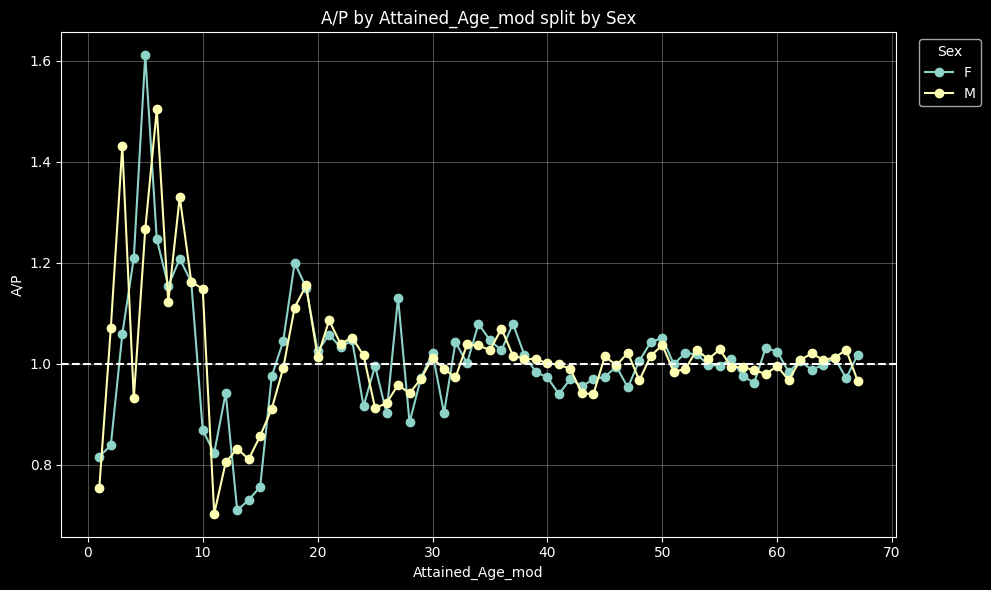

In [76]:
# ============================================================
# GRAPH REVIEW — PREDICTED RATE BY DURATION
# ============================================================

plot_ratio_curves(
    diagnostic_df,
    x_col=ATTAINED_AGE_MOD_COL,
    split_col="Sex",
    numerator_col="Actual_Rate_per_1000",
    denominator_col="Predicted_Rate_per_1000",
    min_expected=MIN_EXPECTED_FOR_MONOTONICITY,
    title="A/P by Attained_Age_mod split by Sex",
    y_label="A/P",
)



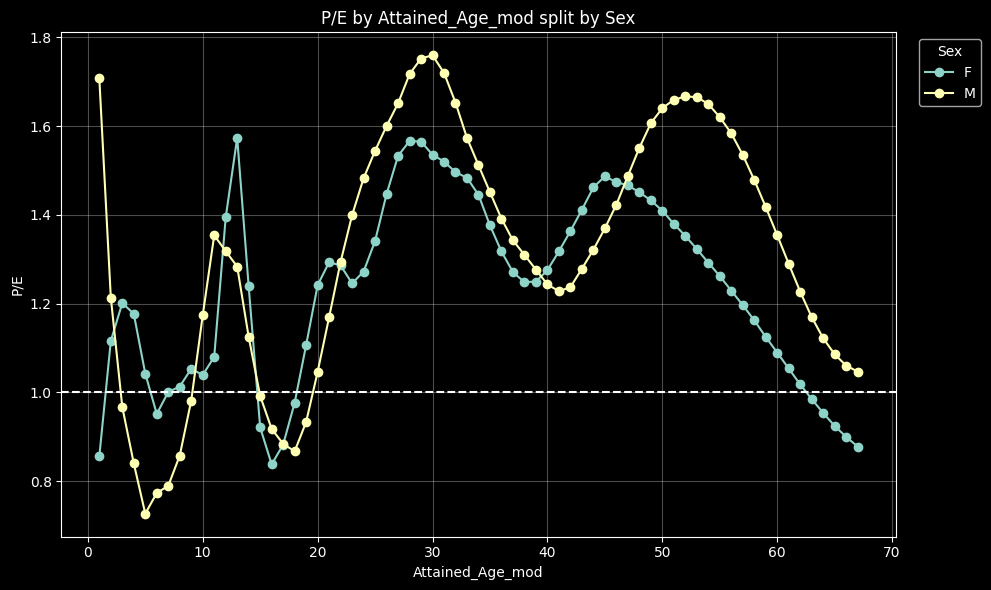

In [51]:
# ============================================================
# GRAPH REVIEW — PREDICTED RATE BY DURATION
# ============================================================

plot_ratio_curves(
    diagnostic_df,
    x_col=ATTAINED_AGE_MOD_COL,
    split_col="Sex",
    numerator_col="Predicted_Rate_per_1000",
    denominator_col="Expected_Rate_per_1000",
    min_expected=MIN_EXPECTED_FOR_MONOTONICITY,
    title="P/E by Attained_Age_mod split by Sex",
    y_label="P/E",
)



In [ ]:
# ============================================================
# GRAPH REVIEW — ACTUAL VS VBT VS PREDICTED
# ============================================================

plot_rate_curves(
    diagnostic_df,
    x_col="Observation_Year",
    split_col="Sex",
    rate_col="Predicted_Rate_per_1000",
    min_expected=MIN_EXPECTED_FOR_MONOTONICITY,
    title="Predicted mortality rate by Observation_Year split by Sex",
)



In [ ]:
# ============================================================
# RESIDUAL HEATMAPS
# ============================================================

residual_heatmap(diagnostic_df, ISSUE_AGE_MOD_COL, ATTAINED_AGE_MOD_COL, value_col="Actual_to_Predicted")


In [ ]:
# ============================================================
# FINAL TESTING SUMMARY TABLE
# ============================================================

summary_points = pd.DataFrame({
    "Item": [
        "Source file",
        "Scoped rows",
        "Selected model",
        "Validation basis",
        "1M face cap applied",
        "Age_Ind filter",
        "Age-basis testing columns",
        "Attained_Age_min",
        "Attained_Age_max",
        "Overall A/P (full refit)",
        "Overall A/VBT (full refit)",
        "Optional development sample fraction",
        "Output Age_Ind",
        "Output Sex",
    ],
    "Value": [
        str(DATA_PATH),
        f"{len(scoped_df):,}",
        SELECTED_MODEL_KEY,
        diagnostic_label,
        str(CAP_FACE_AT_1M),
        str(AGE_IND_KEEP),
        "Issue_Age_mod / Attained_Age_mod used for age-related testing; Age_Ind still segmented explicitly",
        str(ATTAINED_AGE_MIN),
        str(ATTAINED_AGE_MAX),
        round(float(overall_validation.loc[0, "Actual_to_Predicted"]), 6),
        round(float(overall_validation.loc[0, "Actual_to_VBT"]), 6),
        str(DEVELOPMENT_SAMPLE_FRACTION),
        str(OUTPUT_AGE_IND),
        str(OUTPUT_SEX),
    ]
})

display(summary_points)
export_csv(summary_points, "session4_summary_points.csv")


In [ ]:
# ============================================================
# SHEET-STYLE MORTALITY OUTPUTS
# ============================================================

modeled_sheet_pred = build_sheet_style_table(
    scored_df,
    value_col="Predicted_Deaths",
    age_ind_value=OUTPUT_AGE_IND,
    sex_value=OUTPUT_SEX,
    select_period=OUTPUT_SELECT_PERIOD,
    ult_duration=OUTPUT_ULT_DURATION,
    duration_cols=OUTPUT_DURATION_COLUMNS,
    rate_per=OUTPUT_RATE_PER,
    issue_age_min=OUTPUT_ISSUE_AGE_MIN,
    issue_age_max=OUTPUT_ISSUE_AGE_MAX,
)

modeled_sheet_actual = build_sheet_style_table(
    scored_df,
    value_col=ACTUAL_CNT_COL,
    age_ind_value=OUTPUT_AGE_IND,
    sex_value=OUTPUT_SEX,
    select_period=OUTPUT_SELECT_PERIOD,
    ult_duration=OUTPUT_ULT_DURATION,
    duration_cols=OUTPUT_DURATION_COLUMNS,
    rate_per=OUTPUT_RATE_PER,
    issue_age_min=OUTPUT_ISSUE_AGE_MIN,
    issue_age_max=OUTPUT_ISSUE_AGE_MAX,
)

modeled_sheet_vbt = build_sheet_style_table(
    scored_df,
    value_col=EXPECTED_CNT_COL,
    age_ind_value=OUTPUT_AGE_IND,
    sex_value=OUTPUT_SEX,
    select_period=OUTPUT_SELECT_PERIOD,
    ult_duration=OUTPUT_ULT_DURATION,
    duration_cols=OUTPUT_DURATION_COLUMNS,
    rate_per=OUTPUT_RATE_PER,
    issue_age_min=OUTPUT_ISSUE_AGE_MIN,
    issue_age_max=OUTPUT_ISSUE_AGE_MAX,
)

print("Predicted mortality table (rate per 1000)")
display(modeled_sheet_pred)

print("\nActual mortality table (rate per 1000)")
display(modeled_sheet_actual)

print("\n2015 VBT expected table on the same data mix (rate per 1000)")
display(modeled_sheet_vbt)

sheet_stub = f"ageind_{OUTPUT_AGE_IND}_sex_{OUTPUT_SEX}"
export_csv(modeled_sheet_pred, f"session4_modeled_sheet_pred_{sheet_stub}.csv")
export_csv(modeled_sheet_actual, f"session4_modeled_sheet_actual_{sheet_stub}.csv")
export_csv(modeled_sheet_vbt, f"session4_modeled_sheet_vbt_{sheet_stub}.csv")


In [ ]:
# ============================================================
# OPTIONAL BENCHMARK COMPARISON TO A REFERENCE EXCEL SHEET
# ============================================================

if BENCHMARK_XLSX_PATH is not None and BENCHMARK_SHEET_NAME is not None:
    reference_sheet = read_reference_sheet(Path(BENCHMARK_XLSX_PATH), BENCHMARK_SHEET_NAME, max_issue_age=OUTPUT_ISSUE_AGE_MAX)
    benchmark_comparison = compare_to_reference(modeled_sheet_pred, reference_sheet)

    print("Reference sheet")
    display(reference_sheet)

    print("\nLargest modeled-minus-reference differences")
    display(benchmark_comparison.head(25))

    export_csv(reference_sheet, f"session4_reference_sheet_{sheet_stub}.csv")
    export_csv(benchmark_comparison, f"session4_benchmark_comparison_{sheet_stub}.csv")
else:
    print("No benchmark workbook / sheet supplied. Skip this cell unless you want an explicit table-to-table comparison.")


In [ ]:
# Session 4 conclusion paragraph
n_review = int((worst_segments["Flag"] == "Review").sum())
n_issue_monotone_review = int((issue_age_monotonicity["Monotonicity_Flag"] == "Review").sum()) if len(issue_age_monotonicity) else 0
n_duration_monotone_review = int((duration_monotonicity["Monotonicity_Flag"] == "Review").sum()) if len(duration_monotonicity) else 0
overall_ap = float(overall_validation.loc[0, "Actual_to_Predicted"])

session4_conclusion = (
    f"Session 4 conclusion: the selected model {SELECTED_MODEL_KEY} produces an overall A/P of {overall_ap:.4f} "
    f"on the full-data refit. There are {n_review} segment tables currently flagged for review, "
    f"{n_issue_monotone_review} issue-age monotonicity points flagged, and {n_duration_monotone_review} duration monotonicity points flagged "
    f"after applying the credibility floor of {MIN_EXPECTED_FOR_MONOTONICITY:.1f} expected deaths. "
    f"The notebook now supports calibration review, monotonicity review, graph review, and direct sheet-style mortality table production "
    f"without converting Age_Ind to a single basis."
)

print(session4_conclusion)


## Suggested working pattern

1. change the **control panel at the start of each session**
2. run **Session 1** to confirm scope, cap logic, and first-pass A/E review
3. run **Session 2** to review screening, dependence, grouped plan / face diagnostics, and two-way A/E tables
4. run **Session 3** and compare the GAM-style models against the challenger models
5. choose `SELECTED_MODEL_KEY`
6. run **Session 4** to check calibration, monotonicity, graphs, and the sheet-style output
7. if needed later, re-activate a time-based holdout for a separate out-of-sample validation pass


In [ ]:
# ============================================================
# ISSUE AGE 10 MORTALITY BUMP — DIAGNOSTIC DEEP-DIVE
# ============================================================
# Isolates the A/E bump at Issue_Age == 10 and checks whether
# it is concentrated in a specific attained age, issue year,
# face amount band, or insurance plan — or whether it is
# uniformly elevated across all of those dimensions.
# ============================================================

# ── 0. Slice: Issue_Age 10 vs. peers (8-12) ─────────────────
PEER_AGES   = [8, 9, 10, 11, 12]
BUMP_AGE    = 10

bump_df = scoped_df[scoped_df["Issue_Age"].isin(PEER_AGES)].copy()
bump_df["Is_Age10"] = bump_df["Issue_Age"] == BUMP_AGE

print(f"Rows in peer slice  (Issue_Age {PEER_AGES}): {len(bump_df):,}")
print(f"  of which Issue_Age == {BUMP_AGE}:           "
      f"{(bump_df['Issue_Age'] == BUMP_AGE).sum():,}")

# ── 1. Overall A/E comparison: age 10 vs. peer group ────────
print("\n=== Overall A/E — Issue Age 10 vs. peer group ===")
display(
    ae_summary(bump_df, "Issue_Age")
    .rename_axis("Issue_Age")
    .assign(Highlight=lambda d: d.index == BUMP_AGE)
)

# ── 2. One-way cuts — for age-10 only ───────────────────────
age10_df = scoped_df[scoped_df["Issue_Age"] == BUMP_AGE].copy()

INSPECT_DIMS = {
    "Attained_Age":       "Attained_Age_Band",   # use band for readability
    "Issue_Year":         "Issue_Year",
    "Face_Amount_Band":   "Face_Band_Group",      # grouped bands reduce noise
    "Insurance_Plan":     "Insurance_Plan_Group",
}

for label, col in INSPECT_DIMS.items():
    if col not in age10_df.columns:
        print(f"\n[SKIP] Column '{col}' not found — check column list above.")
        continue
    print(f"\n=== Issue Age 10 only — by {label} ({col}) ===")
    summary = ae_summary(age10_df, col)
    display(summary)

# ── 3. Two-way: age 10 vs. peers, split by each factor ──────
# Shows whether the bump is uniform across factor levels or
# whether it is driven by a specific sub-segment.

TWO_WAY_DIMS = ["Attained_Age_Band", "Issue_Year", "Face_Band_Group", "Insurance_Plan_Group"]

for dim in TWO_WAY_DIMS:
    if dim not in bump_df.columns:
        print(f"\n[SKIP] Column '{dim}' not found.")
        continue
    print(f"\n=== A/E by Issue_Age (rows) × {dim} (columns) ===")
    ae_pivot, exp_pivot = two_way_ae_tables(bump_df, "Issue_Age", dim)
    print("  A/E Count ratio:")
    display(ae_pivot.style.format("{:.2%}", na_rep="—")
            .highlight_between(subset=pd.IndexSlice[BUMP_AGE, :],
                               color="lightyellow"))
    print("  Expected Count (credibility weight):")
    display(exp_pivot.style.format("{:,.0f}", na_rep="—")
            .highlight_between(subset=pd.IndexSlice[BUMP_AGE, :],
                               color="lightyellow"))

# ── 4. Heatmap: age 10 A/E by Attained_Age_Band × Issue_Year ─
# The most useful single chart for a bump at a specific issue
# age: does it follow a calendar year (data quality issue?) or
# an attained age (true mortality phenomenon)?

print("\n=== Heatmap: Issue_Age 10 — A/E by Attained_Age_Band × Issue_Year ===")
hmap_data = (
    age10_df
    .groupby(["Attained_Age_Band", "Issue_Year"], dropna=False)[[ACTUAL_CNT_COL, EXPECTED_CNT_COL]]
    .sum()
    .reset_index()
    .assign(AE=lambda d: safe_divide(d[ACTUAL_CNT_COL], d[EXPECTED_CNT_COL]))
    .pivot(index="Attained_Age_Band", columns="Issue_Year", values="AE")
)

fig, ax = plt.subplots(figsize=(14, 5))
im = ax.imshow(hmap_data.values, aspect="auto", cmap="RdYlGn_r", vmin=0.5, vmax=2.0)
ax.set_xticks(range(len(hmap_data.columns)))
ax.set_xticklabels(hmap_data.columns, rotation=45, ha="right", fontsize=8)
ax.set_yticks(range(len(hmap_data.index)))
ax.set_yticklabels(hmap_data.index, fontsize=8)
for i in range(len(hmap_data.index)):
    for j in range(len(hmap_data.columns)):
        val = hmap_data.values[i, j]
        if not np.isnan(val):
            ax.text(j, i, f"{val:.1%}", ha="center", va="center", fontsize=7,
                    color="black" if 0.6 < val < 1.6 else "white")
plt.colorbar(im, ax=ax, label="A/E Count")
ax.set_title(f"Issue Age {BUMP_AGE} — A/E Count by Attained Age Band × Issue Year\n"
             "(green = below VBT, red = above VBT; blank = no exposure)")
plt.tight_layout()
plt.show()

# ── 5. Bar chart: age 10 vs. peers by Attained_Age_Band ─────
print("\n=== A/E by Attained_Age_Band — age 10 vs. peers ===")
bar_data = (
    bump_df
    .groupby(["Issue_Age", "Attained_Age_Band"], dropna=False)[[ACTUAL_CNT_COL, EXPECTED_CNT_COL]]
    .sum()
    .reset_index()
    .assign(AE=lambda d: safe_divide(d[ACTUAL_CNT_COL], d[EXPECTED_CNT_COL]))
)

fig, ax = plt.subplots(figsize=(14, 5))
pivot_bar = bar_data.pivot(index="Attained_Age_Band", columns="Issue_Age", values="AE")
pivot_bar.plot(kind="bar", ax=ax, width=0.75)
ax.axhline(1.0, color="black", linewidth=1, linestyle="--", label="A/E = 100%")
ax.yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1))
# Highlight issue age 10 bars
for patch in ax.patches:
    pass  # coloring handled by pandas legend
ax.set_xlabel("Attained Age Band")
ax.set_ylabel("A/E Count")
ax.set_title(f"A/E Count by Attained Age Band — Issue Ages {PEER_AGES}\n"
             f"(Issue Age {BUMP_AGE} in orange if default palette)")
ax.legend(title="Issue Age", bbox_to_anchor=(1.01, 1), loc="upper left")
plt.xticks(rotation=45, ha="right", fontsize=8)
plt.tight_layout()
plt.show()

# ── 6. Credibility note ──────────────────────────────────────
cred = age10_df[[ACTUAL_CNT_COL, EXPECTED_CNT_COL]].sum()
print("\n=== Issue Age 10 — overall credibility ===")
print(f"  Actual deaths   : {cred[ACTUAL_CNT_COL]:,.0f}")
print(f"  Expected deaths : {cred[EXPECTED_CNT_COL]:,.2f}")
print(f"  A/E Count       : {cred[ACTUAL_CNT_COL] / cred[EXPECTED_CNT_COL]:.1%}")
print(f"  √Expected (credibility proxy): {cred[EXPECTED_CNT_COL] ** 0.5:,.1f}  "
      f"(full credibility ≈ 1,082 expected deaths)")

In [ ]:
# ============================================================
# DIAGNOSTIC — MORTALITY BUMP AT ISSUE AGE 10
# Inspect whether the bump is related to attained age,
# issue year, face amount, or insurance plan.
# ============================================================

BUMP_ISSUE_AGE   = 10          # focal issue age
CRED_FLOOR_CNT   = 5           # minimum deaths to show a dot / line
MIN_EXPOSURE     = 0           # minimum Policies_Exposed per cell (0 = off)

# ── helpers ────────────────────────────────────────────────
def _ae(sub):
    """Return count-weighted A/E on sub-aggregated data."""
    a = sub[ACTUAL_CNT_COL].sum()
    e = sub[EXPECTED_CNT_COL].sum()
    return a / e if e > 0 else float("nan")

def _cred(sub):
    return sub[ACTUAL_CNT_COL].sum()

# Identify bump (age 10) vs neighbour (ages 8-9 and 11-12) rows
_bump_ages     = [BUMP_ISSUE_AGE]
_neighbour_ages = [BUMP_ISSUE_AGE - 2, BUMP_ISSUE_AGE - 1, BUMP_ISSUE_AGE + 1, BUMP_ISSUE_AGE + 2]
_context_ages   = sorted(set(_neighbour_ages + _bump_ages))

bump_df      = scoped_df[scoped_df["Issue_Age"] == BUMP_ISSUE_AGE].copy()
context_df   = scoped_df[scoped_df["Issue_Age"].isin(_context_ages)].copy()
context_df["Is_Bump"] = context_df["Issue_Age"] == BUMP_ISSUE_AGE

# Palette: bump age pops, neighbours fade
_BLUE   = "#1f77b4"
_ORANGE = "#ff7f0e"
_GRAY   = "#aaaaaa"

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle(
    f"Mortality Bump at Issue Age {BUMP_ISSUE_AGE} — Factor Decomposition\n"
    "(A/E vs 2015 VBT, count-weighted; dashed orange = issue age 10)",
    fontsize=13, y=1.01
)

# ── Plot 1 · Raw A/E by Issue Age (overview) ───────────────
ax = axes[0, 0]
g = (
    scoped_df
    .groupby("Issue_Age", dropna=False)
    .apply(lambda s: pd.Series({"AE": _ae(s), "Deaths": _cred(s)}))
    .reset_index()
    .query(f"Deaths >= {CRED_FLOOR_CNT}")
)
ax.bar(g["Issue_Age"], g["AE"], color=_GRAY, alpha=0.7, label="All ages")
if BUMP_ISSUE_AGE in g["Issue_Age"].values:
    bv = g.loc[g["Issue_Age"] == BUMP_ISSUE_AGE, "AE"].values[0]
    ax.bar(BUMP_ISSUE_AGE, bv, color=_ORANGE, alpha=0.9, label=f"Age {BUMP_ISSUE_AGE}")
ax.axhline(1.0, color="black", linewidth=0.8, linestyle="--")
ax.set_title("A/E by Issue Age (overview)")
ax.set_xlabel("Issue Age")
ax.set_ylabel("A/E (count)")
ax.legend(fontsize=8)
ax.yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1, decimals=0))

# ── Plot 2 · A/E by Attained Age, bump vs neighbours ───────
ax = axes[0, 1]
for age, sub in context_df.groupby("Issue_Age"):
    g2 = (
        sub.groupby("Attained_Age", dropna=False)
        .apply(lambda s: pd.Series({"AE": _ae(s), "Deaths": _cred(s)}))
        .reset_index()
        .query(f"Deaths >= {CRED_FLOOR_CNT}")
    )
    is_bump = (age == BUMP_ISSUE_AGE)
    ax.plot(
        g2["Attained_Age"], g2["AE"],
        marker="o", markersize=4 if is_bump else 3,
        linewidth=2 if is_bump else 1,
        color=_ORANGE if is_bump else _GRAY,
        alpha=1.0 if is_bump else 0.5,
        label=f"Iss.Age {age}" + (" ★" if is_bump else ""),
        zorder=3 if is_bump else 1,
    )
ax.axhline(1.0, color="black", linewidth=0.8, linestyle="--")
ax.set_title("A/E by Attained Age\n(bump vs neighbouring issue ages)")
ax.set_xlabel("Attained Age")
ax.set_ylabel("A/E (count)")
ax.legend(fontsize=7, ncol=2)
ax.yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1, decimals=0))

# ── Plot 3 · A/E by Issue Year, bump vs neighbours ─────────
ax = axes[0, 2]
for age, sub in context_df.groupby("Issue_Age"):
    g3 = (
        sub.groupby("Issue_Year", dropna=False)
        .apply(lambda s: pd.Series({"AE": _ae(s), "Deaths": _cred(s)}))
        .reset_index()
        .query(f"Deaths >= {CRED_FLOOR_CNT}")
    )
    is_bump = (age == BUMP_ISSUE_AGE)
    ax.plot(
        g3["Issue_Year"], g3["AE"],
        marker="o", markersize=4 if is_bump else 3,
        linewidth=2 if is_bump else 1,
        color=_ORANGE if is_bump else _GRAY,
        alpha=1.0 if is_bump else 0.5,
        label=f"Iss.Age {age}" + (" ★" if is_bump else ""),
        zorder=3 if is_bump else 1,
    )
ax.axhline(1.0, color="black", linewidth=0.8, linestyle="--")
ax.set_title("A/E by Issue Year\n(bump vs neighbouring issue ages)")
ax.set_xlabel("Issue Year")
ax.set_ylabel("A/E (count)")
ax.legend(fontsize=7, ncol=2)
ax.yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1, decimals=0))

# ── Plot 4 · A/E by Face Band, bump vs all other issue ages ─
ax = axes[1, 0]
# Use Face_Band_Group if available, otherwise Face_Amount_Band
_face_col = "Face_Band_Group" if "Face_Band_Group" in scoped_df.columns else "Face_Amount_Band"

all_ae_face = (
    scoped_df
    .groupby(_face_col, dropna=False)
    .apply(lambda s: pd.Series({"AE": _ae(s), "Deaths": _cred(s)}))
    .reset_index()
    .query(f"Deaths >= {CRED_FLOOR_CNT}")
    .sort_values(_face_col)
)
bump_ae_face = (
    bump_df
    .groupby(_face_col, dropna=False)
    .apply(lambda s: pd.Series({"AE": _ae(s), "Deaths": _cred(s)}))
    .reset_index()
    .query(f"Deaths >= {CRED_FLOOR_CNT}")
    .sort_values(_face_col)
)

x_pos = range(len(all_ae_face))
ax.bar(x_pos, all_ae_face["AE"], color=_GRAY, alpha=0.6, label="All issue ages")
# overlay bump
bump_merged = all_ae_face[[_face_col]].merge(bump_ae_face, on=_face_col, how="left")
ax.bar(x_pos, bump_merged["AE"], color=_ORANGE, alpha=0.8, label=f"Issue age {BUMP_ISSUE_AGE}")
ax.axhline(1.0, color="black", linewidth=0.8, linestyle="--")
ax.set_title(f"A/E by Face Amount Band\n(overall vs issue age {BUMP_ISSUE_AGE})")
ax.set_xticks(list(x_pos))
ax.set_xticklabels(all_ae_face[_face_col].tolist(), rotation=35, ha="right", fontsize=7)
ax.set_ylabel("A/E (count)")
ax.legend(fontsize=8)
ax.yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1, decimals=0))

# ── Plot 5 · A/E by Insurance Plan, bump vs all ─────────────
ax = axes[1, 1]
_plan_col = "Insurance_Plan_Group" if "Insurance_Plan_Group" in scoped_df.columns else "Insurance_Plan"

all_ae_plan = (
    scoped_df
    .groupby(_plan_col, dropna=False)
    .apply(lambda s: pd.Series({"AE": _ae(s), "Deaths": _cred(s)}))
    .reset_index()
    .query(f"Deaths >= {CRED_FLOOR_CNT}")
    .sort_values(_plan_col)
)
bump_ae_plan = (
    bump_df
    .groupby(_plan_col, dropna=False)
    .apply(lambda s: pd.Series({"AE": _ae(s), "Deaths": _cred(s)}))
    .reset_index()
    .query(f"Deaths >= {CRED_FLOOR_CNT}")
    .sort_values(_plan_col)
)

x2 = range(len(all_ae_plan))
ax.bar(x2, all_ae_plan["AE"], color=_GRAY, alpha=0.6, label="All issue ages")
bump_merged2 = all_ae_plan[[_plan_col]].merge(bump_ae_plan, on=_plan_col, how="left")
ax.bar(x2, bump_merged2["AE"], color=_ORANGE, alpha=0.8, label=f"Issue age {BUMP_ISSUE_AGE}")
ax.axhline(1.0, color="black", linewidth=0.8, linestyle="--")
ax.set_title(f"A/E by Insurance Plan\n(overall vs issue age {BUMP_ISSUE_AGE})")
ax.set_xticks(list(x2))
ax.set_xticklabels(all_ae_plan[_plan_col].tolist(), rotation=20, ha="right", fontsize=8)
ax.set_ylabel("A/E (count)")
ax.legend(fontsize=8)
ax.yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1, decimals=0))

# ── Plot 6 · Heatmap: Issue Year × Insurance Plan (bump only) ─
ax = axes[1, 2]
heat_data = (
    bump_df
    .groupby(["Issue_Year", _plan_col], dropna=False)
    .apply(lambda s: _ae(s) if _cred(s) >= CRED_FLOOR_CNT else float("nan"))
    .reset_index(name="AE")
    .pivot(index="Issue_Year", columns=_plan_col, values="AE")
)
if not heat_data.empty:
    im = ax.imshow(
        heat_data.values, aspect="auto", cmap="RdYlGn",
        vmin=0.5, vmax=2.0, origin="upper"
    )
    plt.colorbar(im, ax=ax, label="A/E")
    ax.set_xticks(range(len(heat_data.columns)))
    ax.set_xticklabels(heat_data.columns.tolist(), rotation=25, ha="right", fontsize=7)
    ax.set_yticks(range(len(heat_data.index)))
    ax.set_yticklabels(heat_data.index.tolist(), fontsize=7)
    ax.set_title(f"Issue Age {BUMP_ISSUE_AGE}: A/E heat\nIssue Year × Insurance Plan")
    ax.set_xlabel(_plan_col)
    ax.set_ylabel("Issue Year")
else:
    ax.text(0.5, 0.5, "Insufficient data\nfor heatmap", ha="center", va="center", transform=ax.transAxes)
    ax.set_title(f"Issue Age {BUMP_ISSUE_AGE}: A/E heat\n(no credible cells)")

plt.tight_layout()
plt.show()

# ── Companion summary table ─────────────────────────────────
print(f"\n── Issue Age {BUMP_ISSUE_AGE} — A/E by key factors (deaths ≥ {CRED_FLOOR_CNT}) ──")
for label, col in [("Attained Age", "Attained_Age"), ("Issue Year", "Issue_Year"),
                   ("Face Band", _face_col), ("Insurance Plan", _plan_col)]:
    tbl = (
        bump_df
        .groupby(col, dropna=False)
        .apply(lambda s: pd.Series({
            "Deaths": int(_cred(s)),
            "Exposure": int(s["Policies_Exposed"].sum()),
            "A/E": round(_ae(s), 3),
        }))
        .reset_index()
        .query(f"Deaths >= {CRED_FLOOR_CNT}")
    )
    print(f"\n  {label}:")
    display(tbl)

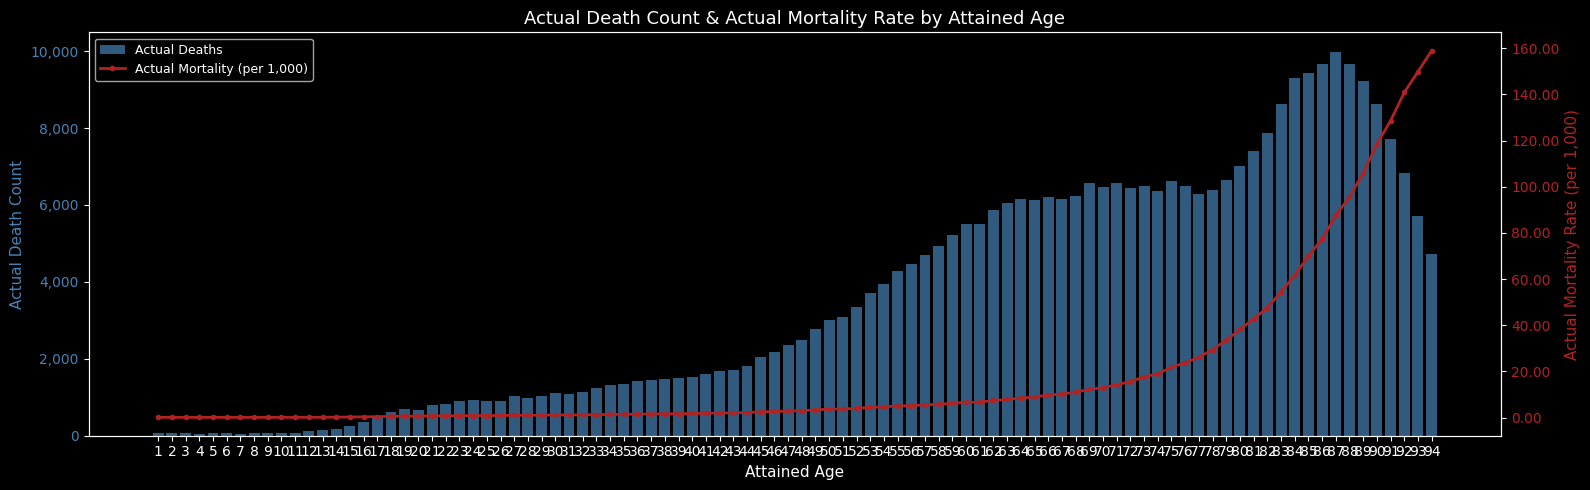

In [54]:
# ============================================================
# ACTUAL DEATH COUNT (BAR) + ACTUAL MORTALITY RATE (LINE)
# BY ATTAINED AGE — NO BIN
# ============================================================

age_grp = (
    scoped_df
    .groupby("Attained_Age", sort=True)
    .agg(
        Deaths=(ACTUAL_CNT_COL, "sum"),
        Exposure=("Policies_Exposed", "sum"),
    )
    .reset_index()
)
age_grp["Actual_qx"] = age_grp["Deaths"] / age_grp["Exposure"]

fig, ax1 = plt.subplots(figsize=(16, 5))

# --- Bars: actual death count ---
ax1.bar(
    age_grp["Attained_Age"],
    age_grp["Deaths"],
    width=0.8,
    color="steelblue",
    alpha=0.7,
    label="Actual Deaths",
)
ax1.set_xlabel("Attained Age", fontsize=11)
ax1.set_ylabel("Actual Death Count", color="steelblue", fontsize=11)
ax1.tick_params(axis="y", labelcolor="steelblue")
ax1.yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f"{int(x):,}"))

# --- Line: actual mortality rate ---
ax2 = ax1.twinx()
ax2.plot(
    age_grp["Attained_Age"],
    age_grp["Actual_qx"] * 1_000,   # per 1,000
    color="firebrick",
    linewidth=2,
    marker="o",
    markersize=3,
    label="Actual Mortality (per 1,000)",
)
ax2.set_ylabel("Actual Mortality Rate (per 1,000)", color="firebrick", fontsize=11)
ax2.tick_params(axis="y", labelcolor="firebrick")
ax2.yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f"{x:.2f}"))

# --- Legend and title ---
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc="upper left", fontsize=9)

plt.title("Actual Death Count & Actual Mortality Rate by Attained Age", fontsize=13)
plt.xticks(
    ticks=age_grp["Attained_Age"],
    labels=age_grp["Attained_Age"].astype(int),
    rotation=90,
    fontsize=7,
)
plt.tight_layout()
plt.show()

Female | AIC=693.3  n_splines=6  overall A/P=1.0000
Male   | AIC=1,407.7  n_splines=6  overall A/P=1.0000


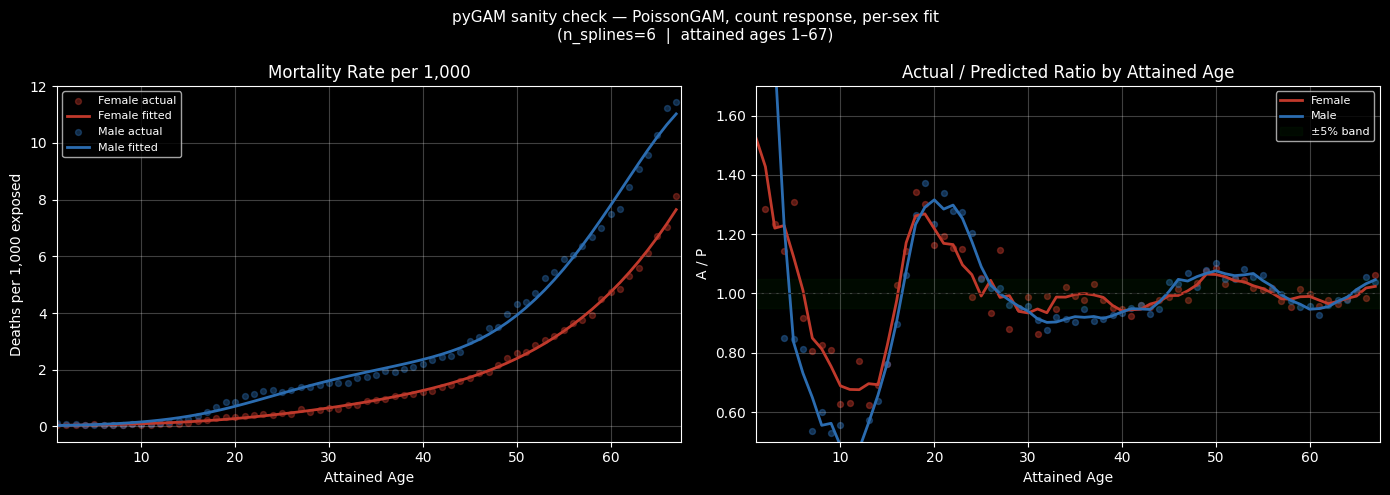

In [78]:
# ============================================================
# PYGAM SANITY CHECK — Poisson, count response, per-sex
# Append to end of Session 4. No new dependencies needed;
# pygam is already imported at the top of this notebook.
# ============================================================

# ── Control panel ────────────────────────────────────────────
PYGAM_N_SPLINES = 6       # flexibility: raise to 8–10 for more curvature
PYGAM_COLORS    = {"F": "#C0392B", "M": "#2B6CB0"}
PYGAM_LABELS    = {"F": "Female",  "M": "Male"}

# ── 1. Aggregate to (Sex × Attained_Age_mod) ─────────────────
# Aggregate first so pyGAM sees one row per age cell per sex,
# not one row per policy — much faster and numerically identical.
_agg = (
    scoped_df
    .groupby(["Sex", ATTAINED_AGE_MOD_COL], as_index=False)
    .agg(
        Deaths   =(ACTUAL_CNT_COL,    "sum"),
        Exposure =("Policies_Exposed", "sum"),
    )
)
_agg = _agg[_agg["Exposure"] > 0].copy()

# ── 2. Fit one PoissonGAM per sex ────────────────────────────
# Correct spec:  y = Death count (integer)
#                exposure = Policies_Exposed  → pyGAM adds log(exposure) offset
# Wrong spec:    y = death rate, exposure as weights → near-zero predictions
_gam_results = {}

for sex in ["F", "M"]:
    _sub = _agg[_agg["Sex"] == sex].sort_values(ATTAINED_AGE_MOD_COL).copy()
    _X   = _sub[[ATTAINED_AGE_MOD_COL]].values
    _y   = _sub["Deaths"].values.astype(int)
    _exp = _sub["Exposure"].values

    _gam = PoissonGAM(s(0, n_splines=PYGAM_N_SPLINES)).fit(_X, _y, exposure=_exp)

    _sub["Pred_Deaths"] = _gam.predict(_X, exposure=_exp)
    _sub["Actual_Rate"] = _sub["Deaths"]      / _sub["Exposure"] * 1_000
    _sub["Pred_Rate"]   = _sub["Pred_Deaths"] / _sub["Exposure"] * 1_000
    _sub["AP"]          = safe_divide(_sub["Deaths"], _sub["Pred_Deaths"])
    _gam_results[sex]   = _sub

    _overall_ap = safe_divide(_sub["Deaths"].sum(), _sub["Pred_Deaths"].sum())
    print(f"{PYGAM_LABELS[sex]:6s} | AIC={_gam.statistics_['AIC']:,.1f}"
          f"  n_splines={PYGAM_N_SPLINES}"
          f"  overall A/P={_overall_ap:.4f}")

# ── 3. Plot ───────────────────────────────────────────────────
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle(
    "pyGAM sanity check — PoissonGAM, count response, per-sex fit\n"
    f"(n_splines={PYGAM_N_SPLINES}  |  attained ages {ATTAINED_AGE_MIN}–{int(ATTAINED_AGE_MOD_MAX)})",
    fontsize=11,
)

for sex in ["F", "M"]:
    _sub = _gam_results[sex]
    _c   = PYGAM_COLORS[sex]
    _lbl = PYGAM_LABELS[sex]

    # Panel 1 — mortality rate per 1,000
    ax1.scatter(_sub[ATTAINED_AGE_MOD_COL], _sub["Actual_Rate"],
                color=_c, alpha=0.4, s=18, label=f"{_lbl} actual")
    ax1.plot(_sub[ATTAINED_AGE_MOD_COL], _sub["Pred_Rate"],
             color=_c, lw=2, label=f"{_lbl} fitted")

    # Panel 2 — A/P ratio
    ax2.scatter(_sub[ATTAINED_AGE_MOD_COL], _sub["AP"],
                color=_c, alpha=0.45, s=18)
    _smooth = (
        _sub.set_index(ATTAINED_AGE_MOD_COL)["AP"]
        .rolling(3, center=True, min_periods=1).mean()
    )
    ax2.plot(_smooth.index, _smooth.values, color=_c, lw=2, label=_lbl)

ax1.set_title("Mortality Rate per 1,000")
ax1.set_xlabel("Attained Age")
ax1.set_ylabel("Deaths per 1,000 exposed")
ax1.set_xlim(ATTAINED_AGE_MIN, ATTAINED_AGE_MOD_MAX)
ax1.legend(fontsize=8)
ax1.grid(True, alpha=0.25)

ax2.axhline(1.0, color="black", lw=1, linestyle="--", alpha=0.6)
ax2.axhspan(0.95, 1.05, color="green", alpha=0.07, label="±5% band")
ax2.set_title("Actual / Predicted Ratio by Attained Age")
ax2.set_xlabel("Attained Age")
ax2.set_ylabel("A / P")
ax2.set_ylim(0.5, 1.7)
ax2.set_xlim(ATTAINED_AGE_MIN, ATTAINED_AGE_MOD_MAX)
ax2.yaxis.set_major_formatter(mtick.FormatStrFormatter("%.2f"))
ax2.legend(fontsize=8)
ax2.grid(True, alpha=0.25)

plt.tight_layout()
plt.show()

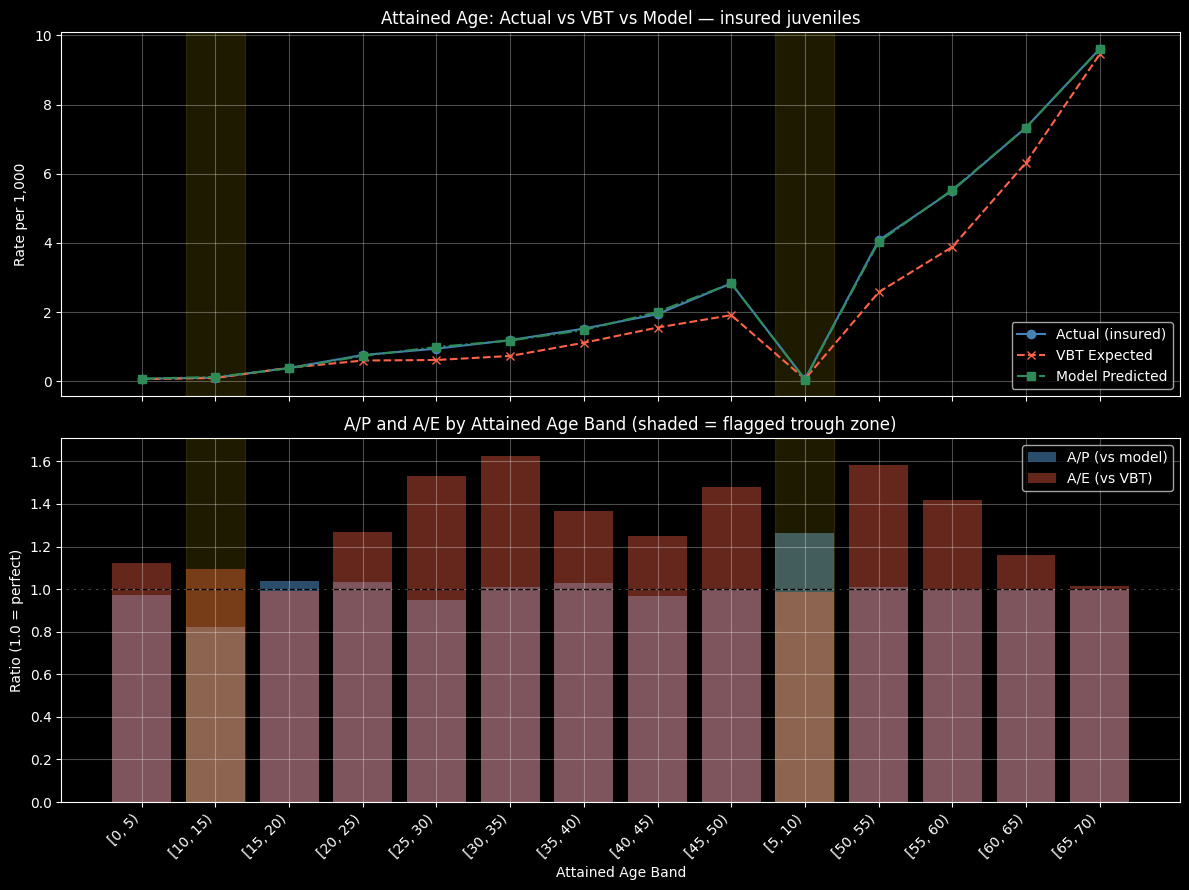

,Band_Label,ExpDth_VBT2015_Cnt,Death_Count,Expected_Rate_per_1000,Actual_Rate_per_1000,Actual_to_VBT,Actual_to_Predicted,Flag
0,"[0, 5)",234.744091,263,0.063351,0.070976,1.120369,0.974063,OK
1,"[10, 15)",550.299438,603,0.093682,0.102654,1.095767,0.819824,Review
2,"[15, 20)","2,453.737307",2428,0.390104,0.386012,0.989511,1.037549,OK
3,"[20, 25)","3,260.395597",4131,0.598731,0.758607,1.267024,1.034014,OK
4,"[25, 30)","3,169.400181",4855,0.615064,0.942176,1.531836,0.950663,OK
5,"[30, 35)","3,604.361197",5864,0.731581,1.190222,1.626918,1.010922,OK
6,"[35, 40)","5,253.500175",7181,1.113053,1.521431,1.366898,1.027146,OK
7,"[40, 45)","6,702.693640",8374,1.553141,1.940414,1.249348,0.968705,OK
8,"[45, 50)","8,004.549488",11850,1.911751,2.830171,1.480408,1.000783,OK
9,"[5, 10)",325.523079,321,0.063140,0.062262,0.986105,1.264238,Review


In [79]:
# ── Confirm VBT U-shape vs flat insured actuals ──────────────────────────────
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick

cal = calibration_table(scored_df, "Attained_Age_Band")

# Drop bands with negligible credibility
cal = cal[cal[EXPECTED_CNT_COL] >= MIN_EXPECTED_FOR_REVIEW].copy()

# String labels for x-axis (interval categories don't plot cleanly)
cal["Band_Label"] = cal["Attained_Age_Band"].astype(str)

fig, axes = plt.subplots(2, 1, figsize=(12, 9), sharex=True)

# ── Top panel: rates ─────────────────────────────────────────────────────────
ax = axes[0]
ax.plot(cal["Band_Label"], cal["Actual_Rate_per_1000"],
        marker="o", color="steelblue", label="Actual (insured)")
ax.plot(cal["Band_Label"], cal["Expected_Rate_per_1000"],
        marker="x", linestyle="--", color="tomato", label="VBT Expected")
ax.plot(cal["Band_Label"], cal["Predicted_Rate_per_1000"],
        marker="s", linestyle="-.", color="seagreen", label="Model Predicted")

# Highlight the problem bands
for band in ["[5, 10)", "[10, 15)"]:
    matches = cal[cal["Band_Label"].str.startswith(band[:3])]
    if len(matches):
        ax.axvspan(matches.index[0] - 0.4, matches.index[-1] + 0.4,
                   alpha=0.12, color="gold", label="_nolegend_")

ax.set_ylabel("Rate per 1,000")
ax.set_title("Attained Age: Actual vs VBT vs Model — insured juveniles")
ax.legend()
ax.grid(True, alpha=0.3)
force_plain_axis(ax, "y")

# ── Bottom panel: A/P and A/E ratios ─────────────────────────────────────────
ax2 = axes[1]
ax2.bar(cal["Band_Label"], cal["Actual_to_Predicted"],
        color="steelblue", alpha=0.6, label="A/P (vs model)")
ax2.bar(cal["Band_Label"], cal["Actual_to_VBT"],
        color="tomato", alpha=0.4, label="A/E (vs VBT)")
ax2.axhline(1.0, color="black", linewidth=1, linestyle="--")

for band in ["[5, 10)", "[10, 15)"]:
    matches = cal[cal["Band_Label"].str.startswith(band[:3])]
    if len(matches):
        ax2.axvspan(matches.index[0] - 0.4, matches.index[-1] + 0.4,
                    alpha=0.12, color="gold", label="_nolegend_")

ax2.set_ylabel("Ratio (1.0 = perfect)")
ax2.set_xlabel("Attained Age Band")
ax2.set_title("A/P and A/E by Attained Age Band (shaded = flagged trough zone)")
ax2.legend()
ax2.grid(True, alpha=0.3)
force_plain_axis(ax2, "y")

plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

# ── Quick sanity table ────────────────────────────────────────────────────────
cols = ["Band_Label", EXPECTED_CNT_COL, ACTUAL_CNT_COL,
        "Expected_Rate_per_1000", "Actual_Rate_per_1000",
        "Actual_to_VBT", "Actual_to_Predicted", "Flag"]
display(cal[cols])

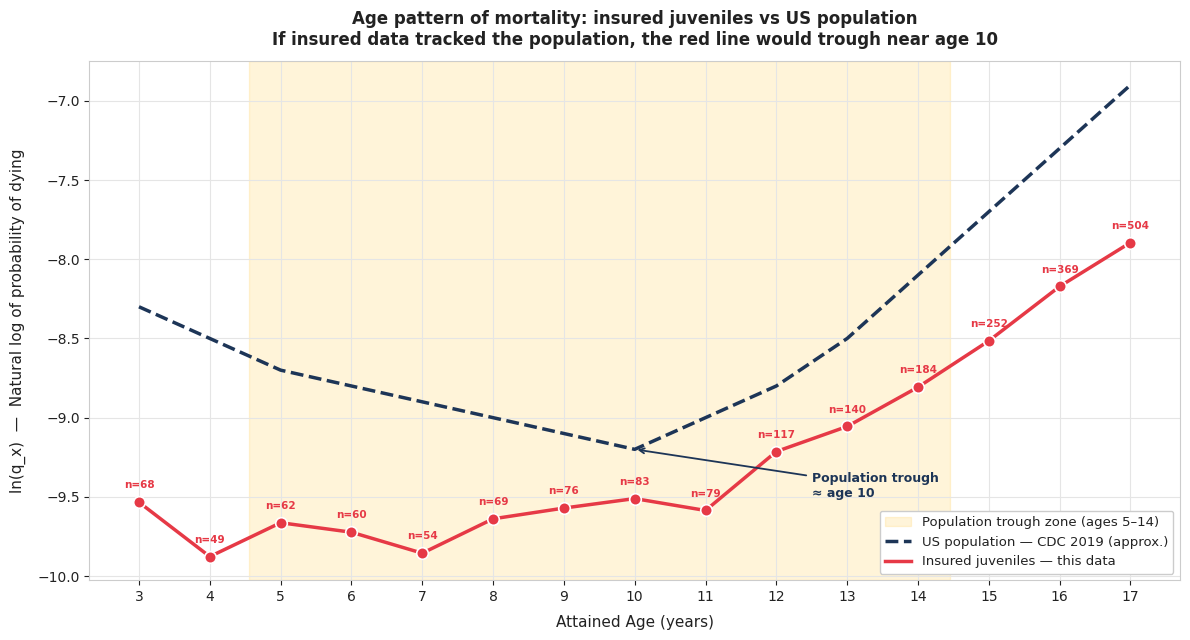

,Deaths,Exposed,q_x,ln(q_x)
Age,,,,
3,68,"939,913",0.000072,-9.5340
4,49,"954,480",0.000051,-9.8771
5,62,"975,209",0.000064,-9.6633
6,60,"1,002,132",0.000060,-9.7233
7,54,"1,029,558",0.000052,-9.8557
8,69,"1,058,868",0.000065,-9.6386
9,76,"1,089,838",0.000070,-9.5708
10,83,"1,120,928",0.000074,-9.5108
11,79,"1,150,168",0.000069,-9.5860


In [93]:
# ── ln(q_x) by single attained age — insured juveniles vs population shape ───
import matplotlib.pyplot as plt
import numpy as np

age_df = (
    scored_df
    .groupby("Attained_Age", dropna=False)[[ACTUAL_CNT_COL, "Policies_Exposed"]]
    .sum()
    .reset_index()
)

age_df = age_df[
    age_df["Attained_Age"].between(3, 17) &
    (age_df["Policies_Exposed"] > 0) &
    (age_df[ACTUAL_CNT_COL] > 0)
].copy()

age_df["q_x"]    = age_df[ACTUAL_CNT_COL] / age_df["Policies_Exposed"]
age_df["ln_q_x"] = np.log(age_df["q_x"])

x    = age_df["Attained_Age"].values
ln_q = age_df["ln_q_x"].values

pop_ages = np.array([3,    4,    5,    6,    7,    8,    9,   10,   11,   12,   13,   14,   15,   16,   17])
pop_ln_q = np.array([-8.3, -8.5, -8.7, -8.8, -8.9, -9.0, -9.1, -9.2, -9.0, -8.8, -8.5, -8.1, -7.7, -7.3, -6.9])

# ── Style ─────────────────────────────────────────────────────────────────────
INSURED_COLOR = "#E63946"   # vivid red
POP_COLOR     = "#1D3557"   # deep navy
TROUGH_COLOR  = "#FFB703"   # amber

plt.rcParams.update({
    "figure.facecolor":  "white",
    "axes.facecolor":    "white",
    "axes.edgecolor":    "#CCCCCC",
    "axes.labelcolor":   "#222222",
    "xtick.color":       "#222222",
    "ytick.color":       "#222222",
    "grid.color":        "#E5E5E5",
    "text.color":        "#222222",
})

fig, ax = plt.subplots(figsize=(12, 6.5), facecolor="white")
ax.set_facecolor("white")

# Trough shading
ax.axvspan(5 - 0.45, 14 + 0.45, color=TROUGH_COLOR, alpha=0.15, zorder=0,
           label="Population trough zone (ages 5–14)")

# Population reference
ax.plot(pop_ages, pop_ln_q,
        lw=2.5, linestyle="--", color=POP_COLOR,
        label="US population — CDC 2019 (approx.)", zorder=2)

# Insured line + markers
ax.plot(x, ln_q,
        lw=2.5, color=INSURED_COLOR, zorder=3,
        label="Insured juveniles — this data")
ax.scatter(x, ln_q,
           s=70, color=INSURED_COLOR, edgecolors="white", linewidths=1.2,
           zorder=4)

# Death count annotations
for xi, lq, deaths in zip(x, ln_q, age_df[ACTUAL_CNT_COL].values):
    ax.annotate(f"n={int(deaths)}",
                xy=(xi, lq),
                xytext=(0, 10), textcoords="offset points",
                ha="center", fontsize=7.5,
                color=INSURED_COLOR, fontweight="bold")

# Trough label
ax.annotate("Population trough\n≈ age 10",
            xy=(10, pop_ln_q[7]),
            xytext=(12.5, -9.5),
            fontsize=9, color=POP_COLOR, fontweight="bold",
            arrowprops=dict(arrowstyle="->", color=POP_COLOR, lw=1.3))

ax.set_xlabel("Attained Age (years)", fontsize=11, labelpad=8)
ax.set_ylabel("ln(q_x)  —  Natural log of probability of dying", fontsize=11, labelpad=8)
ax.set_title(
    "Age pattern of mortality: insured juveniles vs US population\n"
    "If insured data tracked the population, the red line would trough near age 10",
    fontsize=12, fontweight="bold", pad=12
)
ax.set_xticks(np.arange(3, 18))
ax.legend(fontsize=9.5, frameon=True, framealpha=1,
          edgecolor="#CCCCCC", loc="lower right")
ax.grid(True, alpha=1.0)
force_plain_axis(ax, "y")

plt.tight_layout()
plt.show()

# ── Table ─────────────────────────────────────────────────────────────────────
display(
    age_df[["Attained_Age", ACTUAL_CNT_COL, "Policies_Exposed", "q_x", "ln_q_x"]]
    .rename(columns={
        "Attained_Age":     "Age",
        ACTUAL_CNT_COL:     "Deaths",
        "Policies_Exposed": "Exposed",
        "q_x":              "q_x",
        "ln_q_x":           "ln(q_x)",
    })
    .set_index("Age")
    .style.format({"Deaths": "{:.0f}", "Exposed": "{:,.0f}",
                   "q_x": "{:.6f}", "ln(q_x)": "{:.4f}"})
)